# **IMPORT & LOAD DATA**

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('/content/final_test.csv')
df

,weight,age,height,size
0,62,28.0,172.72,XL
1,59,36.0,167.64,L
2,61,34.0,165.10,M
3,65,27.0,175.26,L
4,62,45.0,172.72,M
...,...,...,...,...
119729,63,42.0,175.26,M
119730,45,29.0,154.94,S
119731,61,31.0,172.72,M
119732,74,31.0,167.64,XL


# **INTRO**

In [ ]:
print('Shape of the Dataset =', df.shape)

Shape of the Dataset = (119734, 4)


In [ ]:
df.columns.values.tolist()

['weight', 'age', 'height', 'size']

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119734 entries, 0 to 119733
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   weight  119734 non-null  int64  
 1   age     119477 non-null  float64
 2   height  119404 non-null  float64
 3   size    119734 non-null  object 
dtypes: float64(2), int64(1), object(1)
memory usage: 3.7+ MB


In [ ]:
df.describe()

,weight,age,height
count,119734.000000,119477.000000,119404.000000
mean,61.756811,34.027311,165.805794
std,9.944863,8.149447,6.737651
min,22.000000,0.000000,137.160000
25%,55.000000,29.000000,160.020000
50%,61.000000,32.000000,165.100000
75%,67.000000,37.000000,170.180000
max,136.000000,117.000000,193.040000


In [ ]:
df.dtypes

weight      int64
age       float64
height    float64
size       object
dtype: object

# **MISS**

In [ ]:
df.isnull().sum()

weight      0
age       257
height    330
size        0
dtype: int64

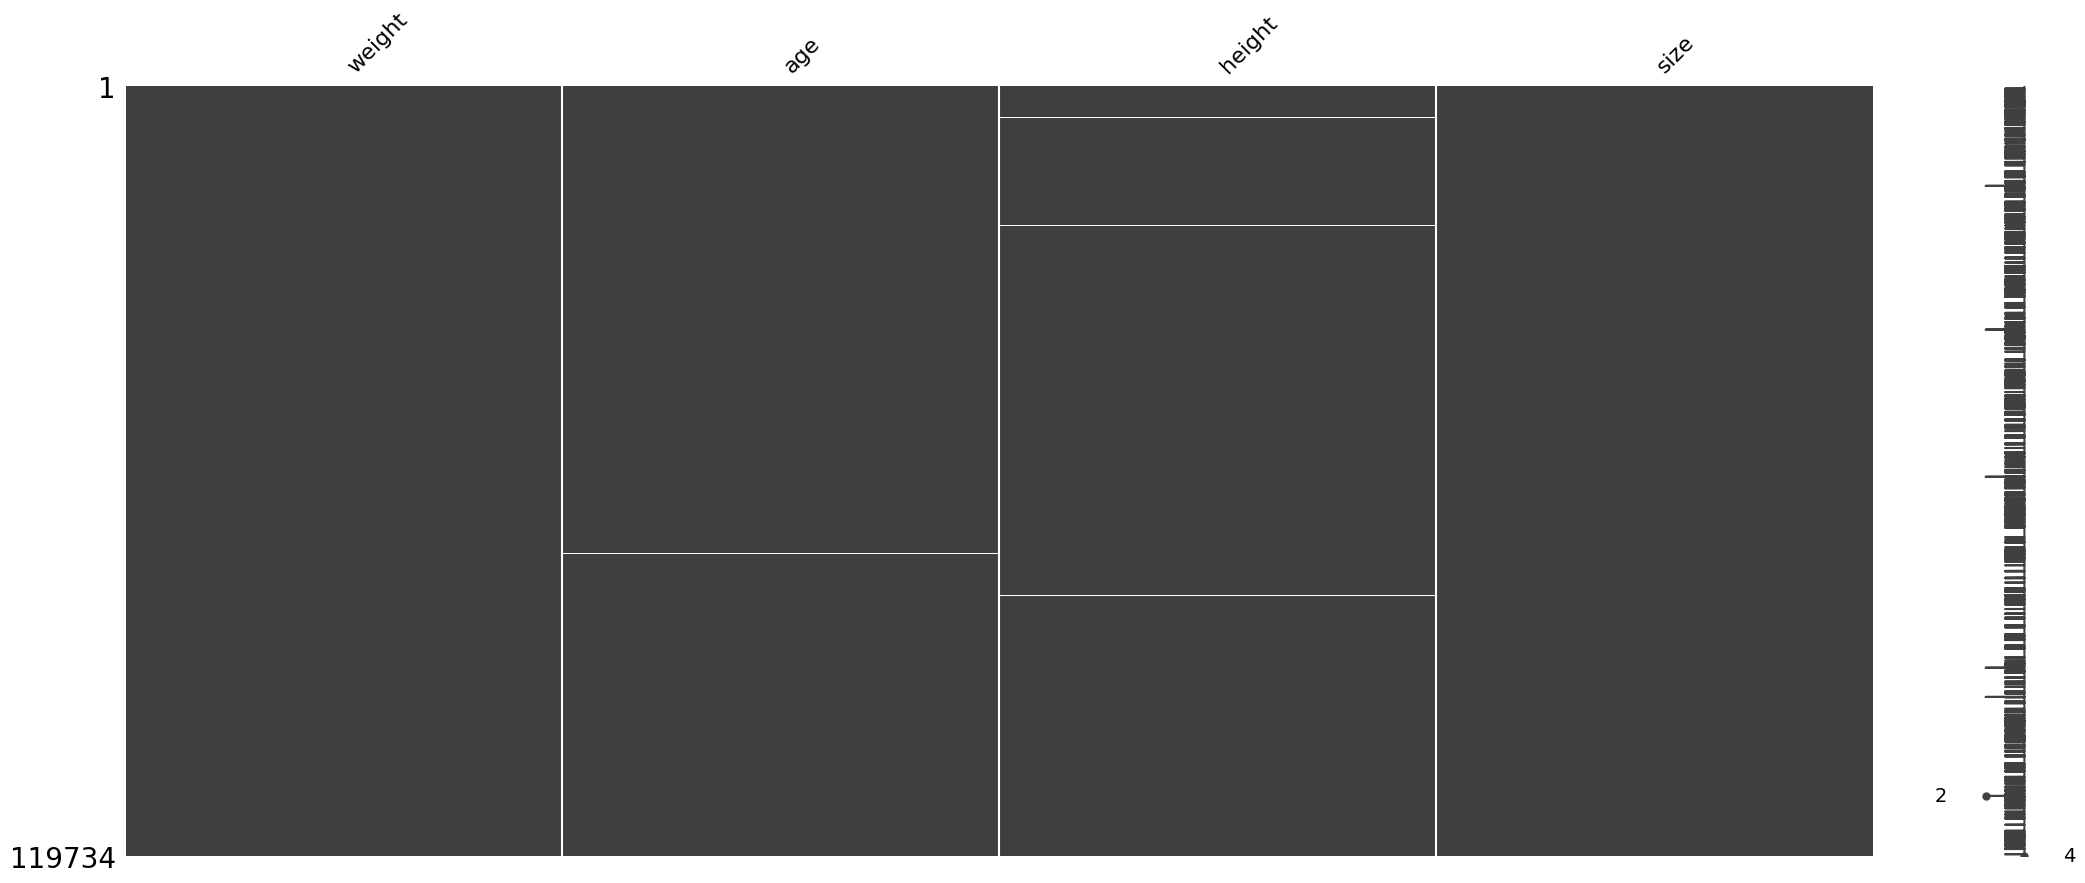

In [ ]:
import missingno as msno
msno.matrix(df)
plt.show()

# **FILL X**

In [ ]:
df['age'] = df['age'].fillna(df['age'].median())

In [ ]:
df['height'] = df['height'].fillna(df['height'].median())

In [ ]:
df['size'] = df['size'].map({"XXS": 1, "S": 2, "M" : 3, "L" : 4, "XL" : 5, "XXL" : 6, "XXXL" : 7})

In [ ]:
df['bmi'] = df['weight'] / (pow(df['height'] / 100, 2))

# **RANGE**

In [ ]:
print('The Range of Values among the different 5 Columns')

print('weight : {:.4f}'.format(min(df['weight'])) + ' - {:.4f}'.format(max(df['weight'])))
print('\n')
print('age : {:.4f}'.format(min(df['age'])) + ' - {:.4f}'.format(max(df['age'])))
print('\n')
print('height : {:.4f}'.format(min(df['height'])) + ' - {:.4f}'.format(max(df['height'])))
print('\n')
print('size : {:.4f}'.format(min(df['size'])) + ' - {:.4f}'.format(max(df['size'])))
print('\n')
print('BMI : {:.4f}'.format(min(df['bmi'])) + ' - {:.4f}'.format(max(df['bmi'])))

The Range of Values among the different 5 Columns
weight : 22.0000 - 136.0000


age : 0.0000 - 117.0000


height : 137.1600 - 193.0400


size : 1.0000 - 7.0000


BMI : 7.8283 - 54.3236


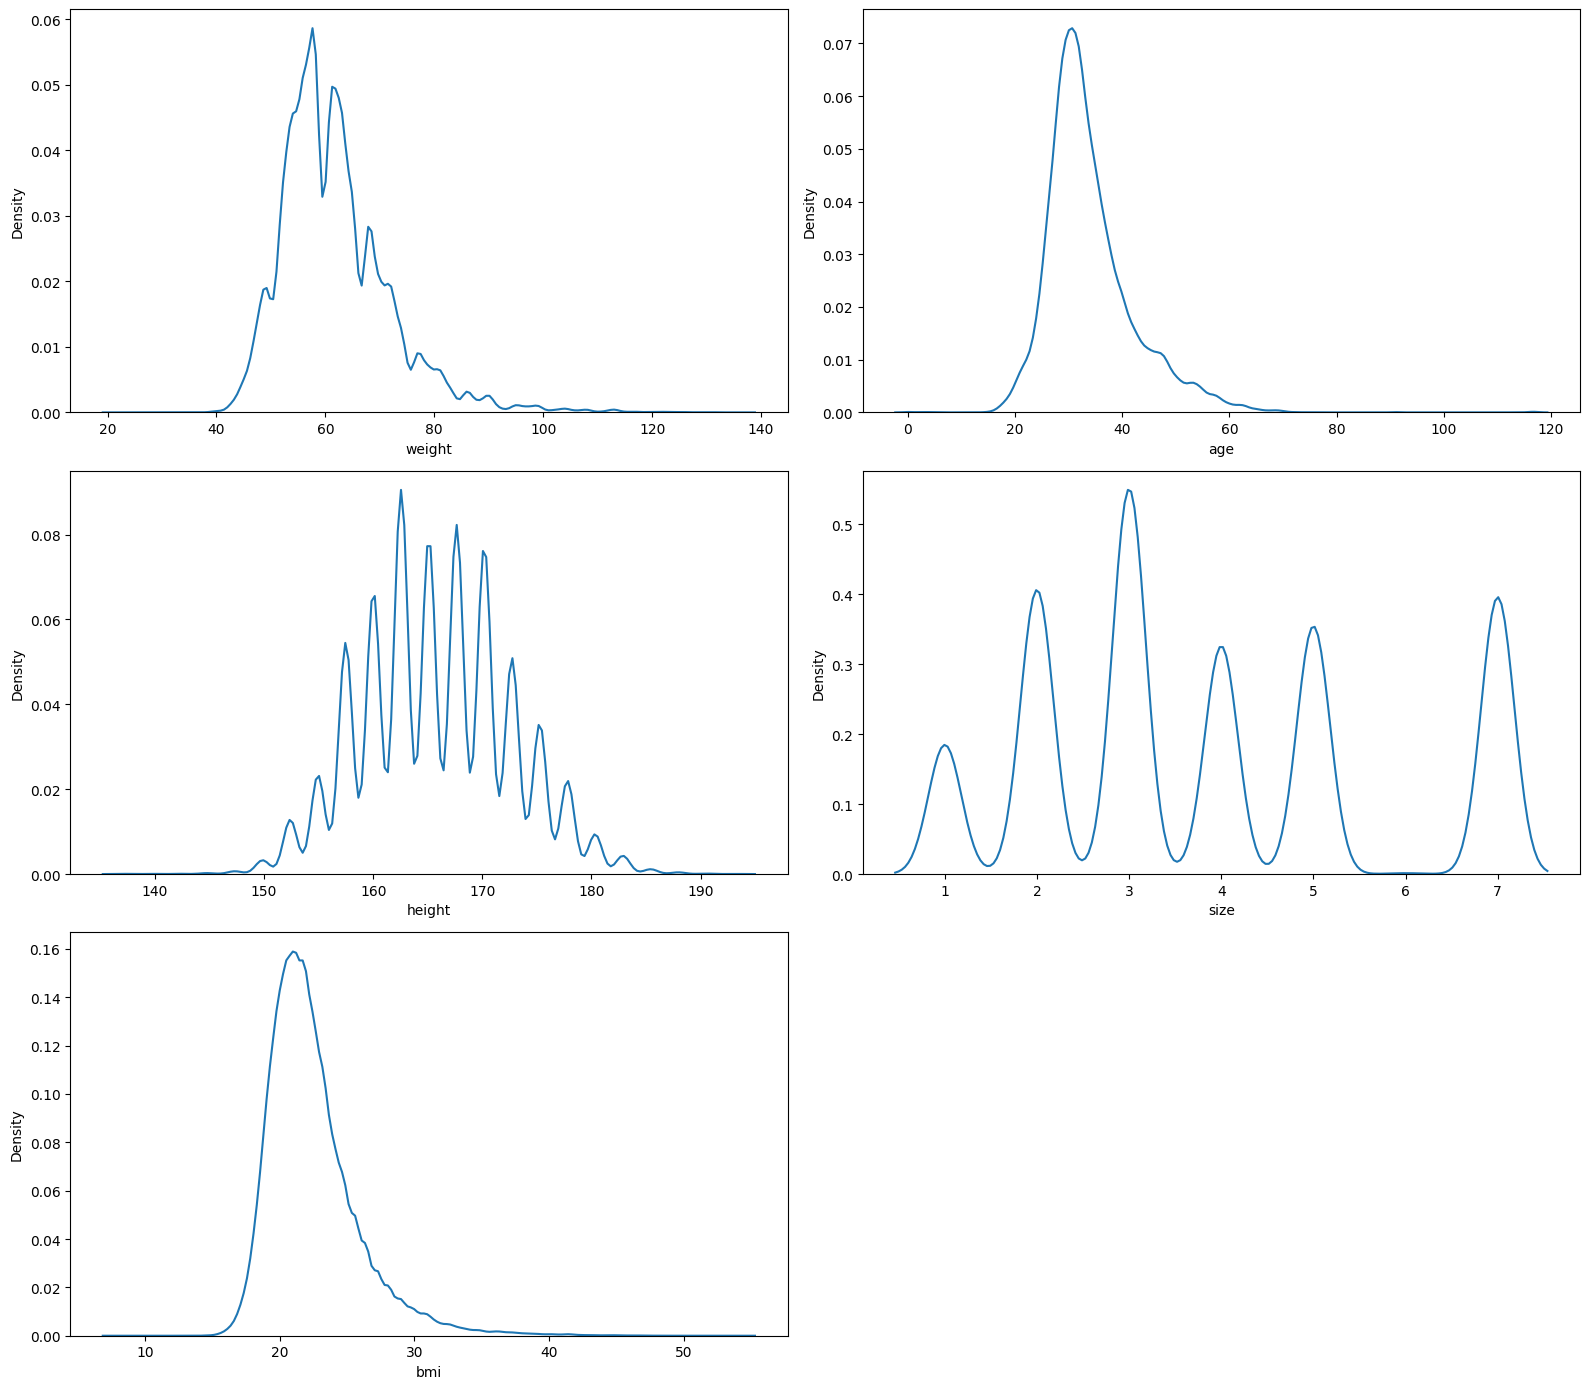

In [ ]:
plt.figure(figsize=(16,14))
for i,col in enumerate(df.columns):
    plt.subplot(3,2,i+1)
    sns.kdeplot(data=df[col])
    plt.tight_layout()

# **CORR**

In [ ]:
df

,weight,age,height,size,bmi
0,62,28.0,172.72,5,20.782914
1,59,36.0,167.64,4,20.994073
2,61,34.0,165.10,3,22.378743
3,65,27.0,175.26,4,21.161563
4,62,45.0,172.72,3,20.782914
...,...,...,...,...,...
119729,63,42.0,175.26,3,20.510438
119730,45,29.0,154.94,2,18.744999
119731,61,31.0,172.72,3,20.447705
119732,74,31.0,167.64,5,26.331549


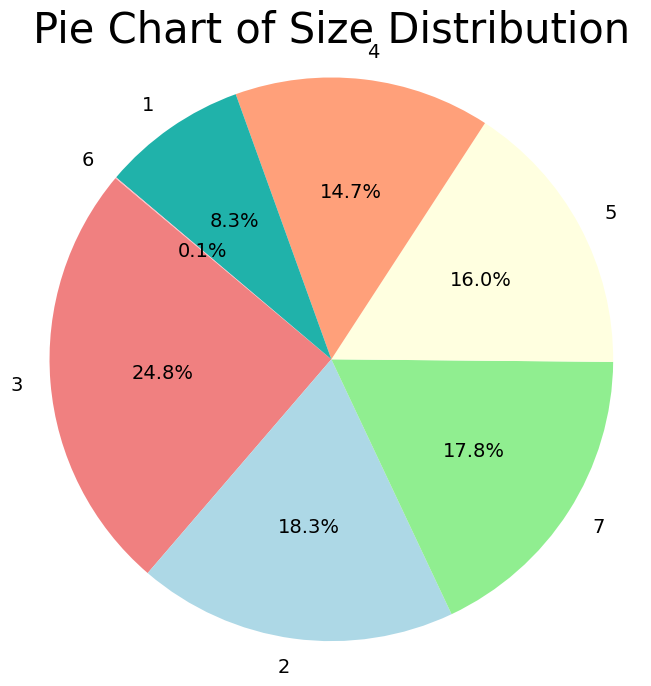

In [ ]:
import matplotlib.pyplot as plt

# Hitung jumlah masing-masing jenis 'size'
size_counts = df['size'].value_counts()

# Label untuk setiap jenis 'size'
labels = size_counts.index

# Jumlah data untuk setiap jenis 'size'
sizes = size_counts.values

# Warna yang akan digunakan dalam diagram lingkaran
colors = ['lightcoral', 'lightblue', 'lightgreen', 'lightyellow', 'lightsalmon', 'lightseagreen', 'lightpink']

# Plot diagram lingkaran
plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140, textprops={'fontsize': 14})
plt.title('Pie Chart of Size Distribution', fontsize=30)
plt.axis('equal')  # Untuk membuat lingkaran terlihat sempurna
plt.show()


In [ ]:
# Menggunakan pandas untuk melihat baris dengan 'size' bernilai 6
data_size_6 = df[df['size'] == 6]

# Menampilkan data yang memiliki 'size' bernilai 6
print(data_size_6)


        weight   age  height  size        bmi
1755        68  28.0  157.48     6  27.419410
2744        61  47.0  157.48     6  24.596823
4770        62  42.0  154.94     6  25.826442
4895        58  27.0  157.48     6  23.387144
5323        72  29.0  160.02     6  28.117970
...        ...   ...     ...   ...        ...
112707      68  24.0  149.86     6  30.278716
114732      74  30.0  160.02     6  28.899025
114803      69  32.0  160.02     6  26.946388
114994      64  46.0  160.02     6  24.993751
117637      77  29.0  167.64     6  27.399045

[69 rows x 5 columns]


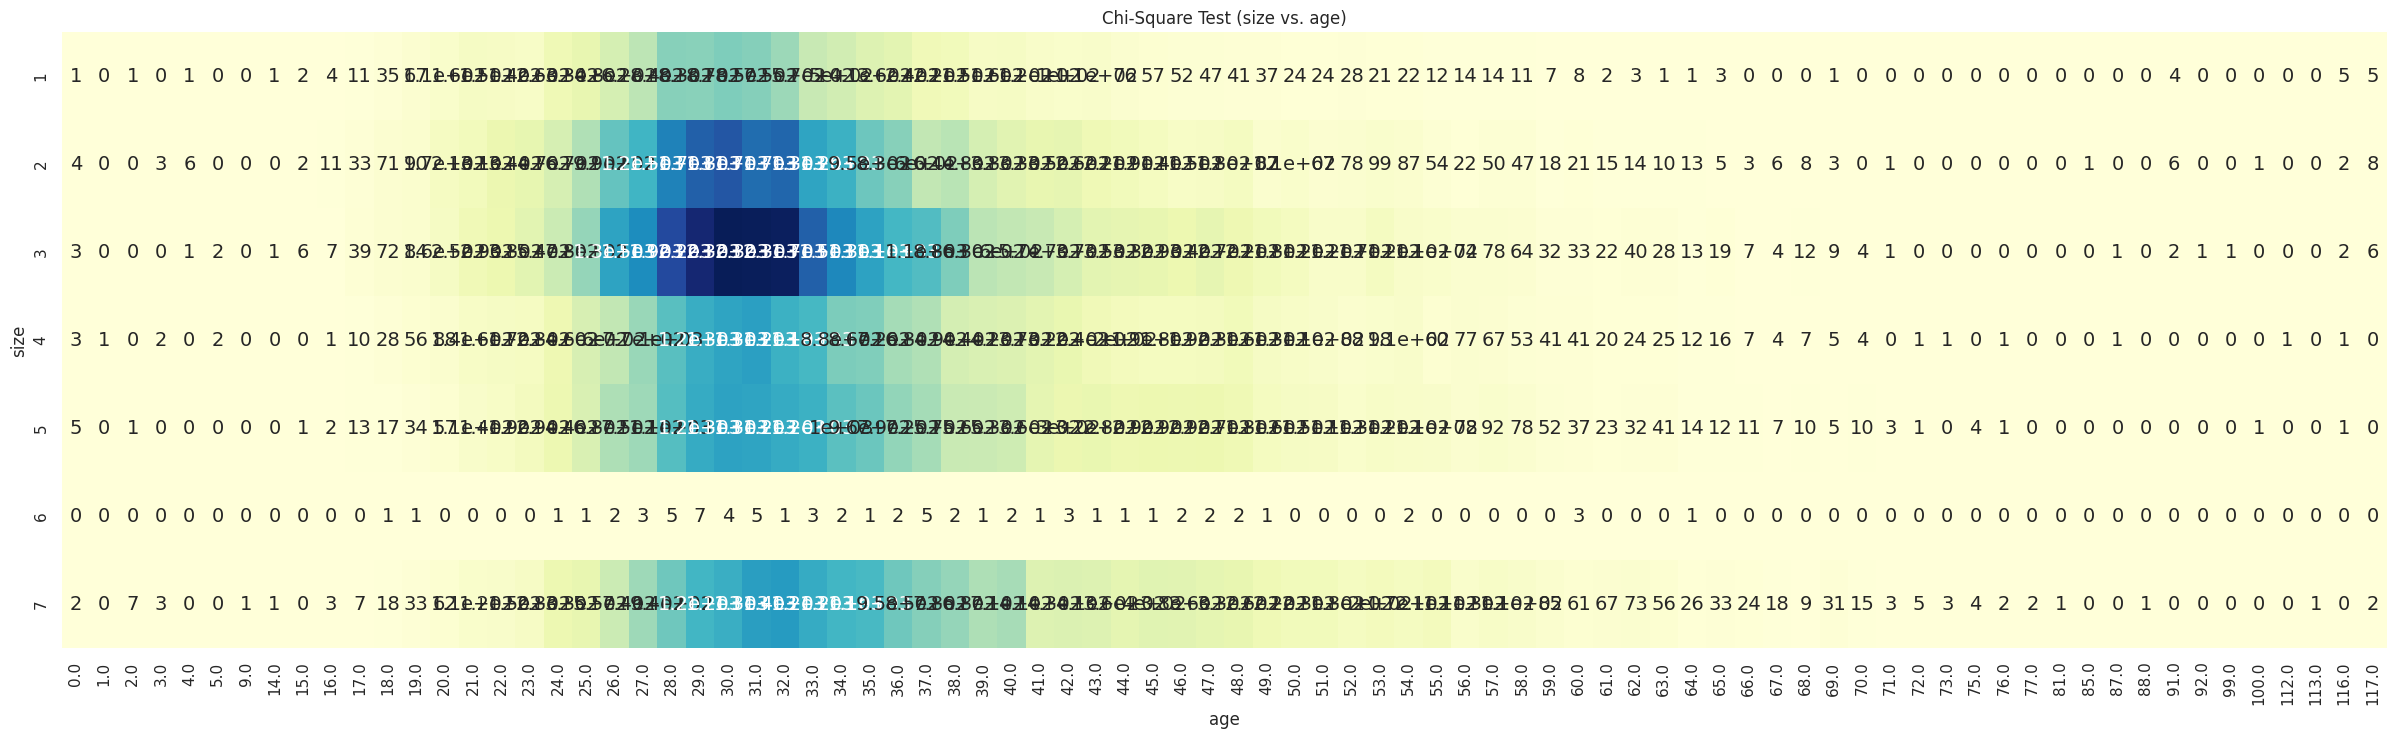

In [ ]:
import pandas as pd
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt


# Hitung uji chi-square untuk kolom 'size' dengan kolom 'age'
chi2, p, _, _ = chi2_contingency(pd.crosstab(df['size'], df['age']))

# Visualisasikan sebaran data (Contingency Table)
sns.set(rc={'figure.figsize':(30,8)})
sns.heatmap(pd.crosstab(df['size'], df['age']), annot=True, cmap='YlGnBu', cbar=False, annot_kws={"size": 14})
plt.title('Chi-Square Test (size vs. age)')
plt.show()


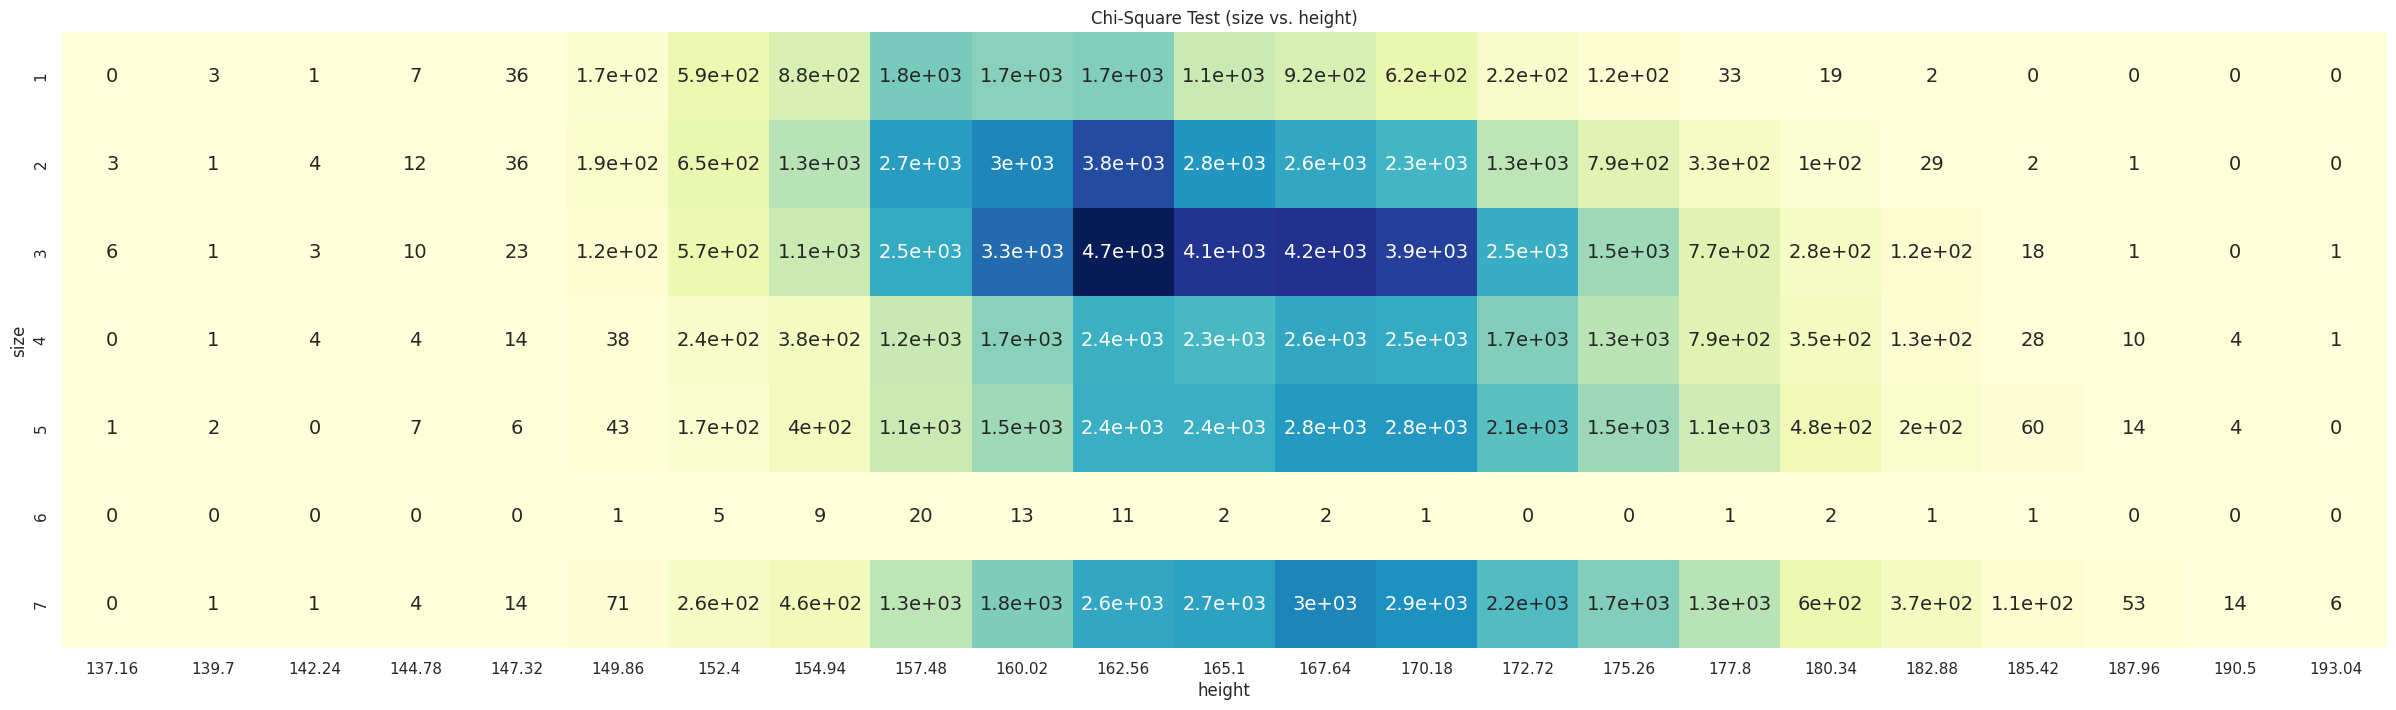

In [ ]:
import pandas as pd
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt


# Hitung uji chi-square untuk kolom 'size' dengan kolom 'height'
chi2, p, _, _ = chi2_contingency(pd.crosstab(df['size'], df['height']))

# Visualisasikan sebaran data (Contingency Table)
sns.set(rc={'figure.figsize':(30,8)})
sns.heatmap(pd.crosstab(df['size'], df['height']), annot=True, cmap='YlGnBu', cbar=False, annot_kws={"size": 14})
plt.title('Chi-Square Test (size vs. height)')
plt.show()


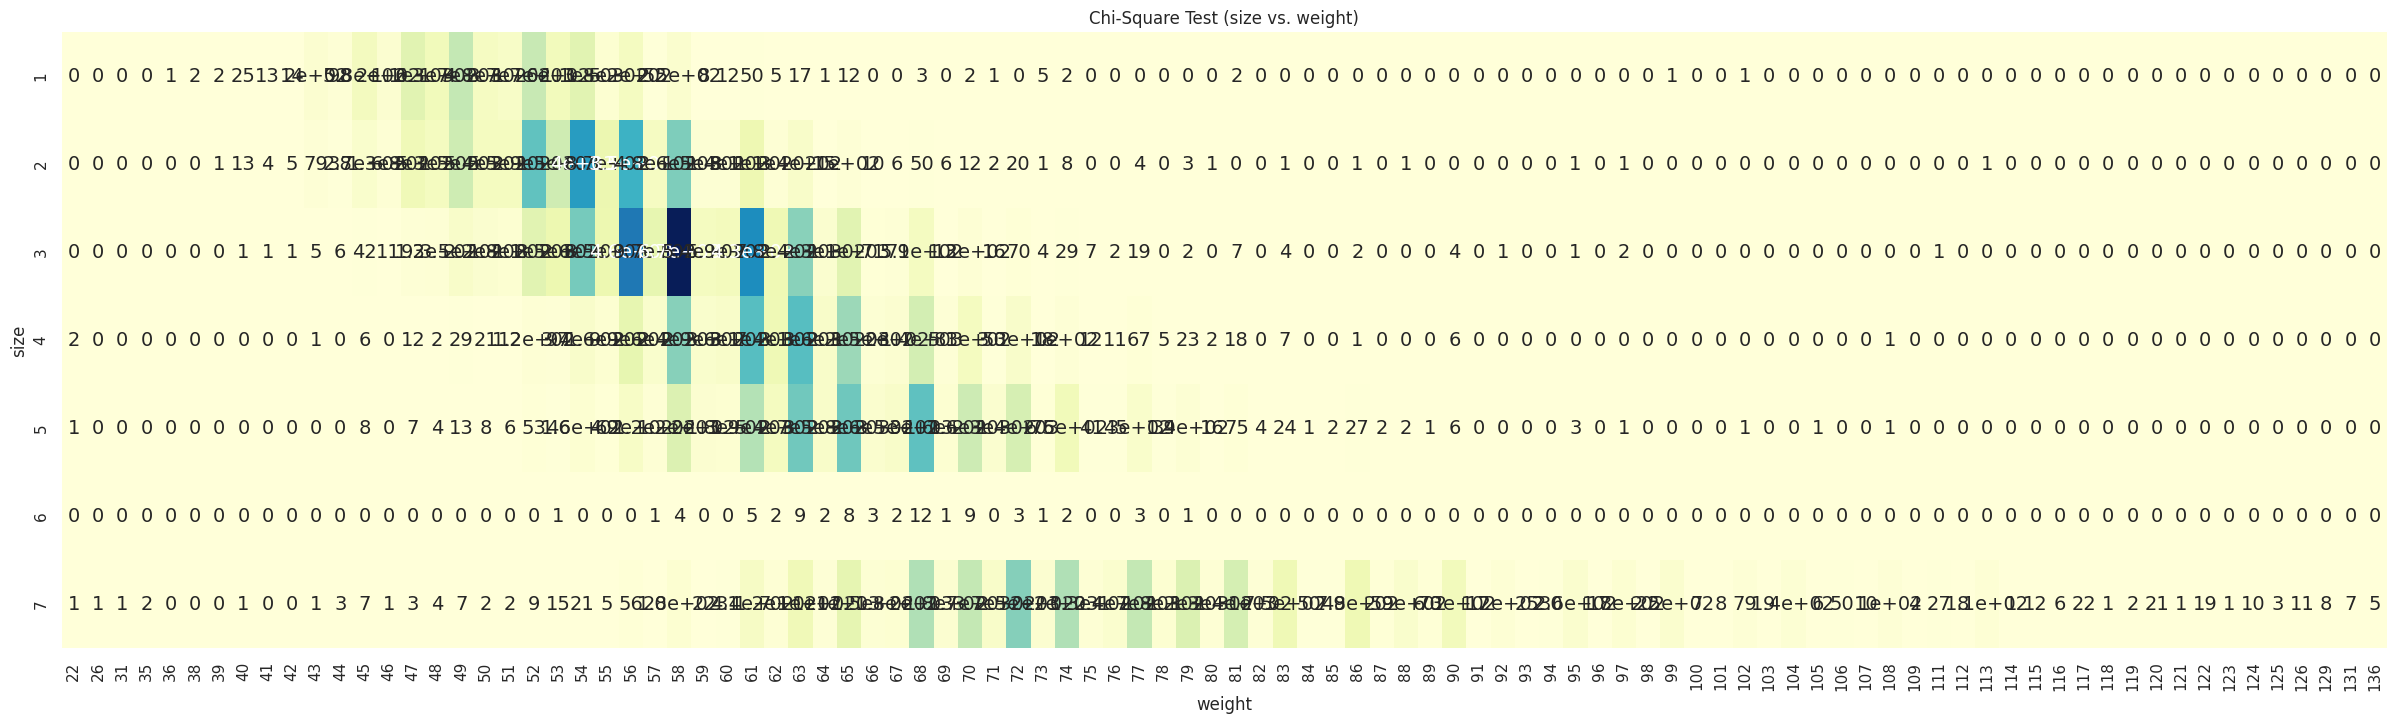

In [ ]:
import pandas as pd
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt


# Hitung uji chi-square untuk kolom 'size' dengan kolom 'weight'
chi2, p, _, _ = chi2_contingency(pd.crosstab(df['size'], df['weight']))

# Visualisasikan sebaran data (Contingency Table)
sns.set(rc={'figure.figsize':(30,8)})
sns.heatmap(pd.crosstab(df['size'], df['weight']), annot=True, cmap='YlGnBu', cbar=False, annot_kws={"size": 14})
plt.title('Chi-Square Test (size vs. weight)')
plt.show()

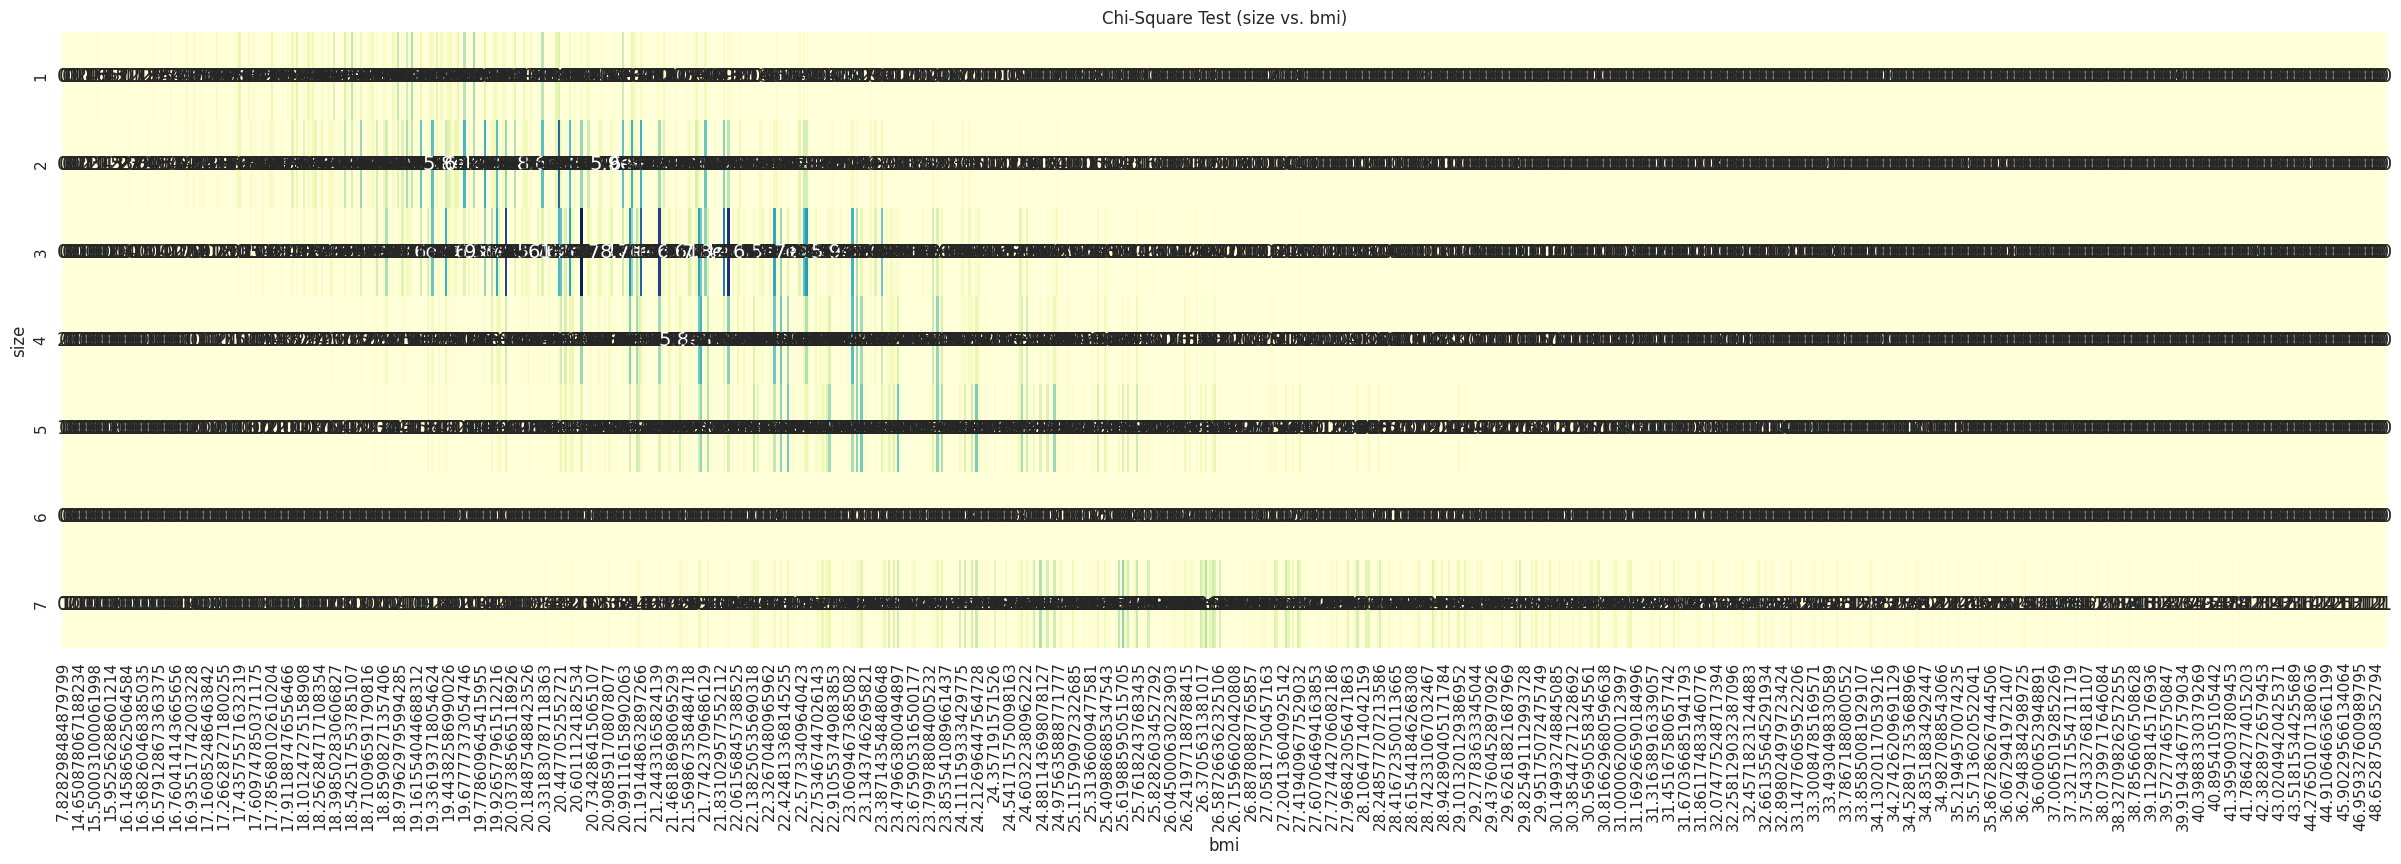

In [ ]:
import pandas as pd
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt


# Hitung uji chi-square untuk kolom 'size' dengan kolom 'bmi'
chi2, p, _, _ = chi2_contingency(pd.crosstab(df['size'], df['bmi']))

# Visualisasikan sebaran data (Contingency Table)
sns.set(rc={'figure.figsize':(30,8)})
sns.heatmap(pd.crosstab(df['size'], df['bmi']), annot=True, cmap='YlGnBu', cbar=False, annot_kws={"size": 14})
plt.title('Chi-Square Test (size vs. bmi)')
plt.show()

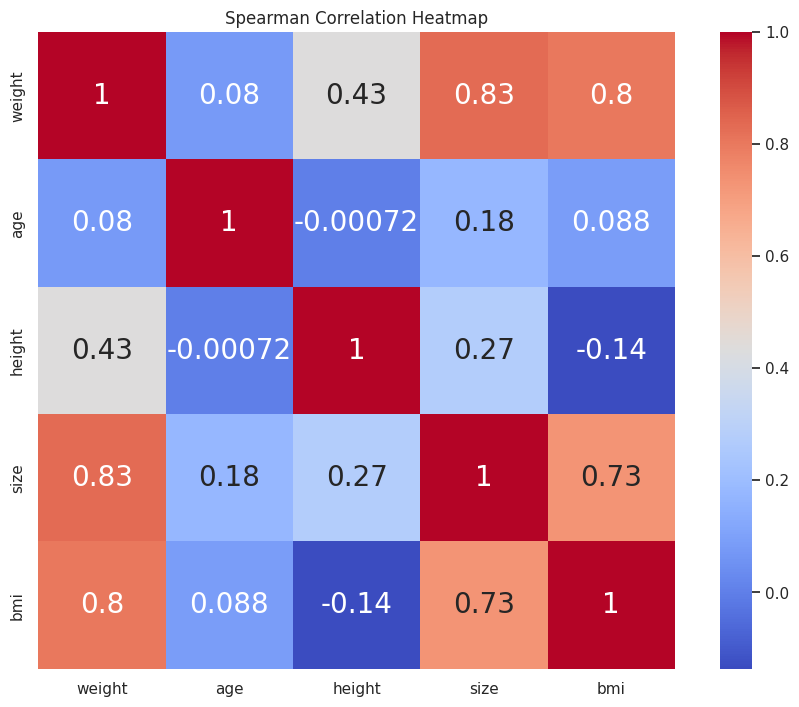

In [ ]:
import pandas as pd
from scipy.stats import spearmanr

spearman_corr = df.corr(method='spearman')

sns.set(rc={'figure.figsize':(11.7,8.27)})
ax = sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', square=True, annot_kws={"size": 20})
plt.title('Spearman Correlation Heatmap')
plt.show()


[Text(0.5, 57.219999999999985, 'Pearson Correlation Coefficient Heatmap')]

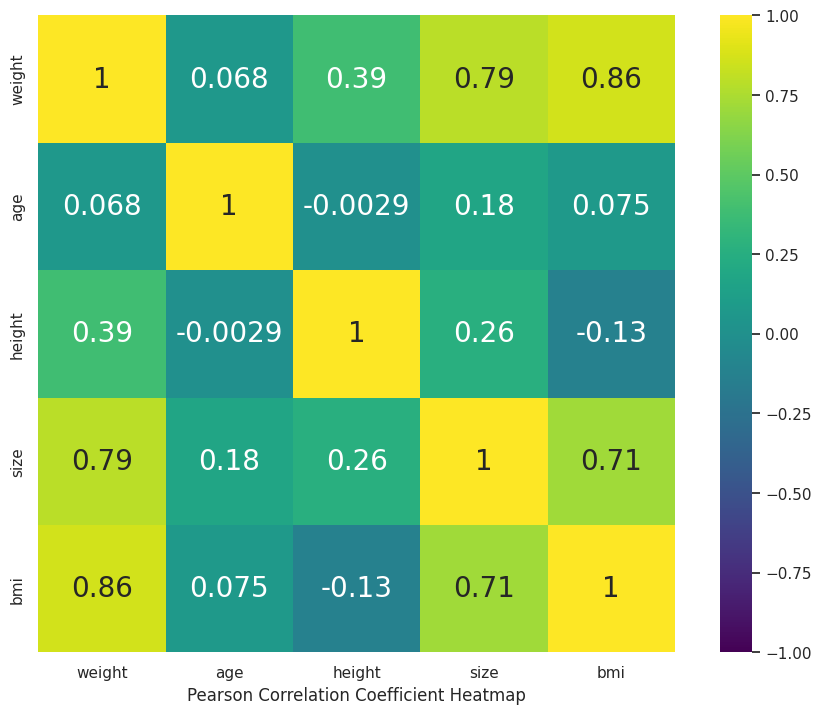

In [ ]:
sns.set(rc={'figure.figsize':(11.7,8.27)})
Heated = sns.heatmap(df.corr("pearson"),vmin=-1, vmax=1,cmap='viridis',annot=True, square=True, annot_kws={"size": 20})
Heated.set(xlabel = "Pearson Correlation Coefficient Heatmap")

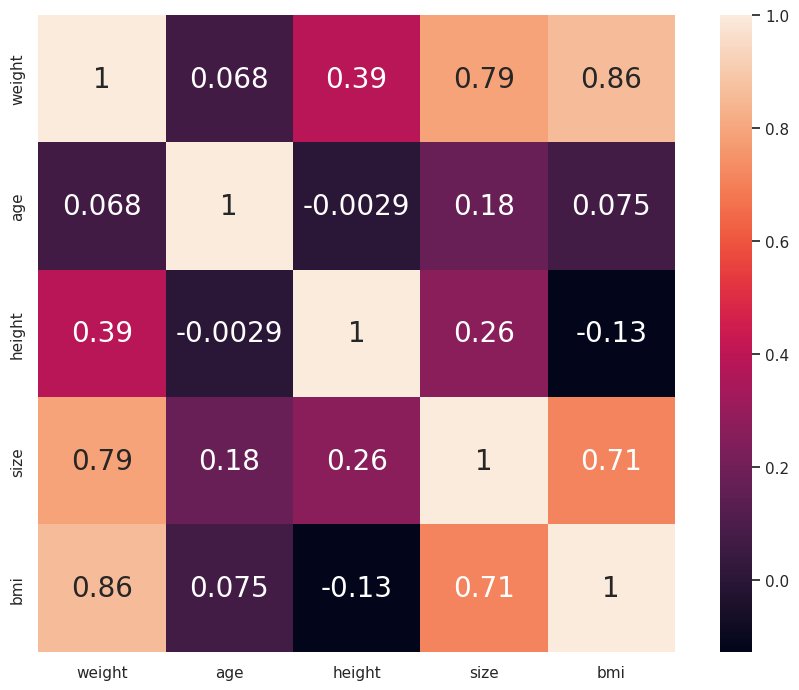

In [ ]:
corr = sns.heatmap(df.corr(), annot=True, square=True, annot_kws={"size": 20})

# **C_OUTLIERS**

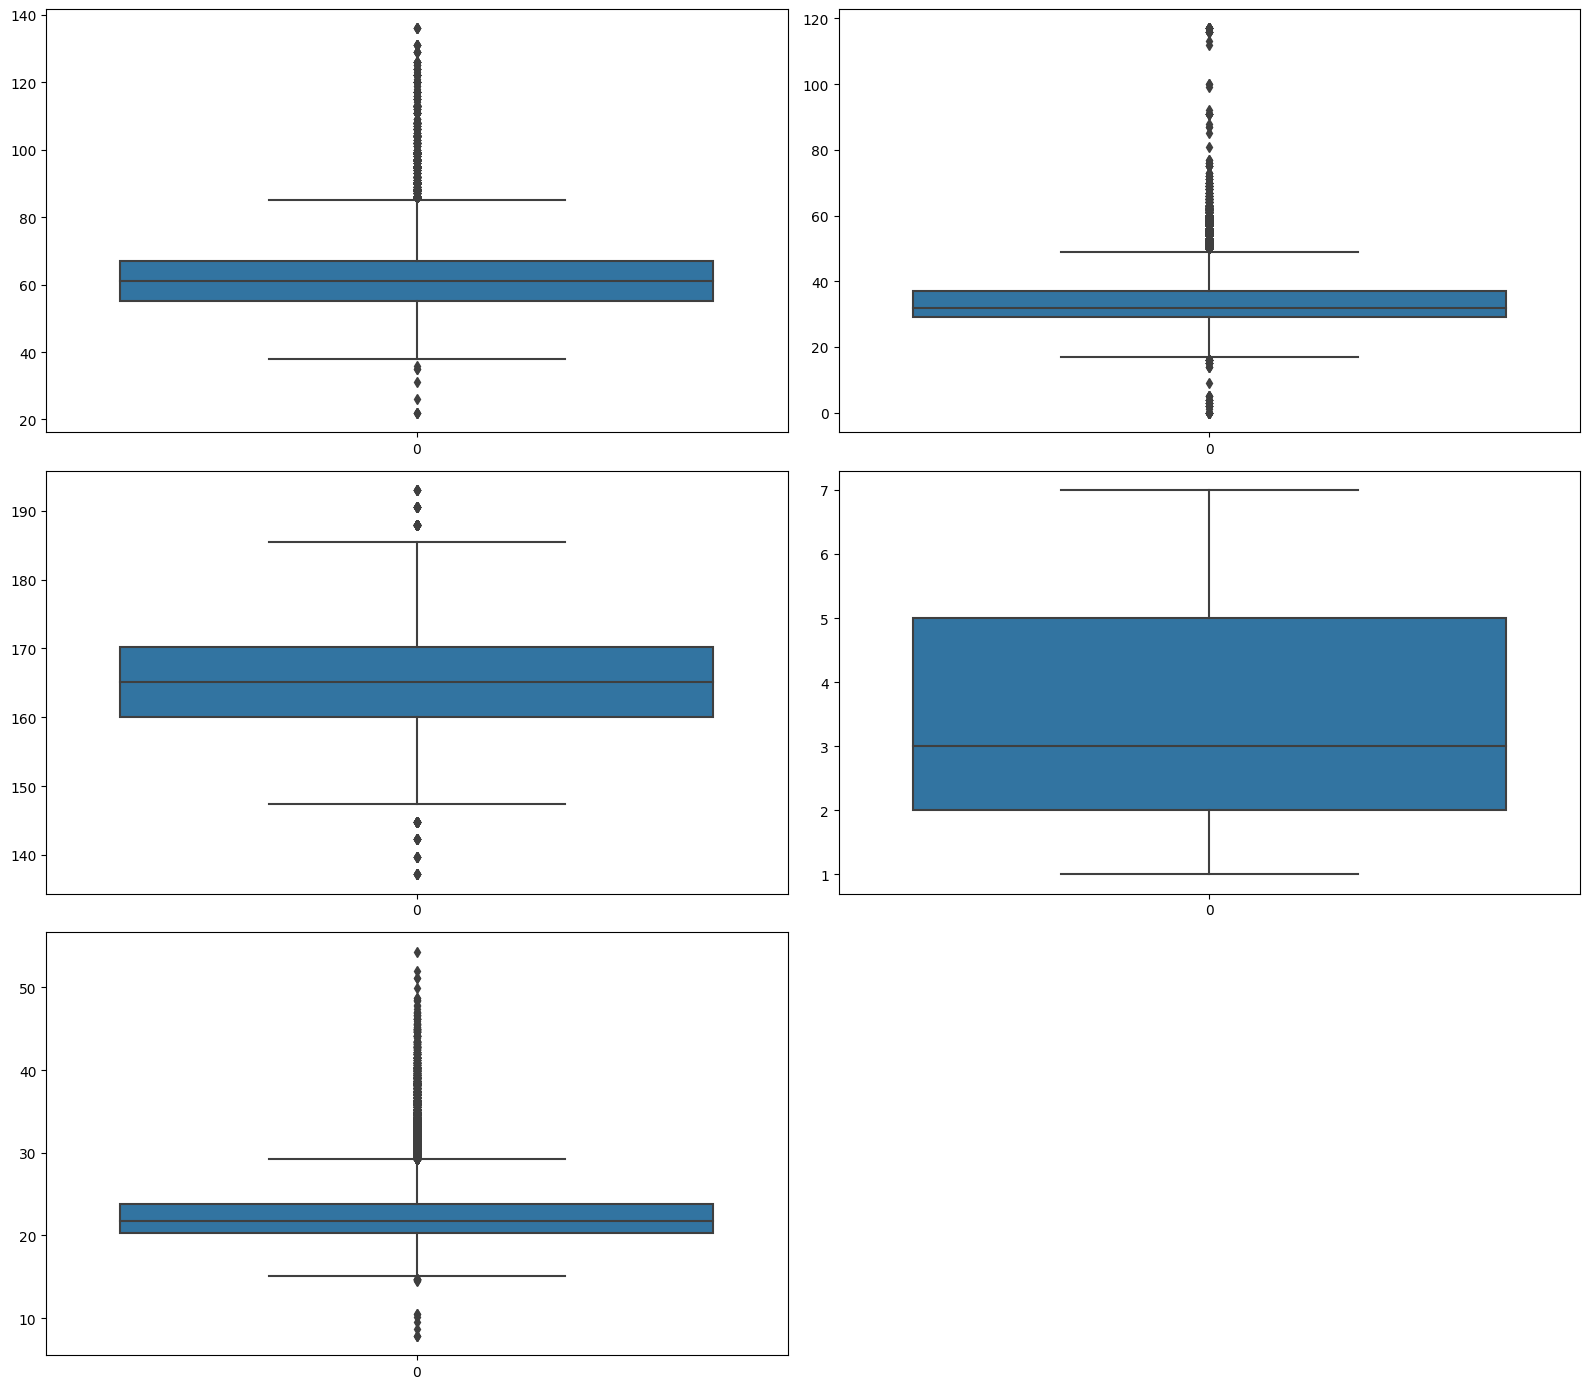

In [ ]:
plt.figure(figsize=(16,14))
for i,col in enumerate(df.columns):
    plt.subplot(3,2,i+1)
    sns.boxplot(data=df[col])

    plt.tight_layout()

# Weight1

[(22.0, 136.0)]

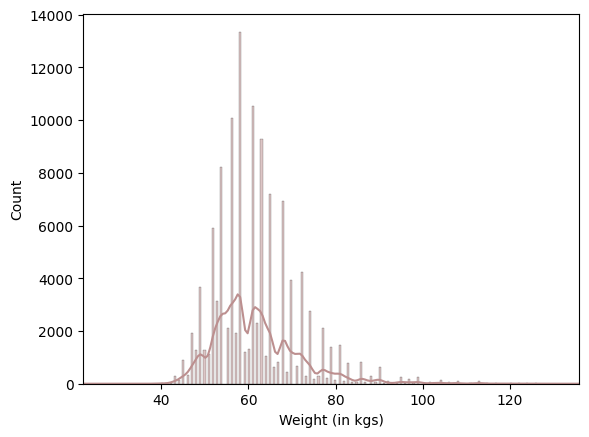

In [ ]:
count_plotted = sns.histplot(x = 'weight', data = df, kde = True, color = 'rosybrown')
count_plotted.set(xlabel = "Weight (in kgs)")
count_plotted.set(xlim = (22.0000,136.0000))

[(22.0, 136.0)]

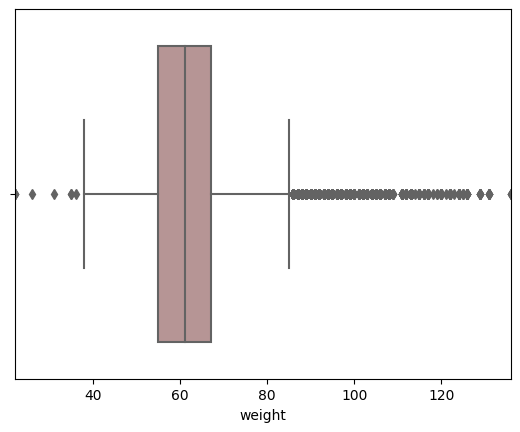

In [ ]:
boxxer_plot = sns.boxplot(x = 'weight', data = df, color = 'rosybrown')
boxxer_plot.set(xlim = (22.0000,136.0000))

In [ ]:
numpy_array = np.array(df['weight'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 37.0000 or greater than 85.0000
There are 3510 outliers.


# **Drop_Outlier**

In [ ]:
import pandas as pd
import numpy as np

# Anda memiliki DataFrame df dengan kolom 'weight'

# Menghitung nilai lower_bound dan upper_bound
percentile_1, percentile_2 = np.percentile(df['weight'], [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds

# Mengidentifikasi outliers
outliers = df[(df['weight'] < lower_bound) | (df['weight'] > upper_bound)]

# Menghapus baris dengan outliers
df_cleaned = df[~((df['weight'] < lower_bound) | (df['weight'] > upper_bound))]

print("The outliers are values less than {:.4f} or greater than {:.4f}".format(lower_bound, upper_bound))
print("There are", len(outliers), "outliers.")

# df_cleaned adalah DataFrame baru tanpa outliers



The outliers are values less than 37.0000 or greater than 85.0000
There are 3510 outliers.


In [ ]:
# Anda memiliki DataFrame df_cleaned dengan kolom 'height'

# Menghitung nilai lower_bound dan upper_bound
percentile_1, percentile_2 = np.percentile(df_cleaned['height'], [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds

# Mengidentifikasi outliers
outliers = df_cleaned[(df_cleaned['height'] < lower_bound) | (df_cleaned['height'] > upper_bound)]

# Menghapus baris dengan outliers
df_cleaned_cleaned = df_cleaned[~((df_cleaned['height'] < lower_bound) | (df_cleaned['height'] > upper_bound))]

print("The outliers are values less than {:.4f} or greater than {:.4f}".format(lower_bound, upper_bound))
print("There are", len(outliers), "outliers.")

# df_cleaned_cleaned adalah DataFrame baru tanpa outliers


The outliers are values less than 144.7800 or greater than 185.4200
There are 162 outliers.


In [ ]:
# Anda memiliki DataFrame df_cleaned_cleaned dengan kolom 'age'

# Menghitung nilai lower_bound dan upper_bound
percentile_1, percentile_2 = np.percentile(df_cleaned_cleaned['age'], [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds

# Mengidentifikasi outliers
outliers = df_cleaned_cleaned[(df_cleaned_cleaned['age'] < lower_bound) | (df_cleaned_cleaned['age'] > upper_bound)]

# Menghapus baris dengan outliers
df_cleaned_cleaned_cleaned = df_cleaned_cleaned[~((df_cleaned_cleaned['age'] < lower_bound) | (df_cleaned_cleaned['age'] > upper_bound))]

print("The outliers are values less than {:.4f} or greater than {:.4f}".format(lower_bound, upper_bound))
print("There are", len(outliers), "outliers.")

# df_cleaned_cleaned adalah DataFrame baru tanpa outliers


The outliers are values less than 17.0000 or greater than 49.0000
There are 6457 outliers.


[(0.0, 117.0)]

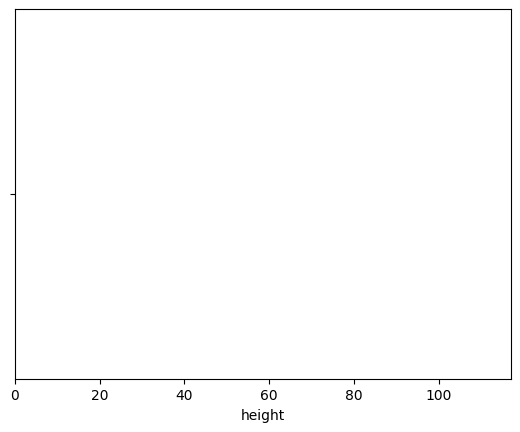

In [ ]:
boxxer_plot = sns.boxplot(x = 'height', data = df_cleaned_cleaned, color = 'rosybrown')
boxxer_plot.set(xlim = (0.0000, 117.0000))

In [ ]:
df_cleaned_cleaned_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 109605 entries, 0 to 119733
Data columns (total 5 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   weight  109605 non-null  int64  
 1   age     109605 non-null  float64
 2   height  109605 non-null  float64
 3   size    109605 non-null  int64  
 4   bmi     109605 non-null  float64
dtypes: float64(3), int64(2)
memory usage: 5.0 MB


In [ ]:
df

,weight,age,height,size,bmi
0,62,28.0,172.72,5,20.782914
1,59,36.0,167.64,4,20.994073
2,61,34.0,165.10,3,22.378743
3,65,27.0,175.26,4,21.161563
4,62,45.0,172.72,3,20.782914
...,...,...,...,...,...
119729,63,42.0,175.26,3,20.510438
119730,45,29.0,154.94,2,18.744999
119731,61,31.0,172.72,3,20.447705
119732,74,31.0,167.64,5,26.331549


# AGE1

[(0.0, 117.0)]

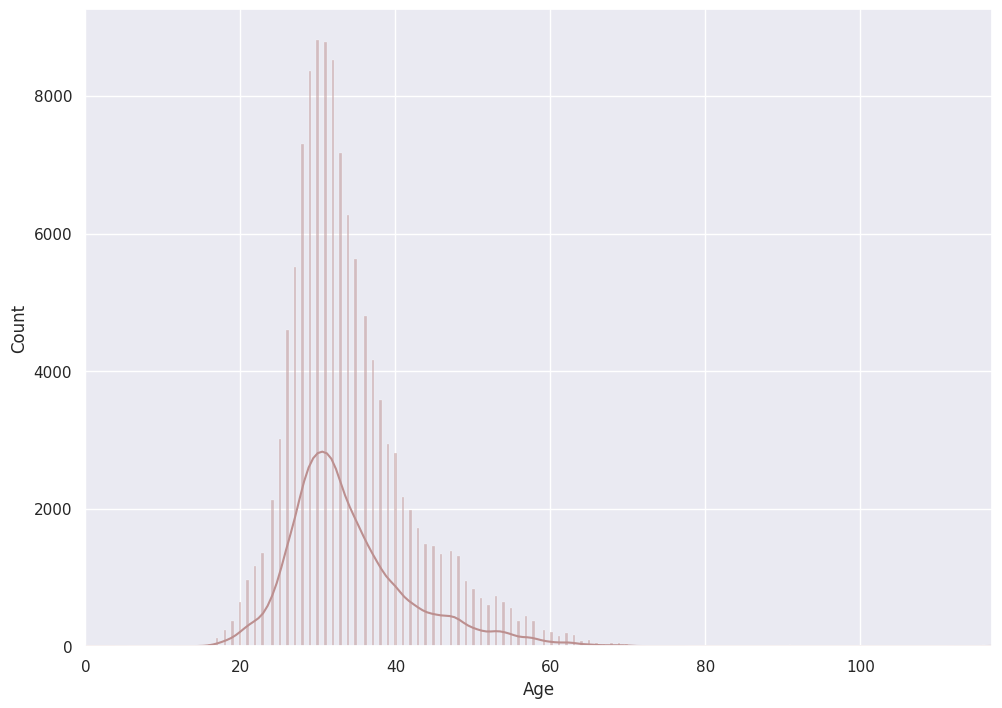

In [ ]:
count_plotted = sns.histplot(x = 'age', data = df, kde = True, color = 'rosybrown')
count_plotted.set(xlabel = "Age")
count_plotted.set(xlim = (0.0000, 117.0000))

[(0.0, 117.0)]

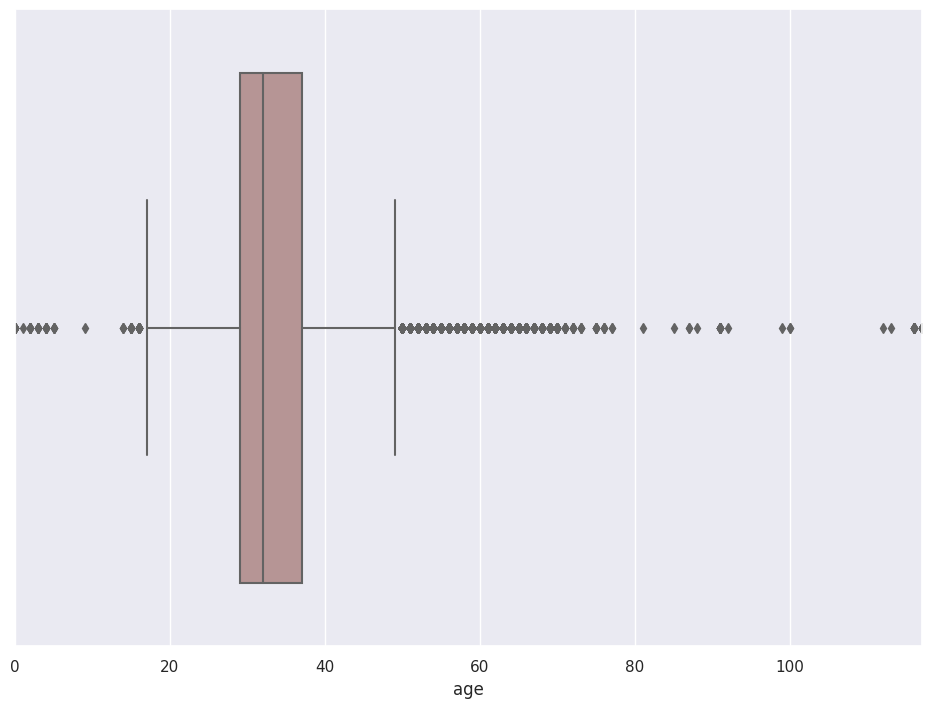

In [ ]:
boxxer_plot = sns.boxplot(x = 'age', data = df, color = 'rosybrown')
boxxer_plot.set(xlim = (0.0000, 117.0000))

In [ ]:
numpy_array = np.array(df['age'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 17.0000 or greater than 49.0000
There are 6726 outliers.


# HEIGHT1

[(137.16, 193.04)]

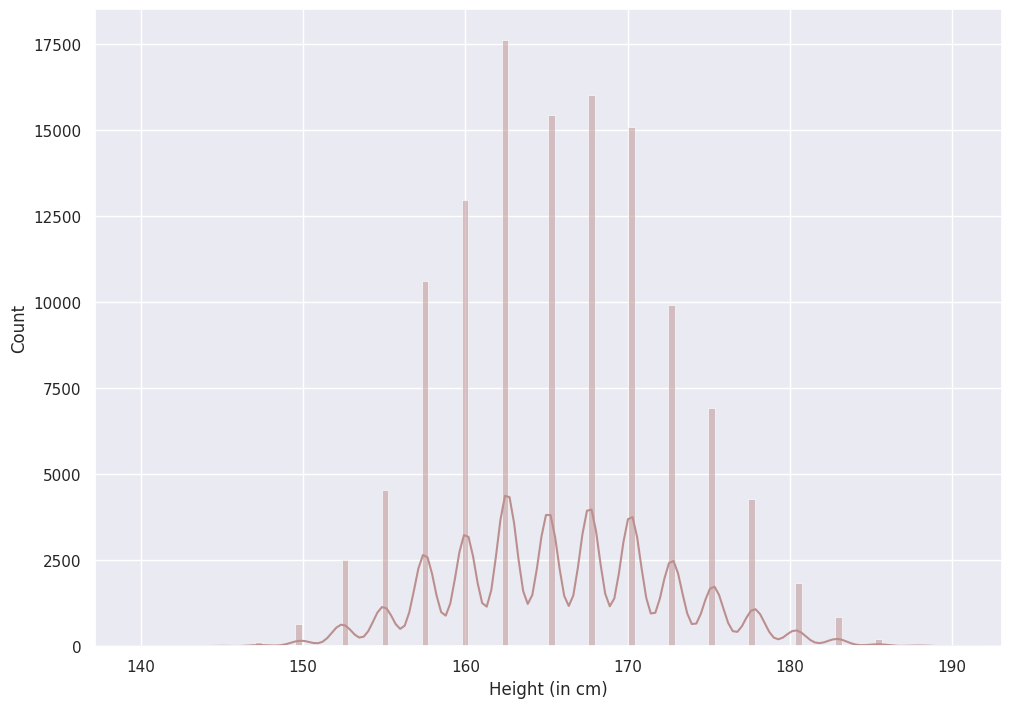

In [ ]:
count_plotted = sns.histplot(x = 'height', data = df, kde = True, color = 'rosybrown')
count_plotted.set(xlabel = "Height (in cm)")
count_plotted.set(xlim = (137.1600, 193.0400))

[(137.16, 193.04)]

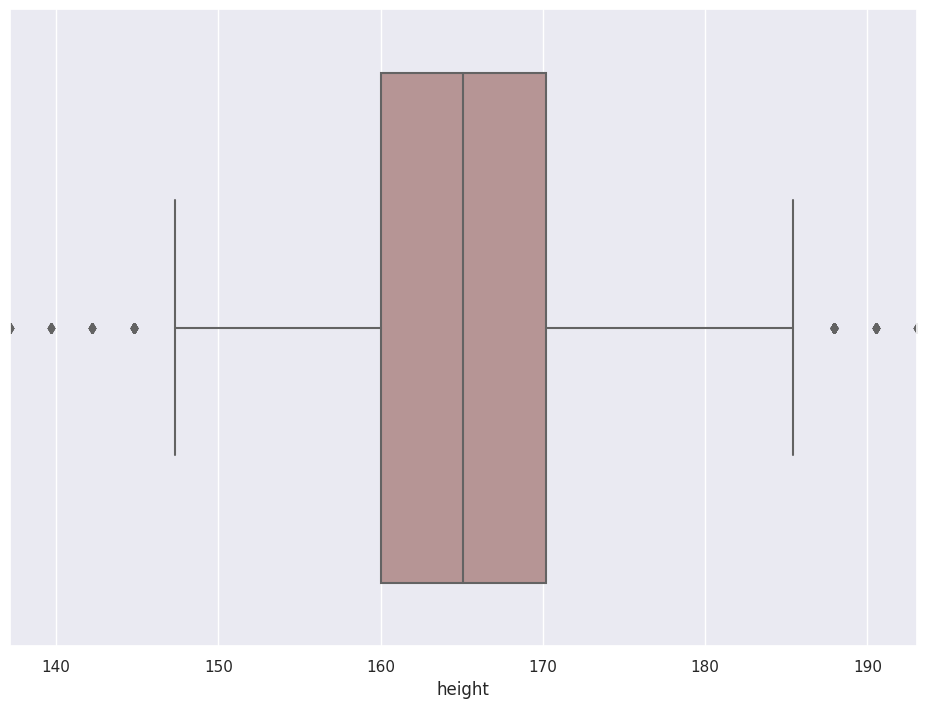

In [ ]:
boxxer_plot = sns.boxplot(x = 'height', data = df, color = 'rosybrown')
boxxer_plot.set(xlim = (137.1600, 193.0400))

In [ ]:
numpy_array = np.array(df['height'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 144.7800 or greater than 185.4200
There are 185 outliers.


# Size1

[(1.0, 7.0)]

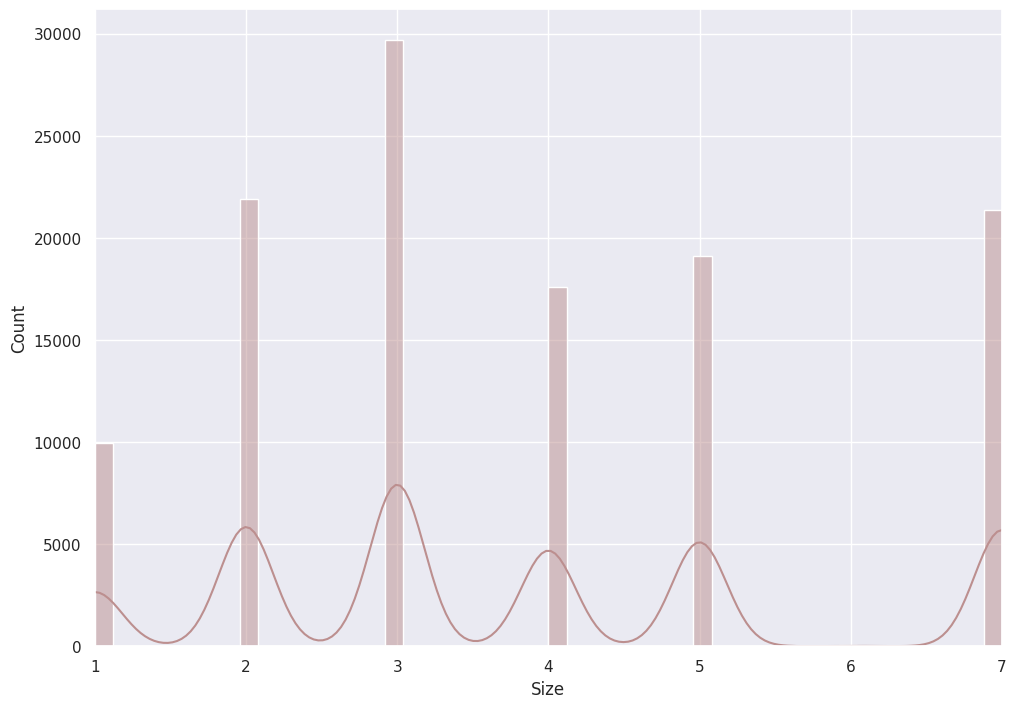

In [ ]:
count_plotted = sns.histplot(x = 'size', data = df, kde = True, color = 'rosybrown')
count_plotted.set(xlabel = "Size")
count_plotted.set(xlim = (1.0000, 7.0000))

[(1.0, 7.0)]

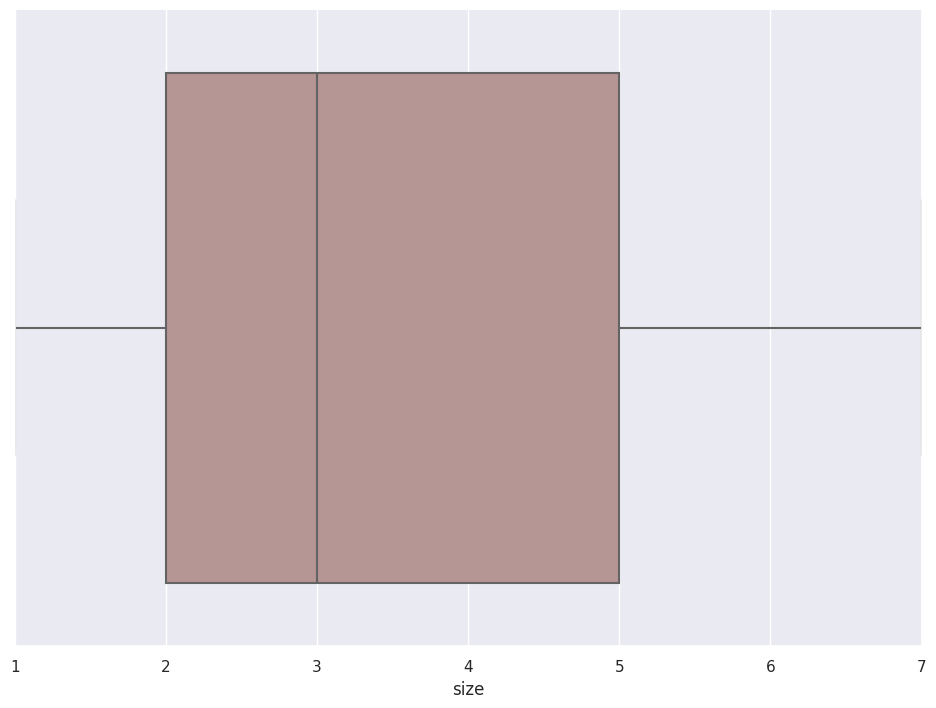

In [ ]:
boxxer_plot = sns.boxplot(x = 'size', data = df, color = 'rosybrown')
boxxer_plot.set(xlim = (1.0000, 7.0000))

In [ ]:
numpy_array = np.array(df['size'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values greater than 9.5000
There are 0 outliers.


# BMI1

[(7.8283, 54.3236)]

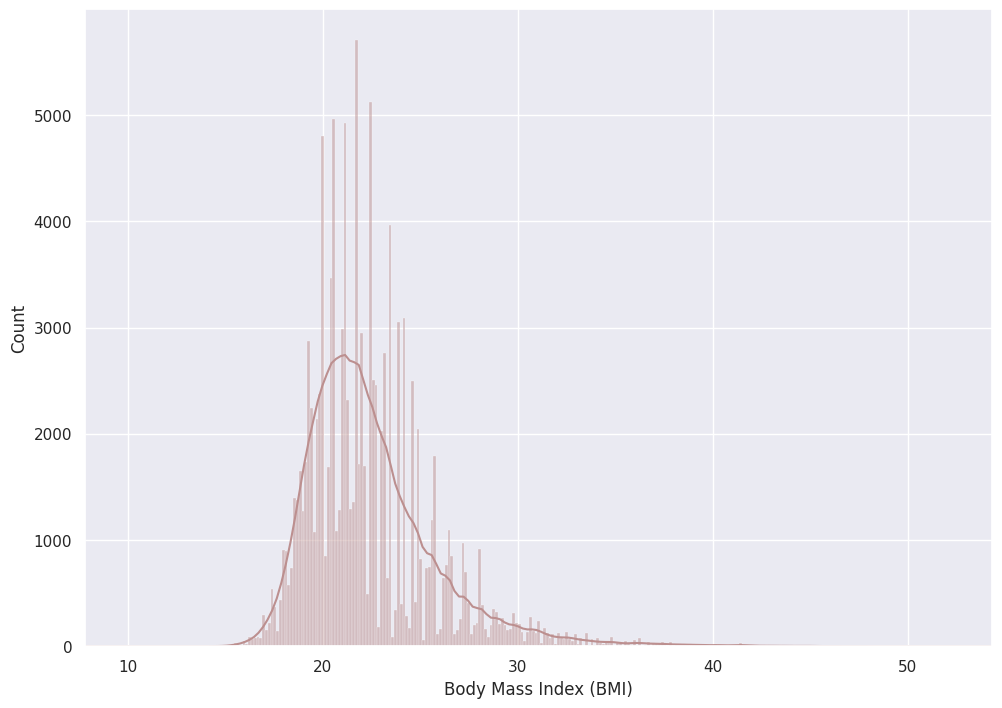

In [ ]:
count_plotted = sns.histplot(x = 'bmi', data = df, kde = True, color = 'rosybrown')
count_plotted.set(xlabel = "Body Mass Index (BMI)")
count_plotted.set(xlim = (7.8283, 54.3236))

[(7.8283, 54.3236)]

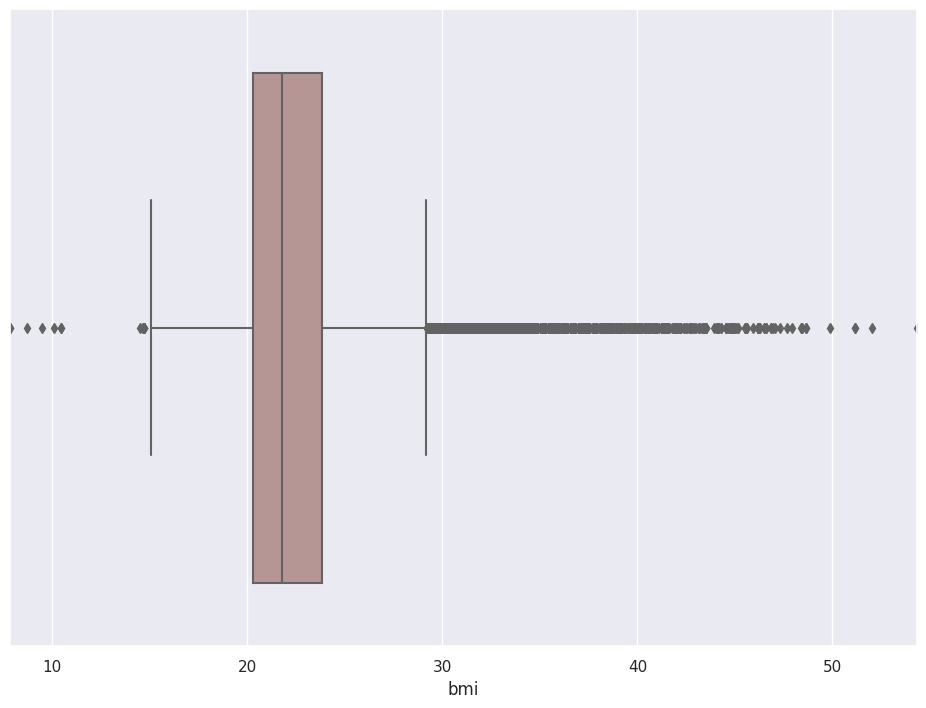

In [ ]:
boxxer_plot = sns.boxplot(x = 'bmi', data = df, color = 'rosybrown')
boxxer_plot.set(xlim = (7.8283, 54.3236))

In [ ]:
numpy_array = np.array(df['bmi'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 14.9449 or greater than 29.1782
There are 5166 outliers.


# **XXS**

[(22.0, 136.0)]

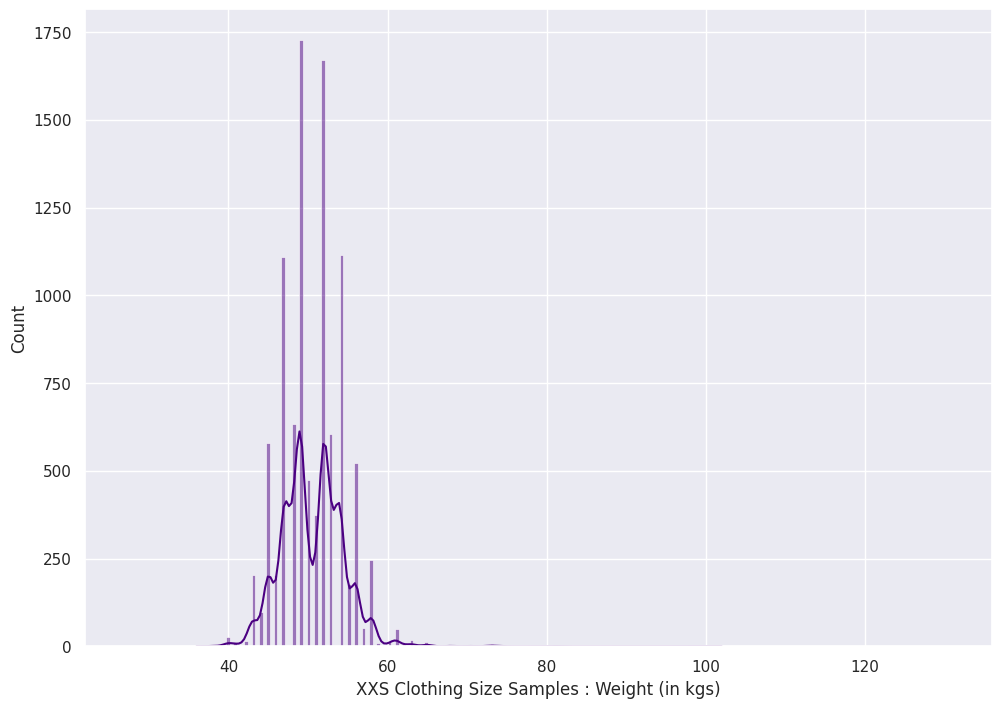

In [ ]:
count_plotted = sns.histplot(x = 'weight', data = df.loc[df['size'] == 1], kde = True, color = 'indigo')
count_plotted.set(xlabel = "XXS Clothing Size Samples : Weight (in kgs)")
count_plotted.set(xlim = (22.0000,136.0000))

[Text(0.5, 0, 'XXS Clothing Size Samples : Weight (in kgs)')]

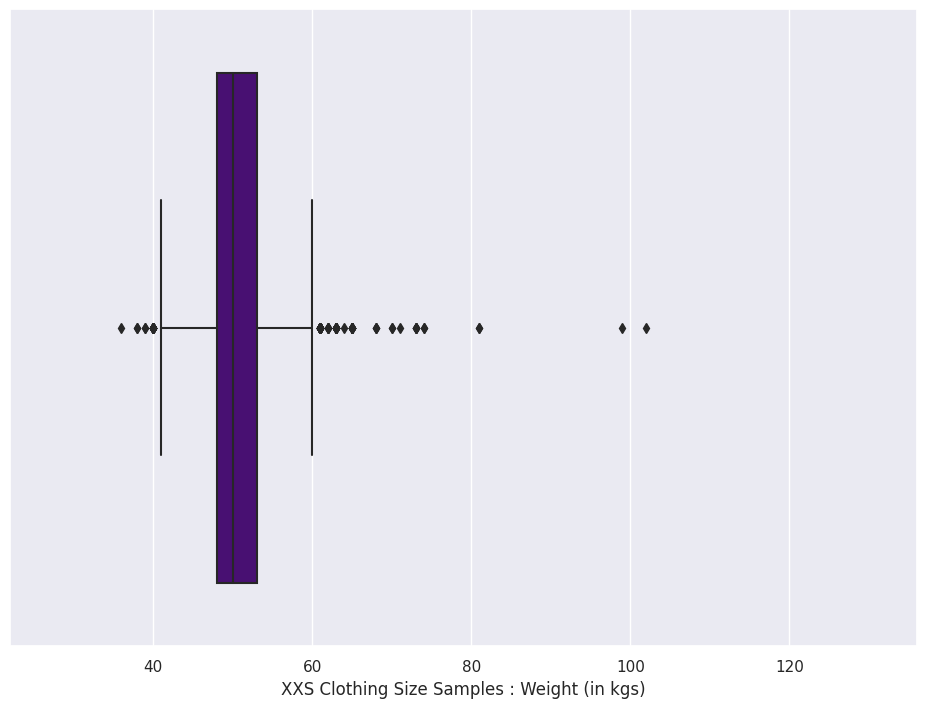

In [ ]:
boxxer_plot = sns.boxplot(x = 'weight', data = df.loc[df['size'] == 1], color = 'indigo')
boxxer_plot.set(xlim = (22.0000,136.0000))
boxxer_plot.set(xlabel = "XXS Clothing Size Samples : Weight (in kgs)")

In [ ]:
numpy_array = np.array(df.loc[df['size'] == 1]['weight'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 40.5000 or greater than 60.5000
There are 132 outliers.


[(0.0, 117.0)]

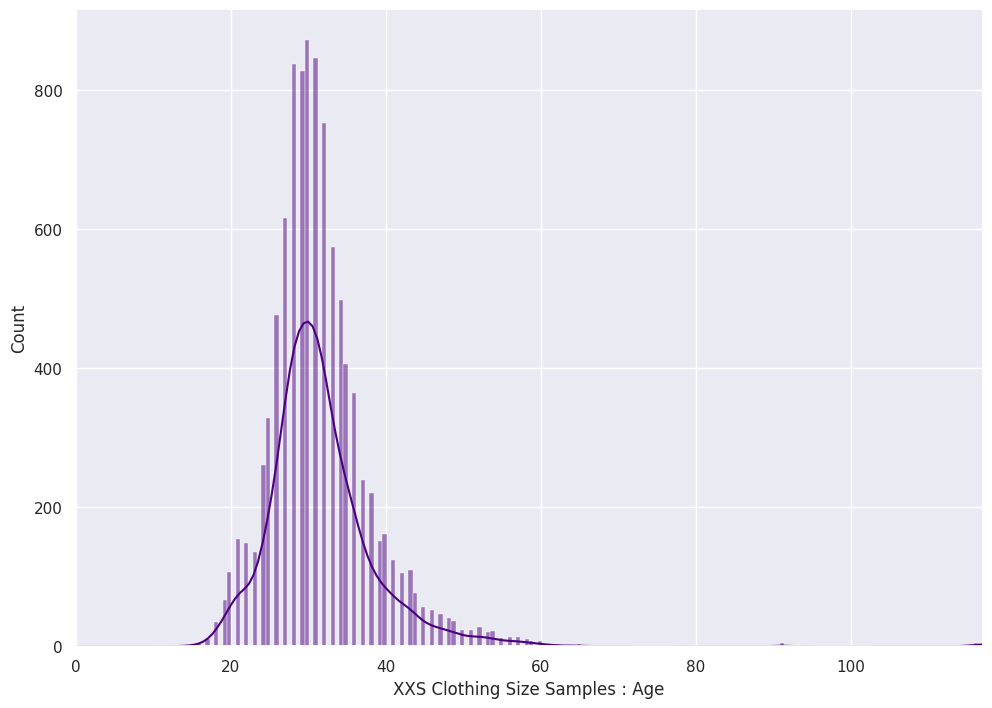

In [ ]:
count_plotted = sns.histplot(x = 'age', data = df.loc[df['size'] == 1], kde = True, color = 'indigo')
count_plotted.set(xlabel = "XXS Clothing Size Samples : Age")
count_plotted.set(xlim = (0.0000, 117.0000))

[Text(0.5, 0, 'XXS Clothing Size Samples : Age')]

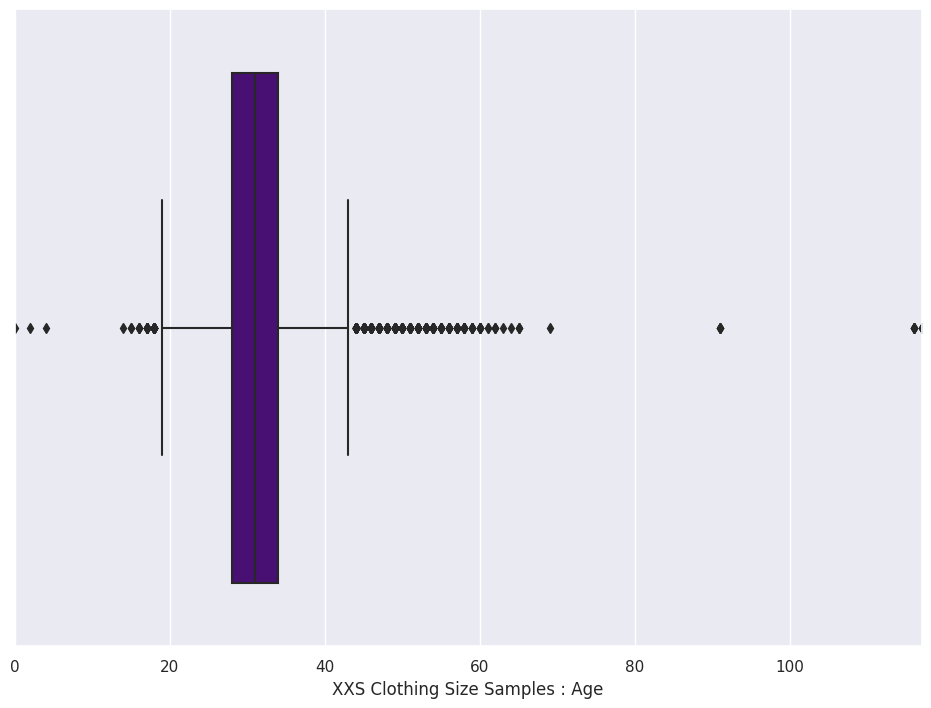

In [ ]:
boxxer_plot = sns.boxplot(x = 'age', data = df.loc[df['size'] == 1], color = 'indigo')
boxxer_plot.set(xlim = (0.0000, 117.0000))
boxxer_plot.set(xlabel = "XXS Clothing Size Samples : Age")

In [ ]:
numpy_array = np.array(df.loc[df['size'] == 1]['age'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 19.0000 or greater than 43.0000
There are 576 outliers.


[(137.16, 193.04)]

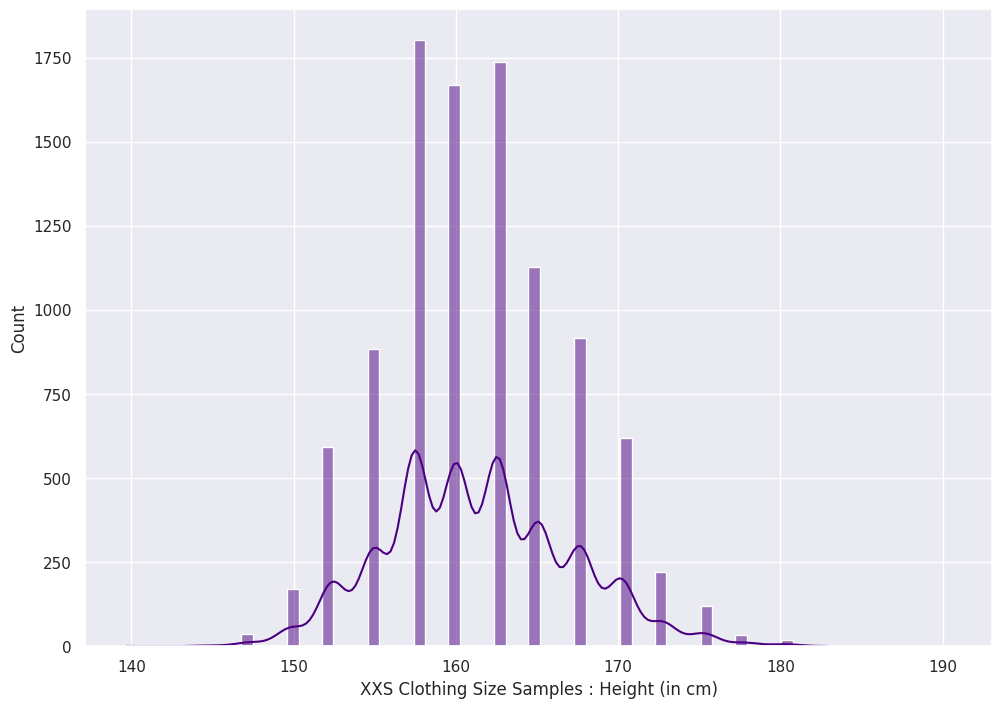

In [ ]:
count_plotted = sns.histplot(x = 'height', data = df.loc[df['size'] == 1], kde = True, color = 'indigo')
count_plotted.set(xlabel = "XXS Clothing Size Samples : Height (in cm)")
count_plotted.set(xlim = (137.1600, 193.0400))

[Text(0.5, 0, 'XXS Clothing Size Samples : Height (in cm)')]

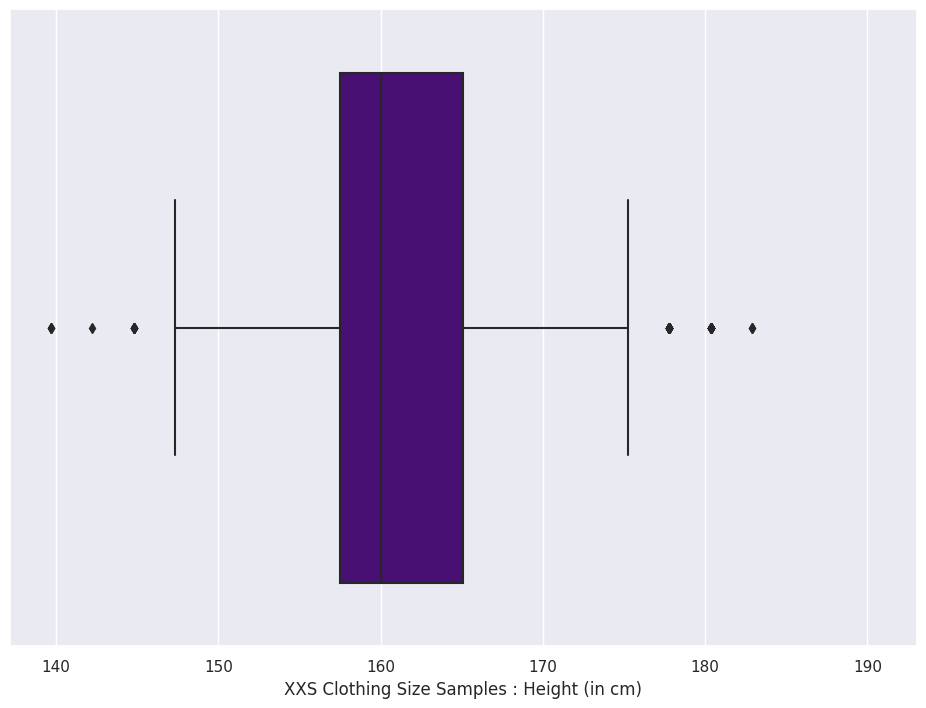

In [ ]:
boxxer_plot = sns.boxplot(x = 'height', data = df.loc[df['size'] == 1], color = 'indigo')
boxxer_plot.set(xlim = (137.1600, 193.0400))
boxxer_plot.set(xlabel = "XXS Clothing Size Samples : Height (in cm)")

In [ ]:
numpy_array = np.array(df.loc[df['size'] == 1]['height'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 146.0500 or greater than 176.5300
There are 65 outliers.


[(1.0, 7.0)]

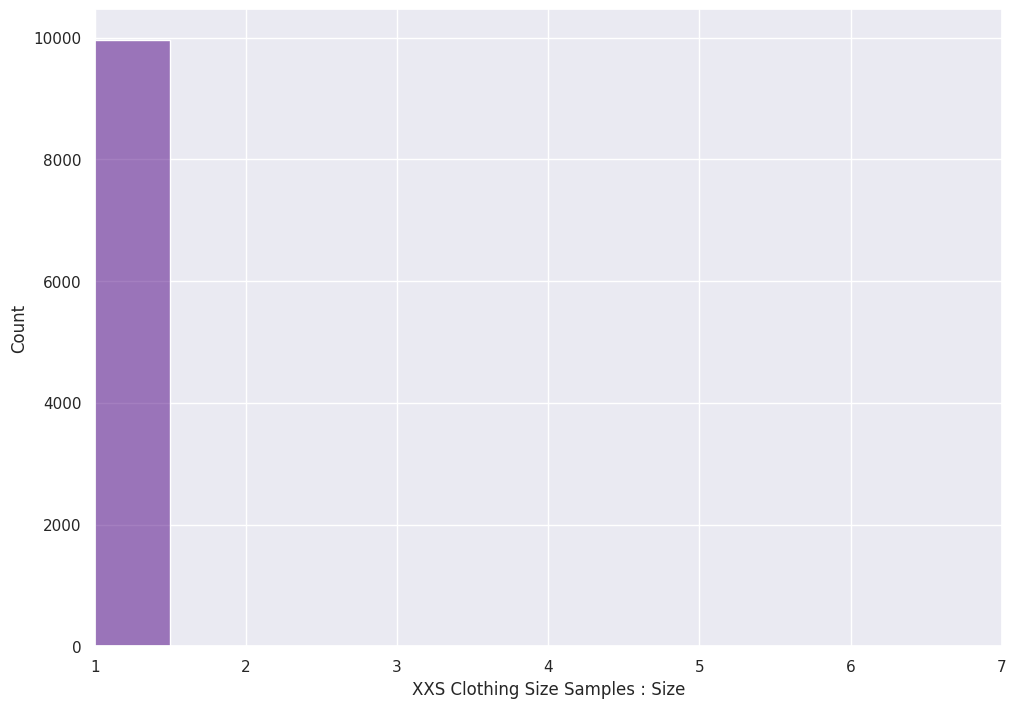

In [ ]:
count_plotted = sns.histplot(x = 'size', data = df.loc[df['size'] == 1], kde = True, color = 'indigo')
count_plotted.set(xlabel = "XXS Clothing Size Samples : Size")
count_plotted.set(xlim = (1.0000, 7.0000))

[Text(0.5, 0, 'XXS Clothing Size Samples : Size')]

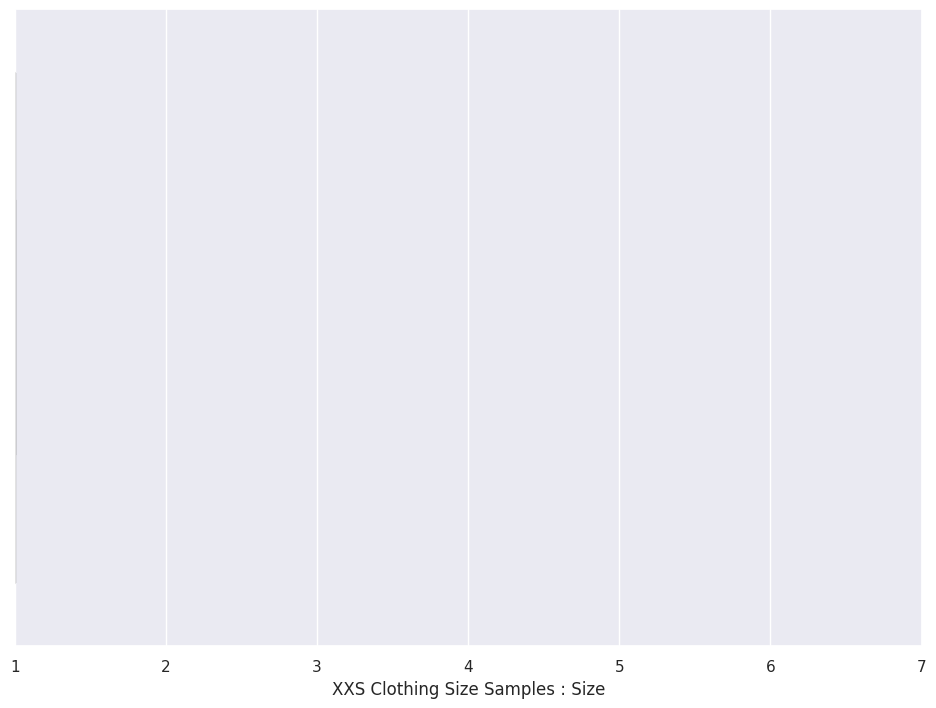

In [ ]:
boxxer_plot = sns.boxplot(x = 'size', data = df.loc[df['size'] == 1], color = 'indigo')
boxxer_plot.set(xlim = (1.0000, 7.0000))
boxxer_plot.set(xlabel = "XXS Clothing Size Samples : Size")

In [ ]:
numpy_array = np.array(df.loc[df['size'] == 1]['size'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 1.0000 or greater than 1.0000
There are 0 outliers.


[(7.8283, 54.3236)]

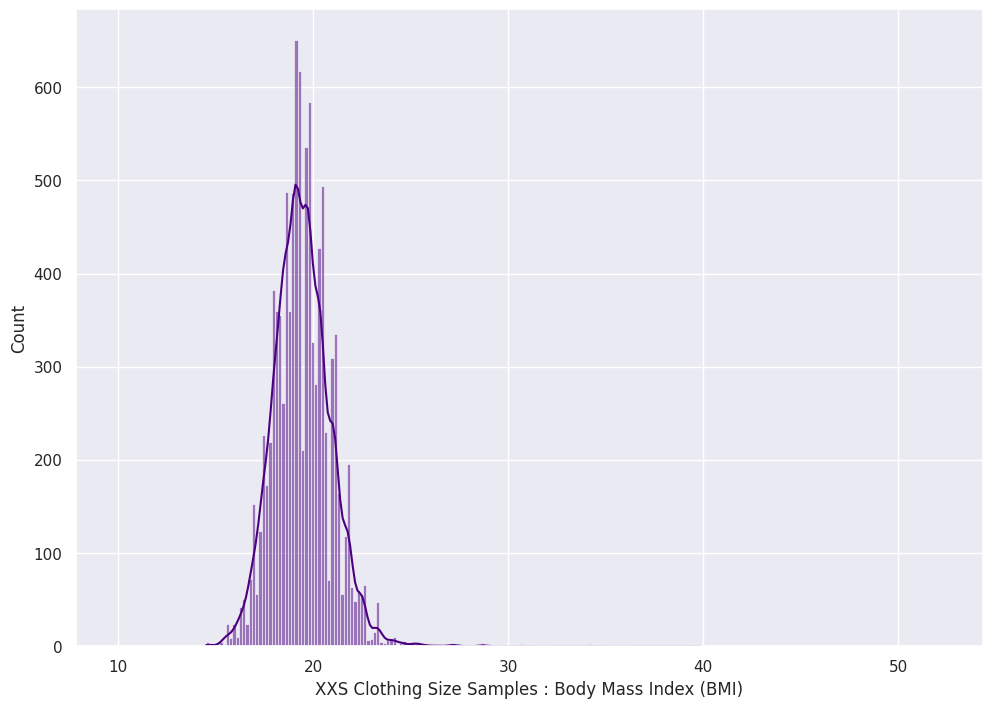

In [ ]:
count_plotted = sns.histplot(x = 'bmi', data = df.loc[df['size'] == 1], kde = True, color = 'indigo')
count_plotted.set(xlabel = "XXS Clothing Size Samples : Body Mass Index (BMI)")
count_plotted.set(xlim = (7.8283, 54.3236))

[Text(0.5, 0, 'XXS Clothing Size Samples : Body Mass Index (BMI)')]

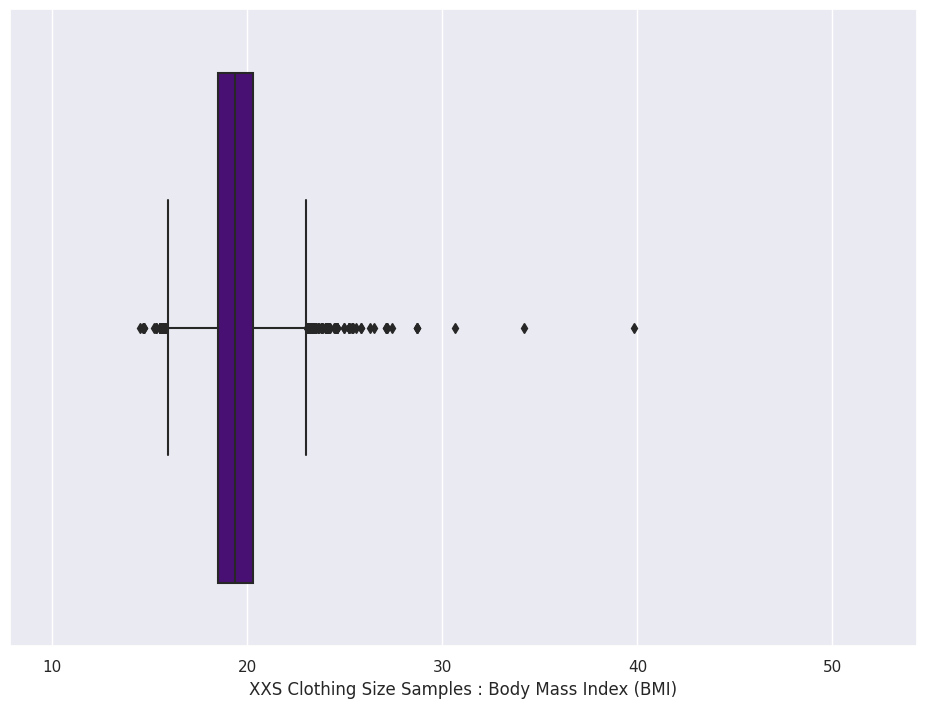

In [ ]:
boxxer_plot = sns.boxplot(x = 'bmi', data = df.loc[df['size'] == 1], color = 'indigo')
boxxer_plot.set(xlim = (7.8283, 54.3236))
boxxer_plot.set(xlabel = "XXS Clothing Size Samples : Body Mass Index (BMI)")

In [ ]:
numpy_array = np.array(df.loc[df['size'] == 1]['bmi'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 15.7970 or greater than 23.0137
There are 178 outliers.


# **S**

[(22.0, 136.0)]

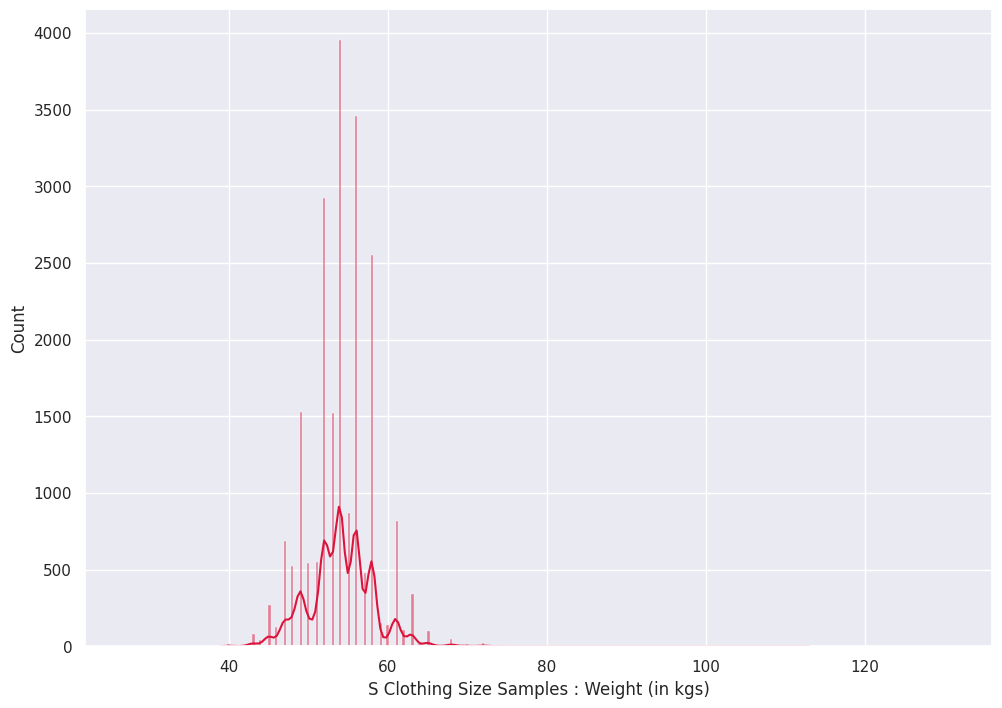

In [ ]:
count_plotted = sns.histplot(x = 'weight', data = df.loc[df['size'] == 2], kde = True, color = 'crimson')
count_plotted.set(xlabel = "S Clothing Size Samples : Weight (in kgs)")
count_plotted.set(xlim = (22.0000, 136.0000))

[Text(0.5, 0, 'S Clothing Size Samples : Weight (in kgs)')]

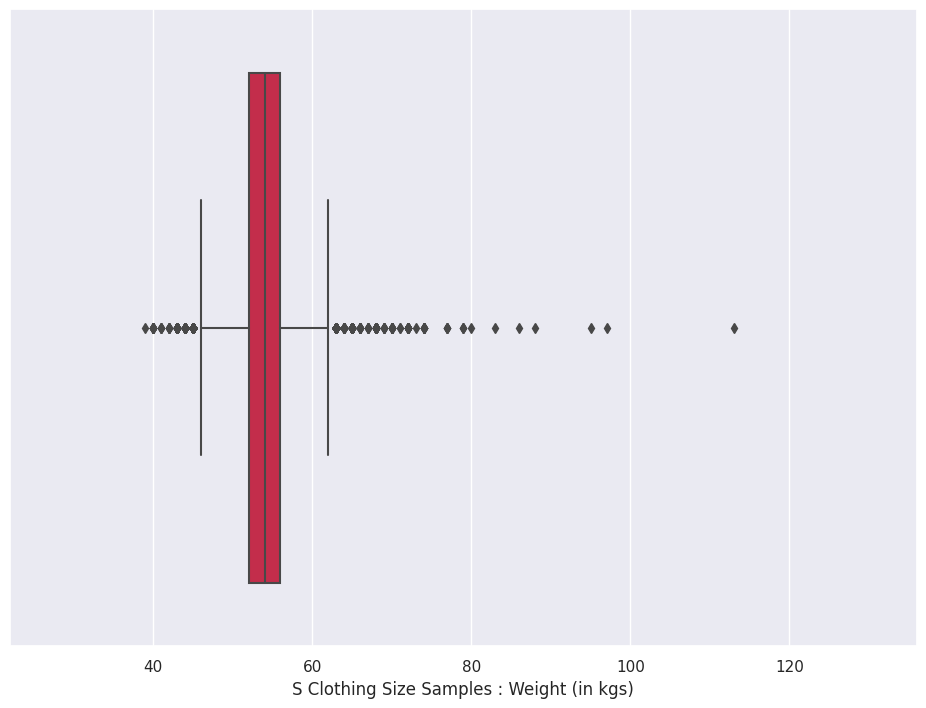

In [ ]:
boxxer_plot = sns.boxplot(x = 'weight', data = df.loc[df['size'] == 2], color = 'crimson')
boxxer_plot.set(xlim = (22.0000, 136.0000))
boxxer_plot.set(xlabel = "S Clothing Size Samples : Weight (in kgs)")

In [ ]:
numpy_array = np.array(df.loc[df['size'] == 2]['weight'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 46.0000 or greater than 62.0000
There are 1000 outliers.


[(0.0, 117.0)]

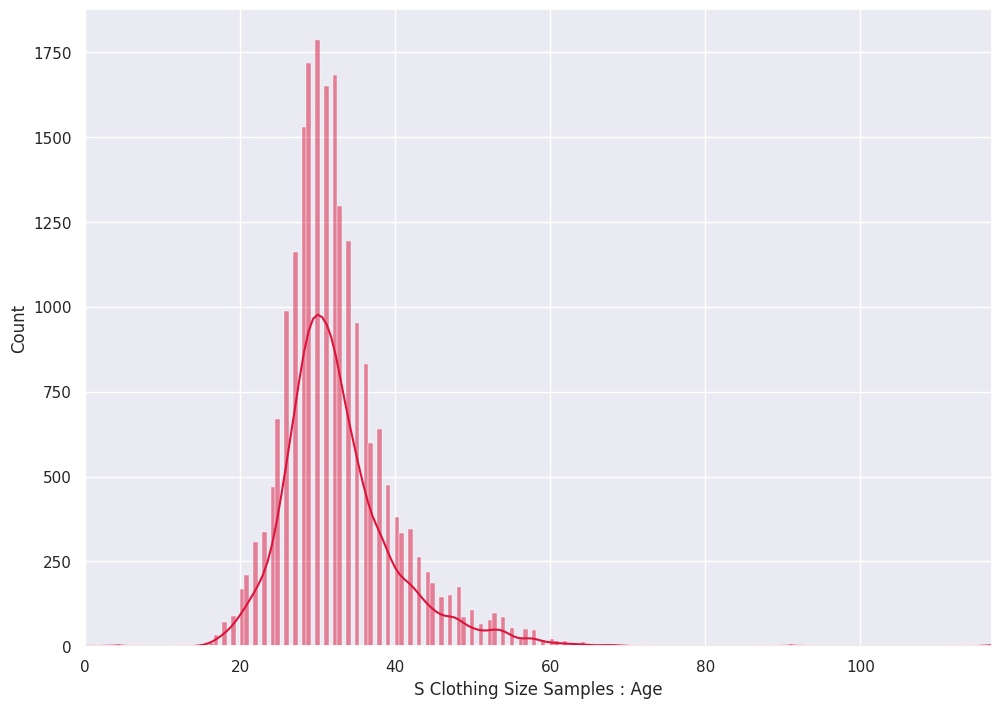

In [ ]:
count_plotted = sns.histplot(x = 'age', data = df.loc[df['size'] == 2], kde = True, color = 'crimson')
count_plotted.set(xlabel = "S Clothing Size Samples : Age")
count_plotted.set(xlim = (0.0000, 117.0000))

[Text(0.5, 0, 'S Clothing Size Samples : Age')]

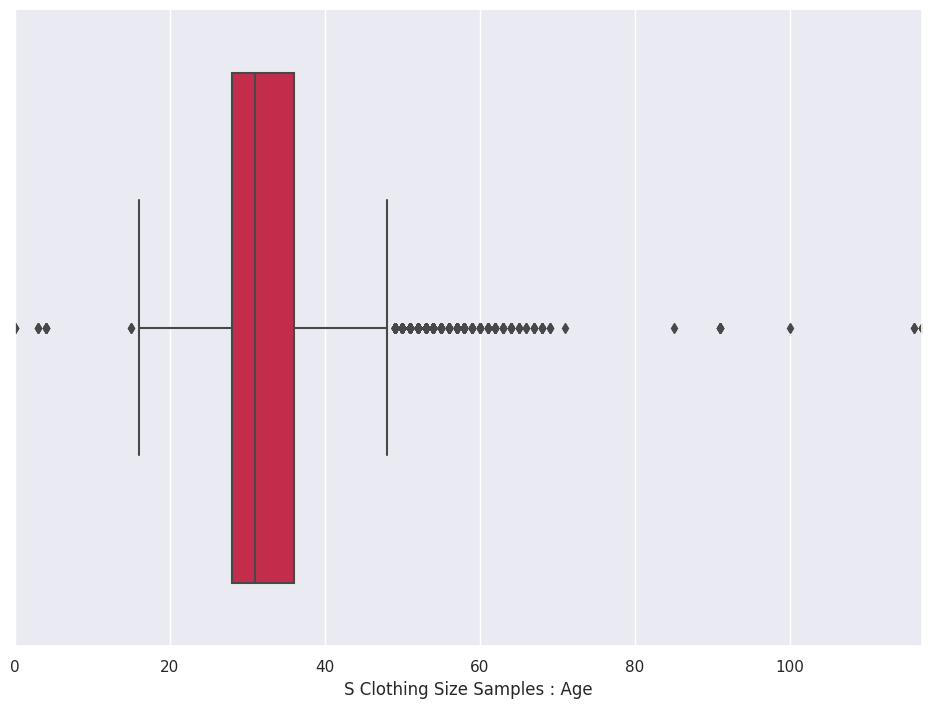

In [ ]:
boxxer_plot = sns.boxplot(x = 'age', data = df.loc[df['size'] == 2], color = 'crimson')
boxxer_plot.set(xlim = (0.0000, 117.0000))
boxxer_plot.set(xlabel = "S Clothing Size Samples : Age")

In [ ]:
numpy_array = np.array(df.loc[df['size'] == 2]['age'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 16.0000 or greater than 48.0000
There are 847 outliers.


[(137.16, 193.04)]

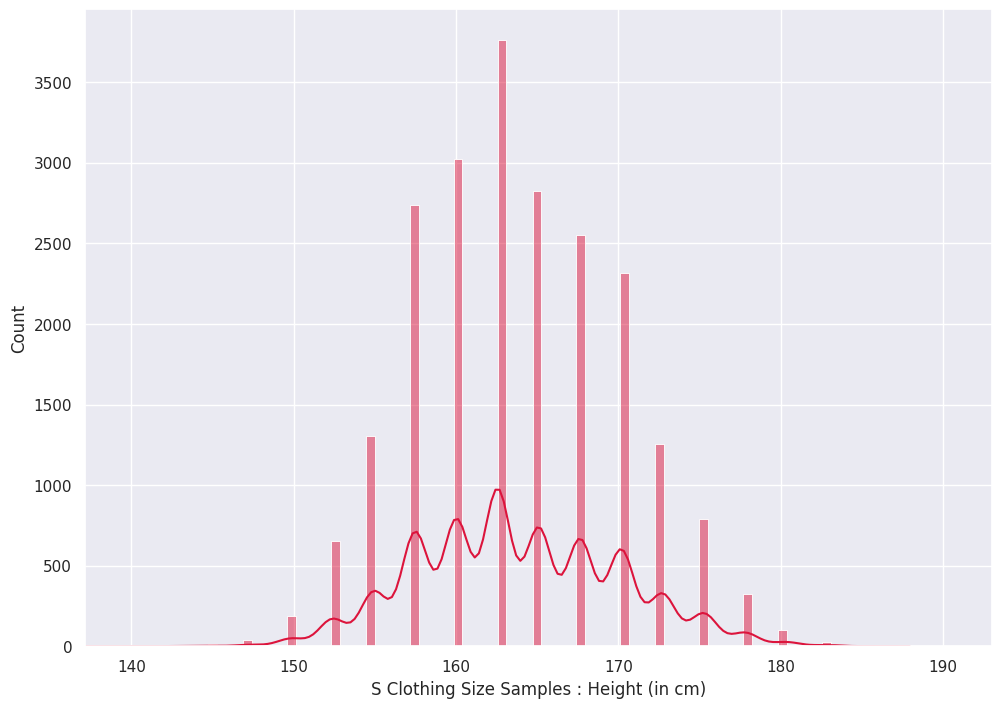

In [ ]:
count_plotted = sns.histplot(x = 'height', data = df.loc[df['size'] == 2], kde = True, color = 'crimson')
count_plotted.set(xlabel = "S Clothing Size Samples : Height (in cm)")
count_plotted.set(xlim = (137.1600, 193.0400))

[Text(0.5, 0, 'S Clothing Size Samples : Height (in cm)')]

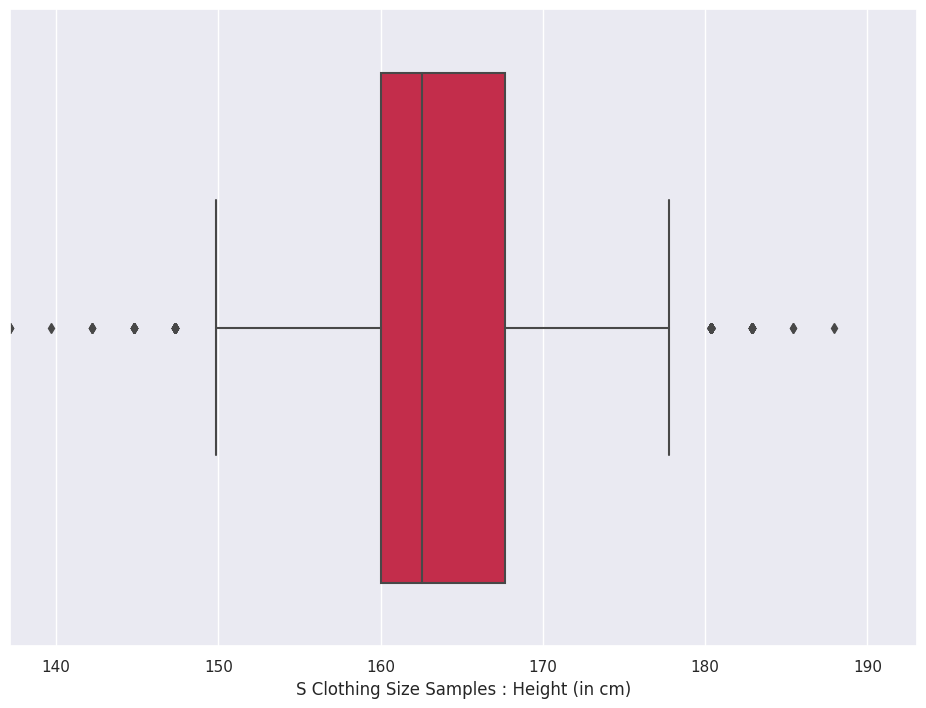

In [ ]:
boxxer_plot = sns.boxplot(x = 'height', data = df.loc[df['size'] == 2], color = 'crimson')
boxxer_plot.set(xlim = (137.1600, 193.0400))
boxxer_plot.set(xlabel = "S Clothing Size Samples : Height (in cm)")

In [ ]:
numpy_array = np.array(df.loc[df['size'] == 2]['height'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 148.5900 or greater than 179.0700
There are 189 outliers.


[(1.0, 7.0)]

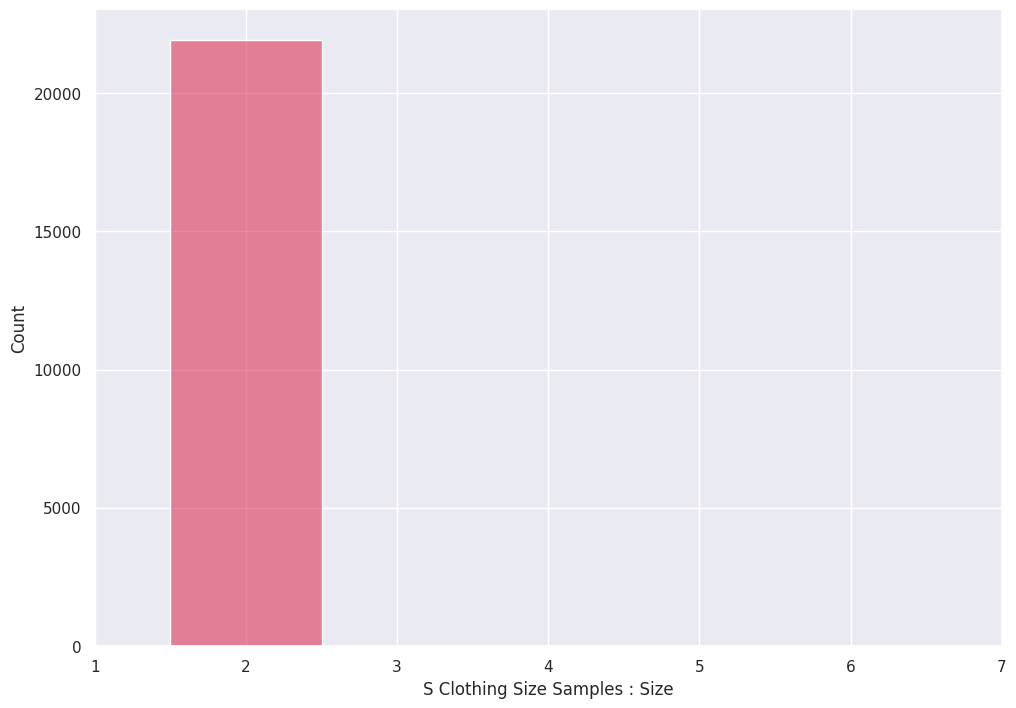

In [ ]:
count_plotted = sns.histplot(x = 'size', data = df.loc[df['size'] == 2], kde = True, color = 'crimson')
count_plotted.set(xlabel = "S Clothing Size Samples : Size")
count_plotted.set(xlim = (1.0000, 7.0000))

[Text(0.5, 0, 'S Clothing Size Samples : Size')]

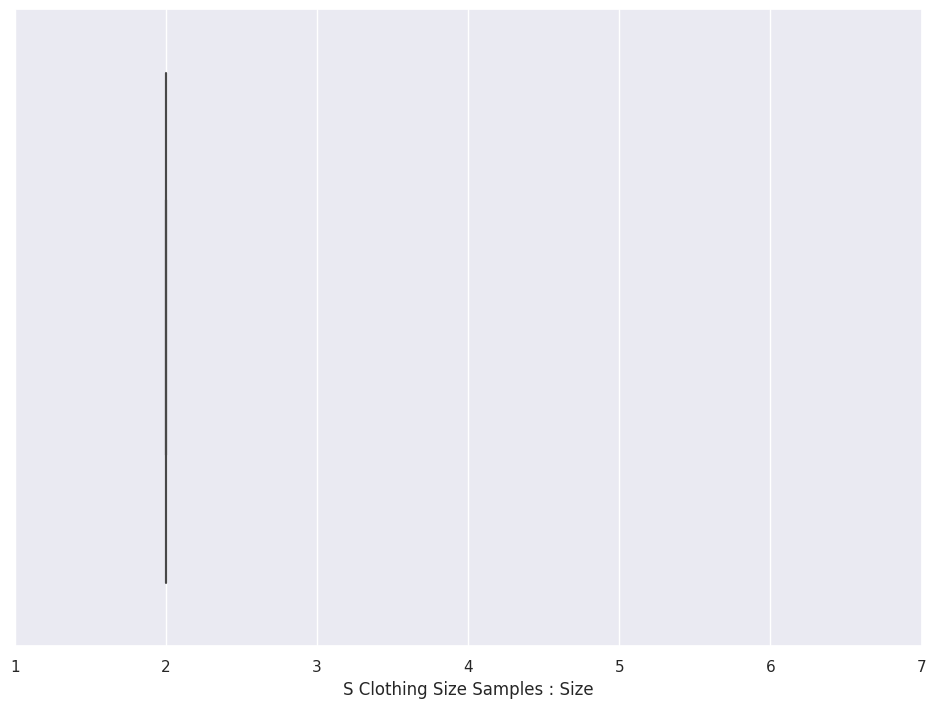

In [ ]:
boxxer_plot = sns.boxplot(x = 'size', data = df.loc[df['size'] == 2], color = 'crimson')
boxxer_plot.set(xlim = (1.0000, 7.0000))
boxxer_plot.set(xlabel = "S Clothing Size Samples : Size")

In [ ]:
numpy_array = np.array(df.loc[df['size'] == 2]['size'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 2.0000 or greater than 2.0000
There are 0 outliers.


[(7.8283, 54.3236)]

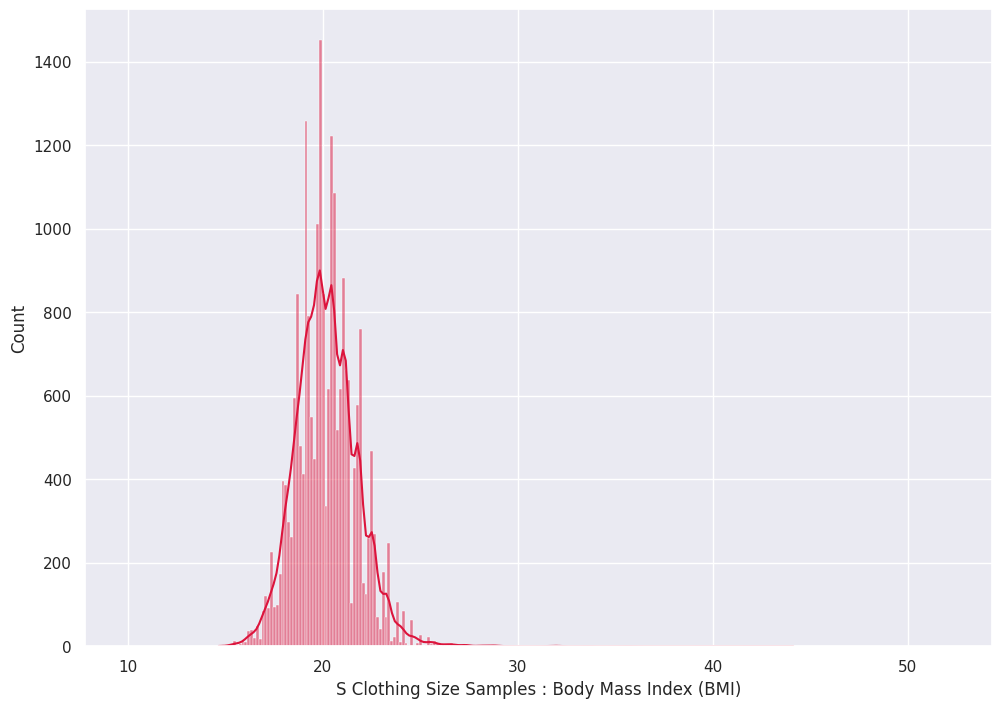

In [ ]:
count_plotted = sns.histplot(x = 'bmi', data = df.loc[df['size'] == 2], kde = True, color = 'crimson')
count_plotted.set(xlabel = "S Clothing Size Samples : Body Mass Index (BMI)")
count_plotted.set(xlim = (7.8283, 54.3236))

[Text(0.5, 0, 'S Clothing Size Samples : Body Mass Index (BMI)')]

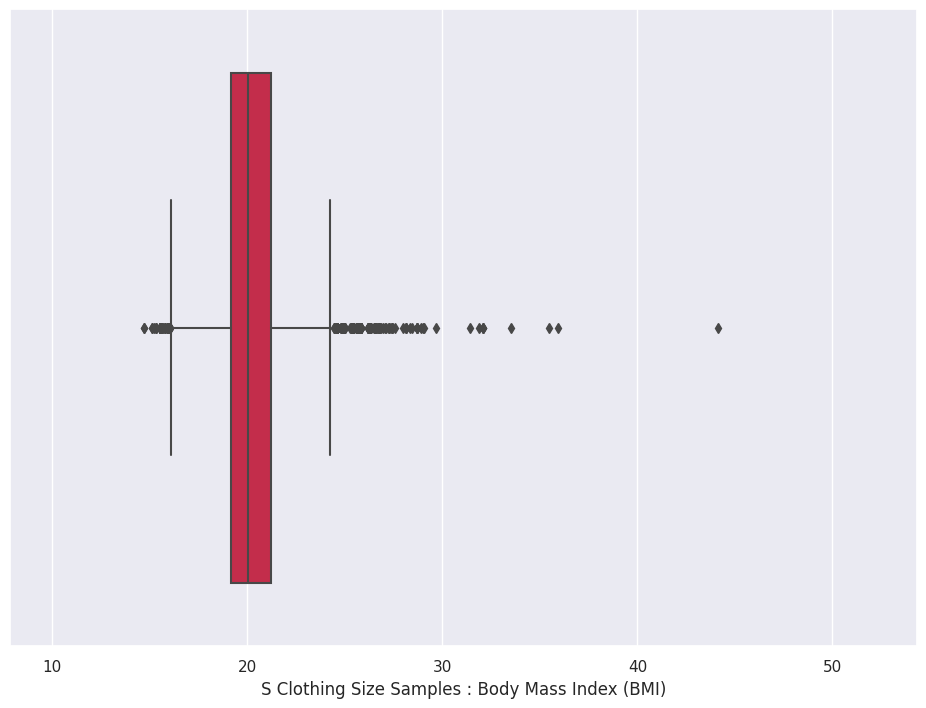

In [ ]:
boxxer_plot = sns.boxplot(x = 'bmi', data = df.loc[df['size'] == 2], color = 'crimson')
boxxer_plot.set(xlim = (7.8283, 54.3236))
boxxer_plot.set(xlabel = "S Clothing Size Samples : Body Mass Index (BMI)")

In [ ]:
numpy_array = np.array(df.loc[df['size'] == 2]['bmi'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 16.0524 or greater than 24.2749
There are 265 outliers.


# **M**

[(22.0, 136.0)]

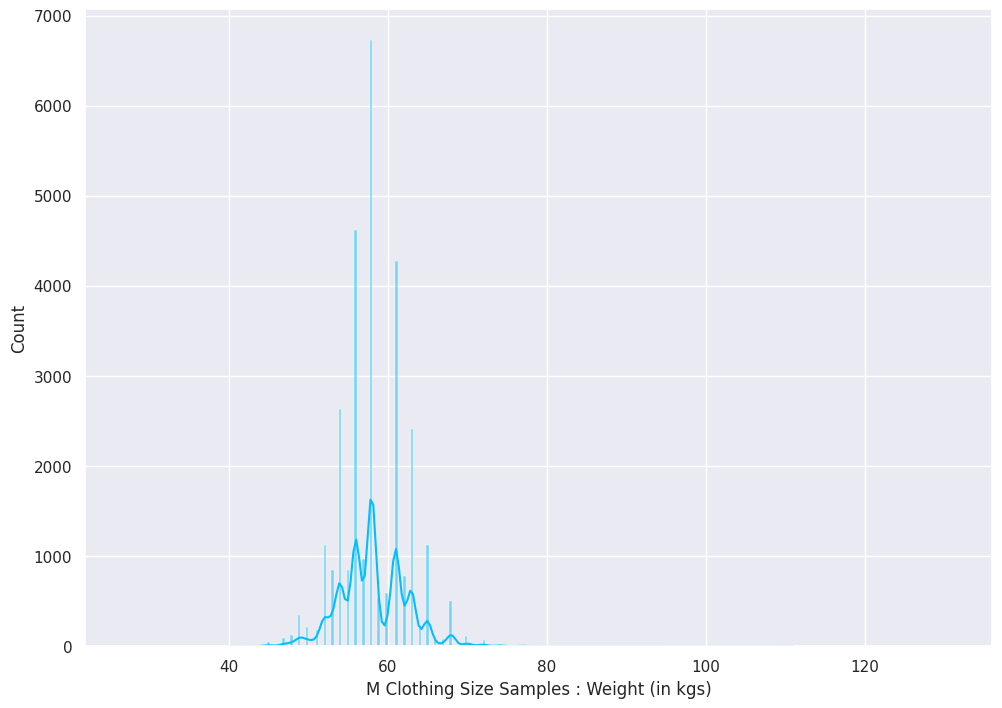

In [ ]:
count_plotted = sns.histplot(x = 'weight', data = df.loc[df['size'] == 3], kde = True, color = 'deepskyblue')
count_plotted.set(xlabel = "M Clothing Size Samples : Weight (in kgs)")
count_plotted.set(xlim = (22.0000, 136.0000))

[Text(0.5, 0, 'M Clothing Size Samples : Weight (in kgs)')]

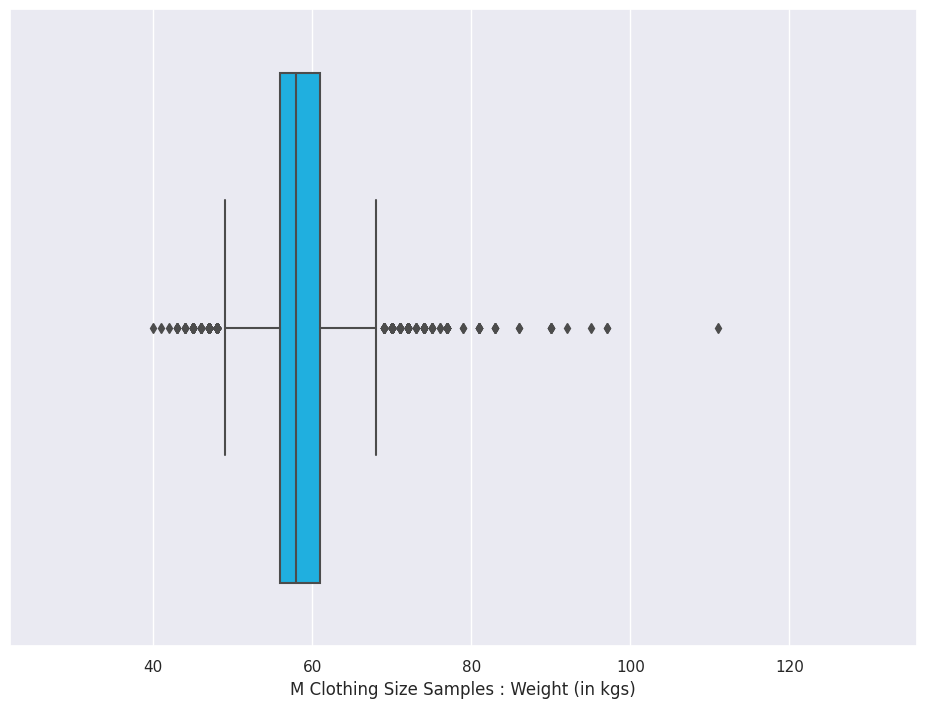

In [ ]:
boxxer_plot = sns.boxplot(x = 'weight', data = df.loc[df['size'] == 3], color = 'deepskyblue')
boxxer_plot.set(xlim = (22.0000, 136.0000))
boxxer_plot.set(xlabel = "M Clothing Size Samples : Weight (in kgs)")

In [ ]:
numpy_array = np.array(df.loc[df['size'] == 3]['weight'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 48.5000 or greater than 68.5000
There are 580 outliers.


[(0.0, 117.0)]

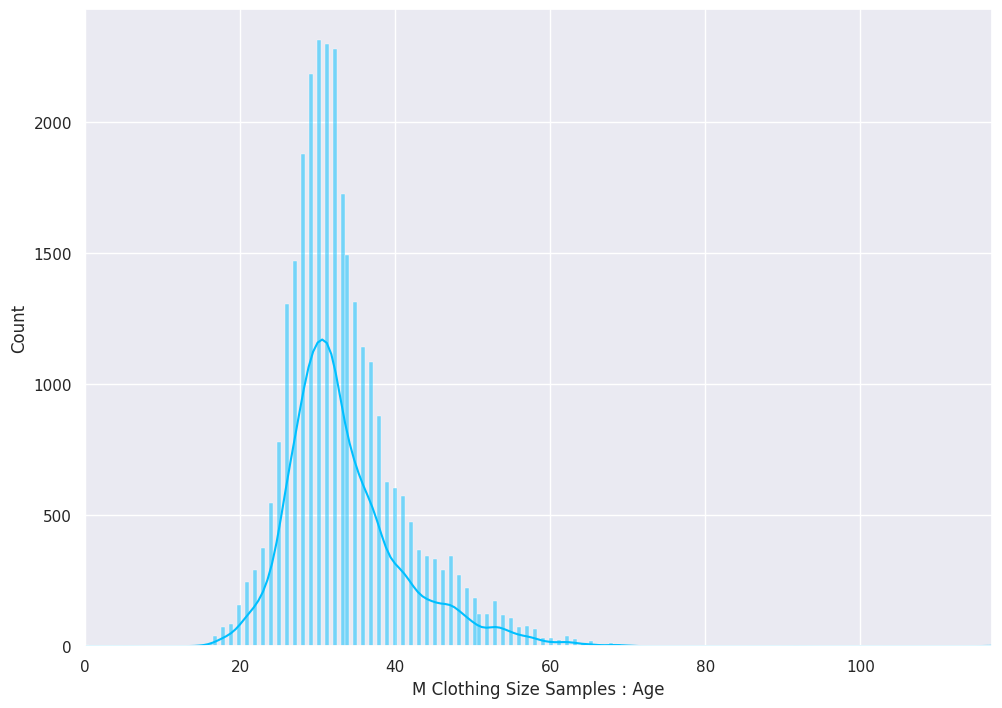

In [ ]:
count_plotted = sns.histplot(x = 'age', data = df.loc[df['size'] == 3], kde = True, color = 'deepskyblue')
count_plotted.set(xlabel = "M Clothing Size Samples : Age")
count_plotted.set(xlim = (0.0000, 117.0000))

[Text(0.5, 0, 'M Clothing Size Samples : Age')]

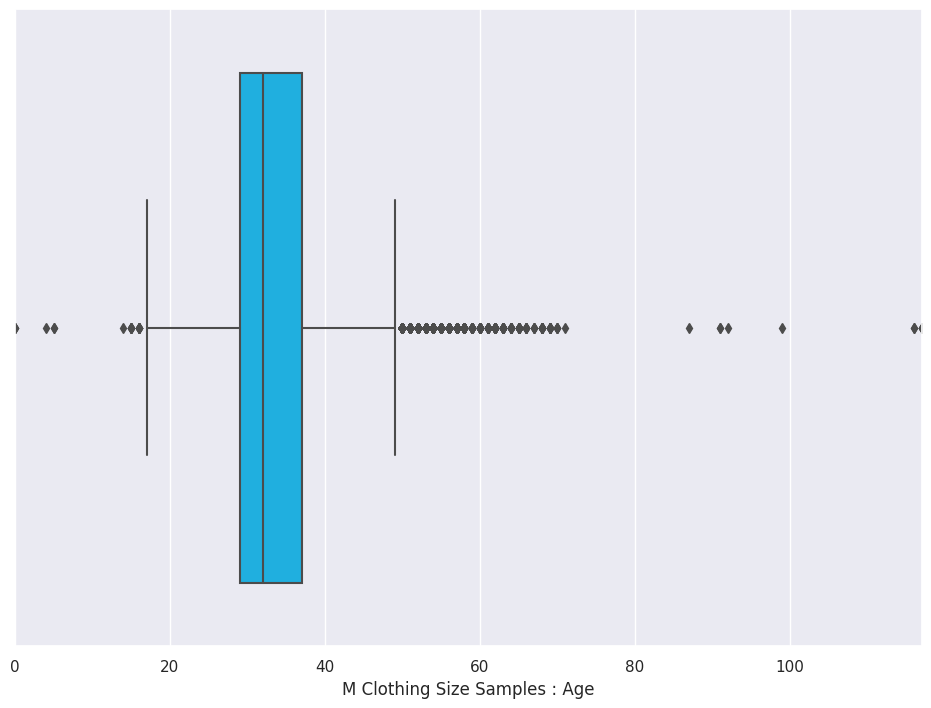

In [ ]:
boxxer_plot = sns.boxplot(x = 'age', data = df.loc[df['size'] == 3], color = 'deepskyblue')
boxxer_plot.set(xlim = (0.0000, 117.0000))
boxxer_plot.set(xlabel = "M Clothing Size Samples : Age")

In [ ]:
numpy_array = np.array(df.loc[df['size'] == 3]['age'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 17.0000 or greater than 49.0000
There are 1304 outliers.


[(137.16, 193.04)]

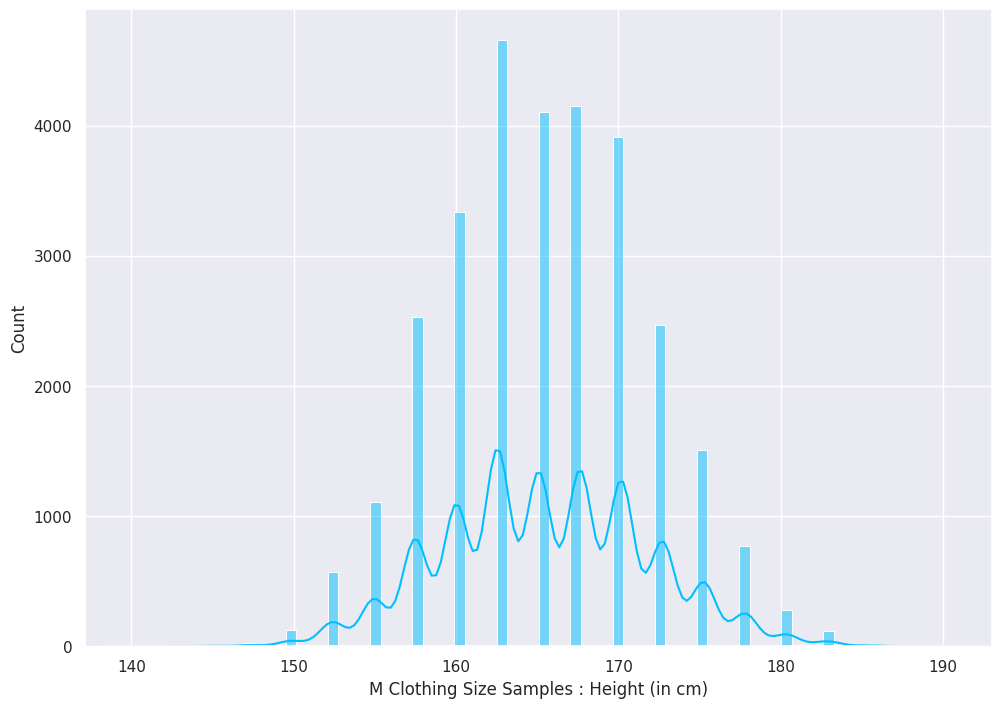

In [ ]:
count_plotted = sns.histplot(x = 'height', data = df.loc[df['size'] == 3], kde = True, color = 'deepskyblue')
count_plotted.set(xlabel = "M Clothing Size Samples : Height (in cm)")
count_plotted.set(xlim = (137.1600, 193.0400))

[Text(0.5, 0, 'M Clothing Size Samples : Height (in cm)')]

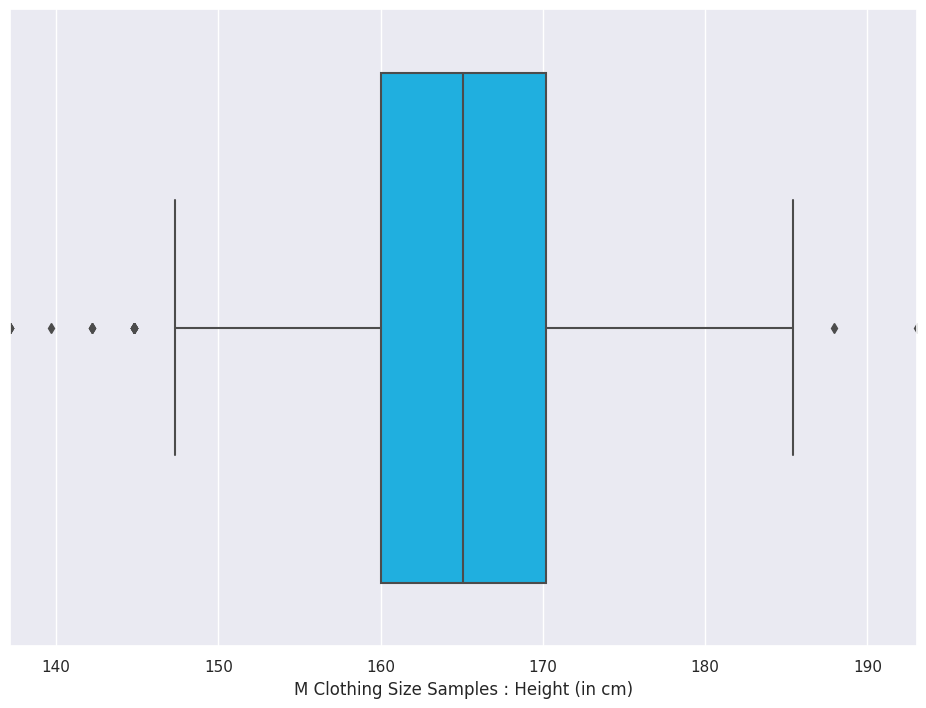

In [ ]:
boxxer_plot = sns.boxplot(x = 'height', data = df.loc[df['size'] == 3], color = 'deepskyblue')
boxxer_plot.set(xlim = (137.1600, 193.0400))
boxxer_plot.set(xlabel = "M Clothing Size Samples : Height (in cm)")

In [ ]:
numpy_array = np.array(df.loc[df['size'] == 3]['height'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 144.7800 or greater than 185.4200
There are 22 outliers.


[(1.0, 7.0)]

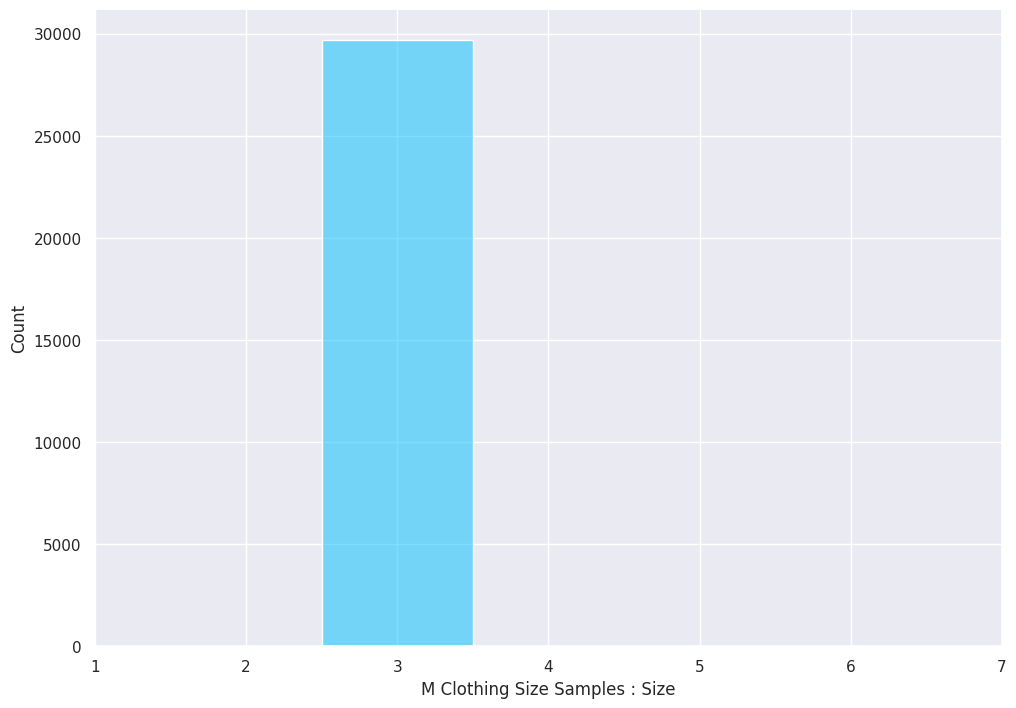

In [ ]:
count_plotted = sns.histplot(x = 'size', data = df.loc[df['size'] == 3], kde = True, color = 'deepskyblue')
count_plotted.set(xlabel = "M Clothing Size Samples : Size")
count_plotted.set(xlim = (1.0000, 7.0000))

[Text(0.5, 0, 'M Clothing Size Samples : Size')]

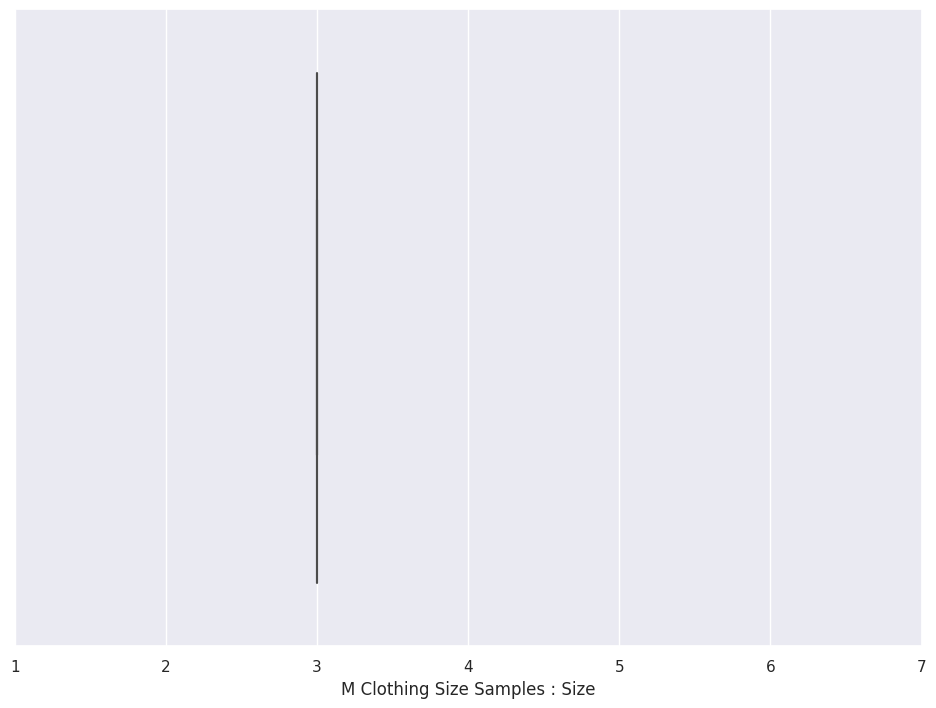

In [ ]:
boxxer_plot = sns.boxplot(x = 'size', data = df.loc[df['size'] == 3], color = 'deepskyblue')
boxxer_plot.set(xlim = (1.0000, 7.0000))
boxxer_plot.set(xlabel = "M Clothing Size Samples : Size")

In [ ]:
numpy_array = np.array(df.loc[df['size'] == 3]['size'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 3.0000 or greater than 3.0000
There are 0 outliers.


[(7.8283, 54.3236)]

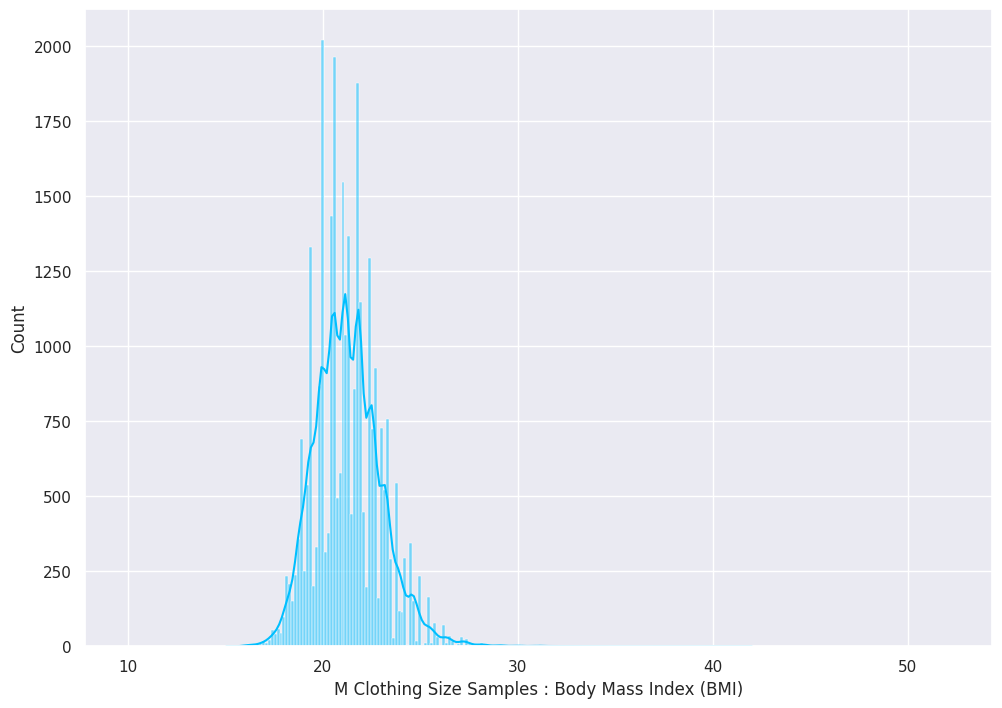

In [ ]:
count_plotted = sns.histplot(x = 'bmi', data = df.loc[df['size'] == 3], kde = True, color = 'deepskyblue')
count_plotted.set(xlabel = "M Clothing Size Samples : Body Mass Index (BMI)")
count_plotted.set(xlim = (7.8283, 54.3236))

[Text(0.5, 0, 'M Clothing Size Samples : Body Mass Index (BMI)')]

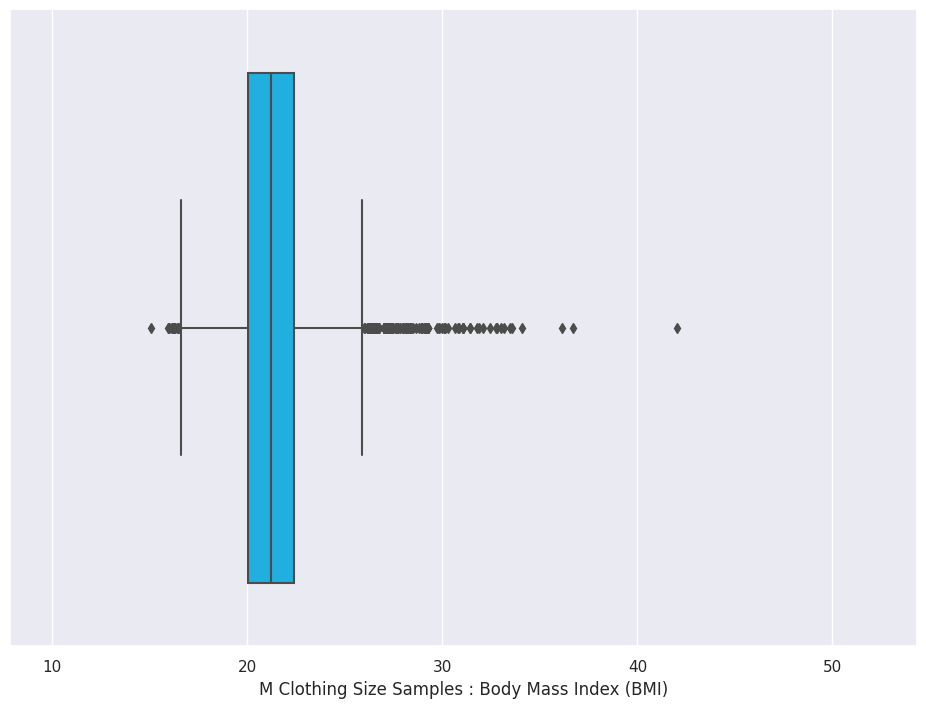

In [ ]:
boxxer_plot = sns.boxplot(x = 'bmi', data = df.loc[df['size'] == 3], color = 'deepskyblue')
boxxer_plot.set(xlim = (7.8283, 54.3236))
boxxer_plot.set(xlabel = "M Clothing Size Samples : Body Mass Index (BMI)")

In [ ]:
numpy_array = np.array(df.loc[df['size'] == 3]['bmi'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 16.4988 or greater than 25.9067
There are 305 outliers.


# **L**

[(22.0, 136.0)]

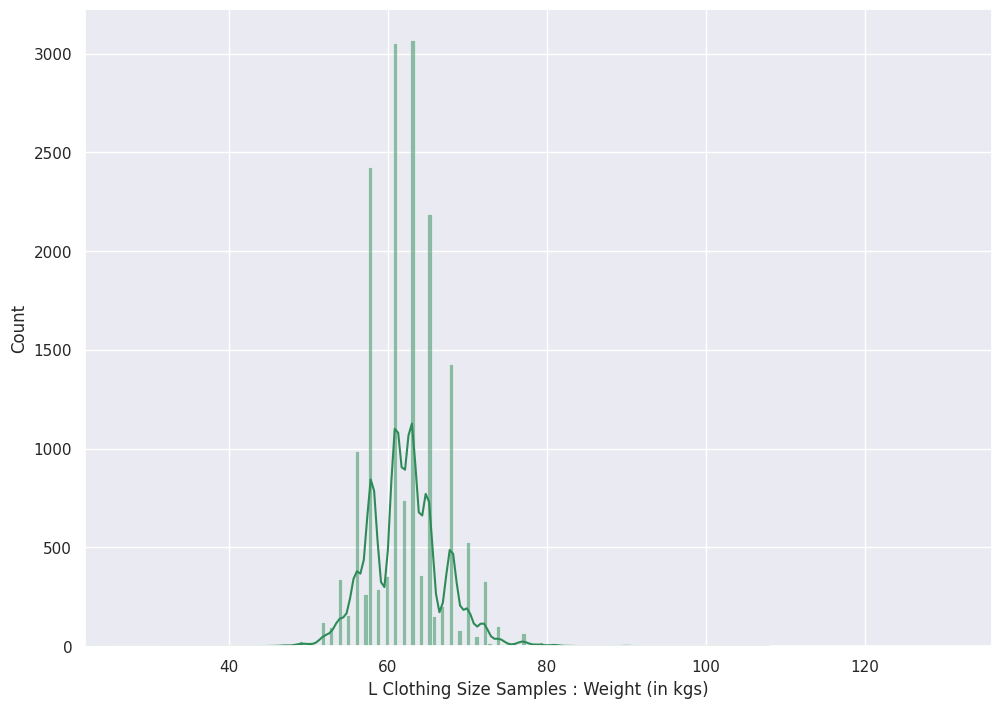

In [ ]:
count_plotted = sns.histplot(x = 'weight', data = df.loc[df['size'] == 4], kde = True, color = 'seagreen')
count_plotted.set(xlabel = "L Clothing Size Samples : Weight (in kgs)")
count_plotted.set(xlim = (22.0000, 136.0000))

[Text(0.5, 0, 'L Clothing Size Samples : Weight (in kgs)')]

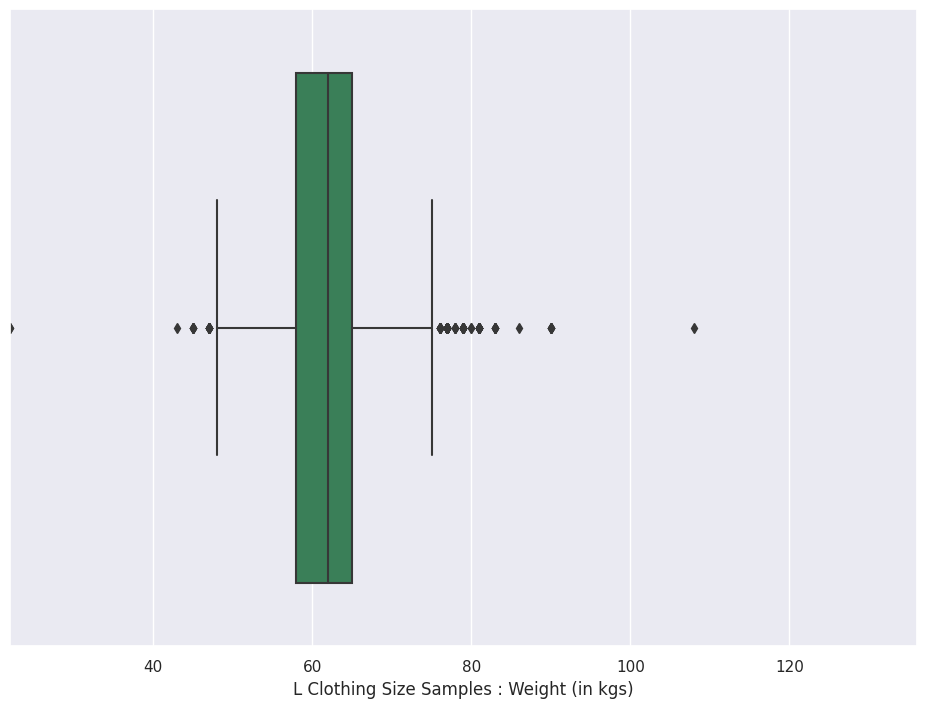

In [ ]:
boxxer_plot = sns.boxplot(x = 'weight', data = df.loc[df['size'] == 4], color = 'seagreen')
boxxer_plot.set(xlim = (22.0000, 136.0000))
boxxer_plot.set(xlabel = "L Clothing Size Samples : Weight (in kgs)")

In [ ]:
numpy_array = np.array(df.loc[df['size'] == 4]['weight'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 47.5000 or greater than 75.5000
There are 162 outliers.


[(0.0, 117.0)]

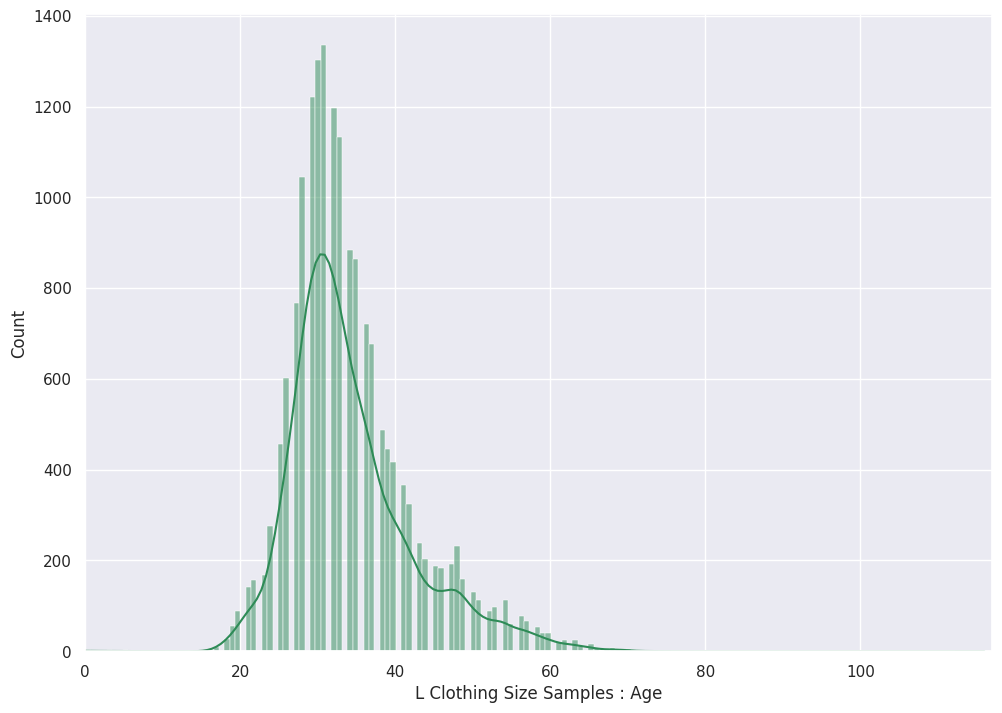

In [ ]:
count_plotted = sns.histplot(x = 'age', data = df.loc[df['size'] == 4], kde = True, color = 'seagreen')
count_plotted.set(xlabel = "L Clothing Size Samples : Age")
count_plotted.set(xlim = (0.0000, 117.0000))

[Text(0.5, 0, 'L Clothing Size Samples : Age')]

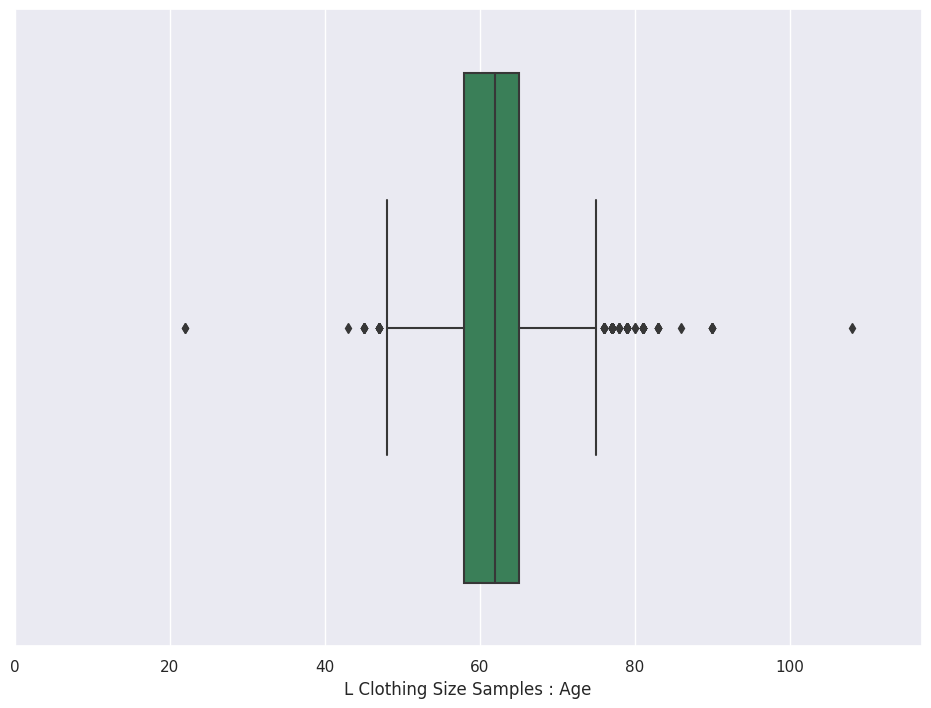

In [ ]:
boxxer_plot = sns.boxplot(x = 'weight', data = df.loc[df['size'] == 4], color = 'seagreen')
boxxer_plot.set(xlim = (0.0000, 117.0000))
boxxer_plot.set(xlabel = "L Clothing Size Samples : Age")

In [ ]:
numpy_array = np.array(df.loc[df['size'] == 4]['age'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 15.5000 or greater than 51.5000
There are 775 outliers.


[(137.16, 193.04)]

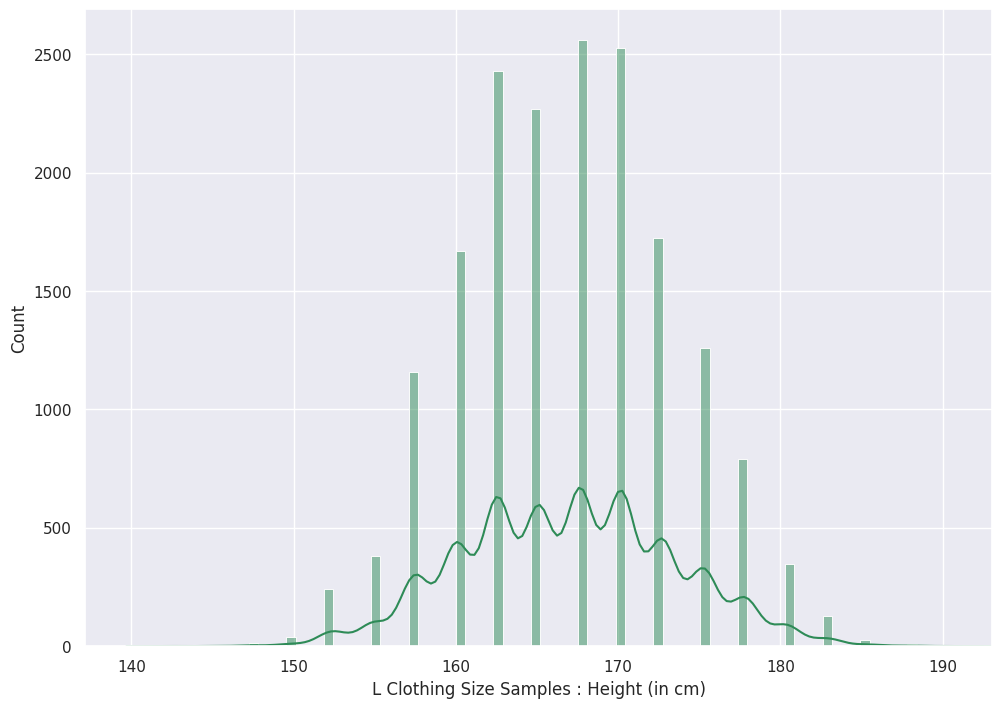

In [ ]:
count_plotted = sns.histplot(x = 'height', data = df.loc[df['size'] == 4], kde = True, color = 'seagreen')
count_plotted.set(xlabel = "L Clothing Size Samples : Height (in cm)")
count_plotted.set(xlim = (137.1600, 193.0400))

[Text(0.5, 0, 'L Clothing Size Samples : Height (in cm)')]

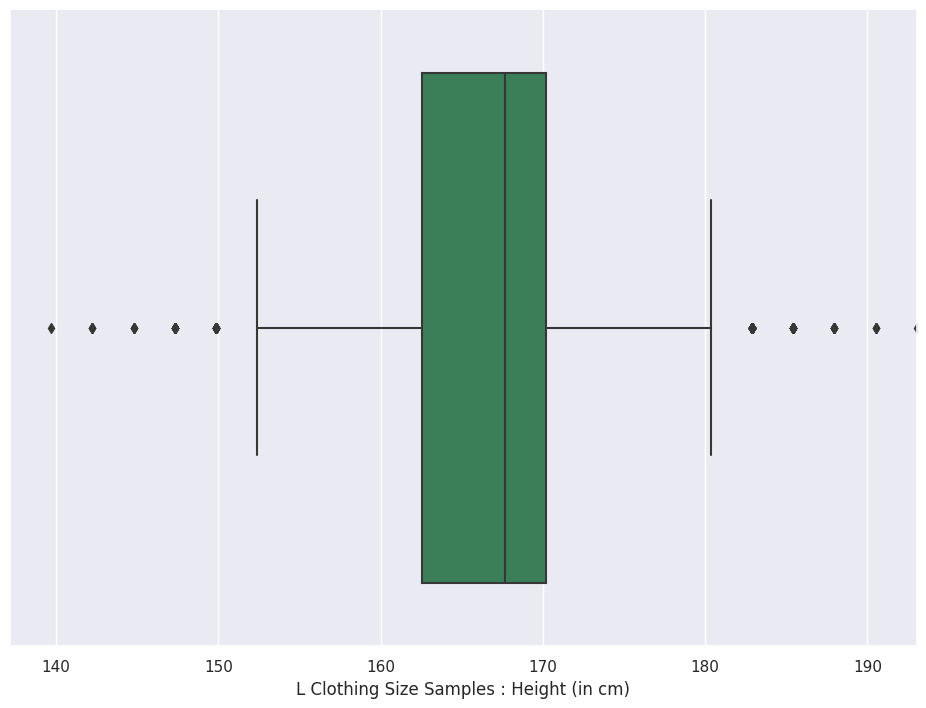

In [ ]:
boxxer_plot = sns.boxplot(x = 'height', data = df.loc[df['size'] == 4], color = 'seagreen')
boxxer_plot.set(xlim = (137.1600, 193.0400))
boxxer_plot.set(xlabel = "L Clothing Size Samples : Height (in cm)")

In [ ]:
numpy_array = np.array(df.loc[df['size'] == 4]['height'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 151.1300 or greater than 181.6100
There are 231 outliers.


[(1.0, 7.0)]

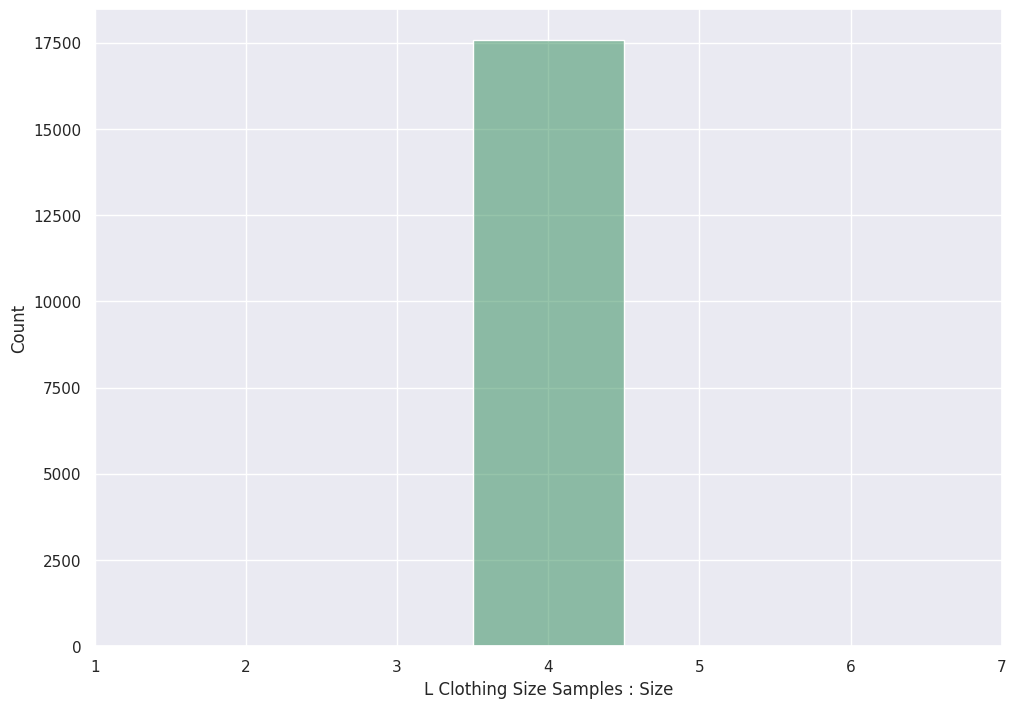

In [ ]:
count_plotted = sns.histplot(x = 'size', data = df.loc[df['size'] == 4], kde = True, color = 'seagreen')
count_plotted.set(xlabel = "L Clothing Size Samples : Size")
count_plotted.set(xlim = (1.0000, 7.0000))

[Text(0.5, 0, 'L Clothing Size Samples : Size')]

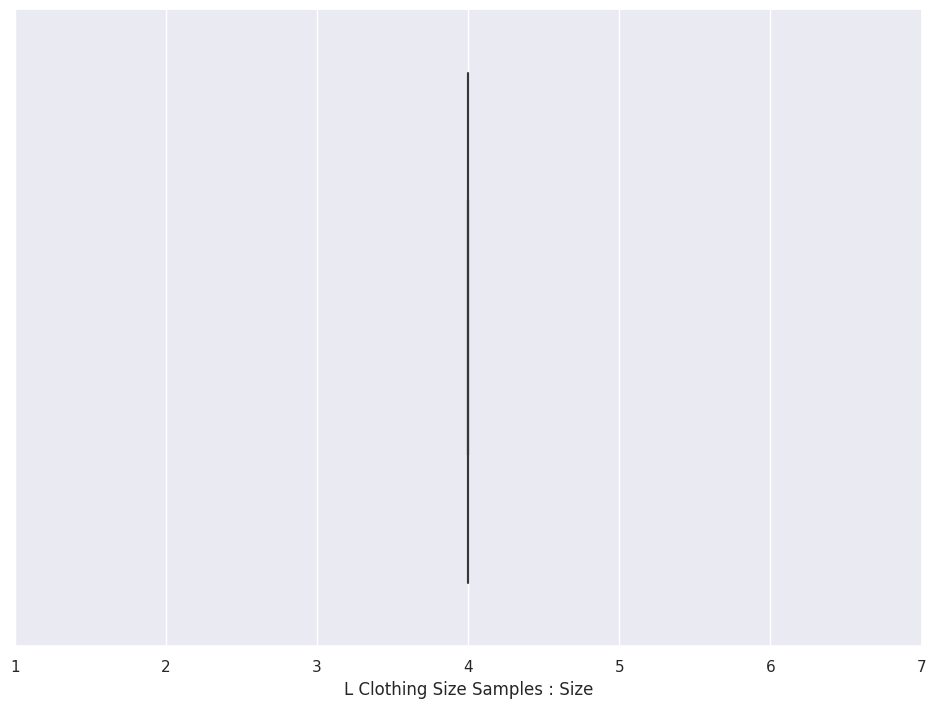

In [ ]:
boxxer_plot = sns.boxplot(x = 'size', data = df.loc[df['size'] == 4], color = 'seagreen')
boxxer_plot.set(xlim = (1.0000, 7.0000))
boxxer_plot.set(xlabel = "L Clothing Size Samples : Size")

In [ ]:
numpy_array = np.array(df.loc[df['size'] == 4]['size'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 4.0000 or greater than 4.0000
There are 0 outliers.


[(7.8283, 54.3236)]

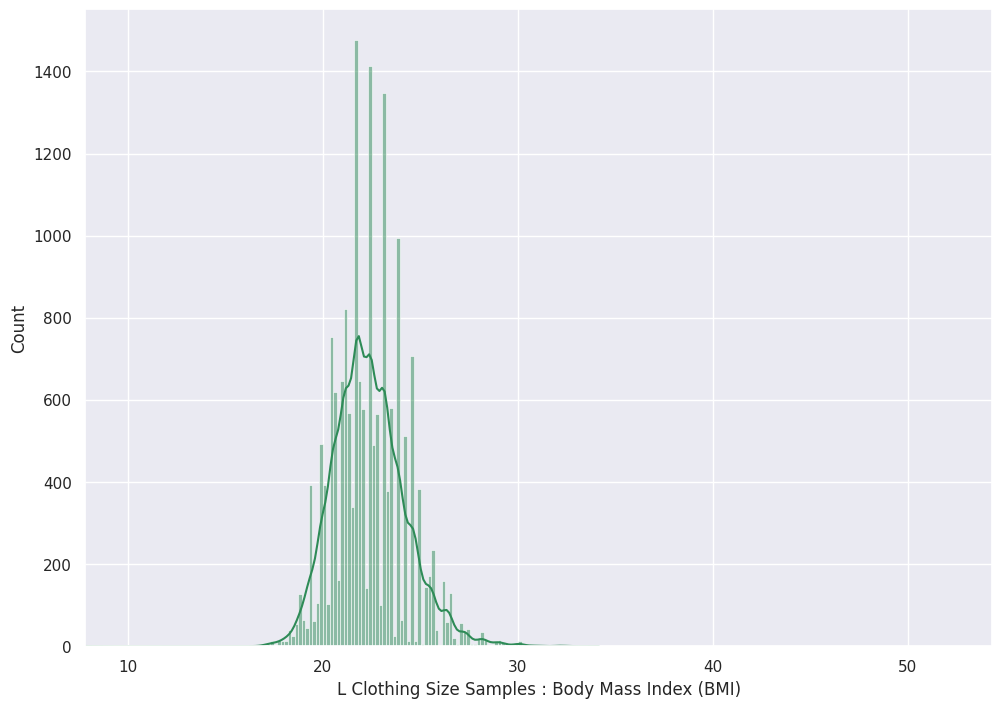

In [ ]:
count_plotted = sns.histplot(x = 'bmi', data = df.loc[df['size'] == 4], kde = True, color = 'seagreen')
count_plotted.set(xlabel = "L Clothing Size Samples : Body Mass Index (BMI)")
count_plotted.set(xlim = (7.8283, 54.3236))

[Text(0.5, 0, 'L Clothing Size Samples : Body Mass Index (BMI)')]

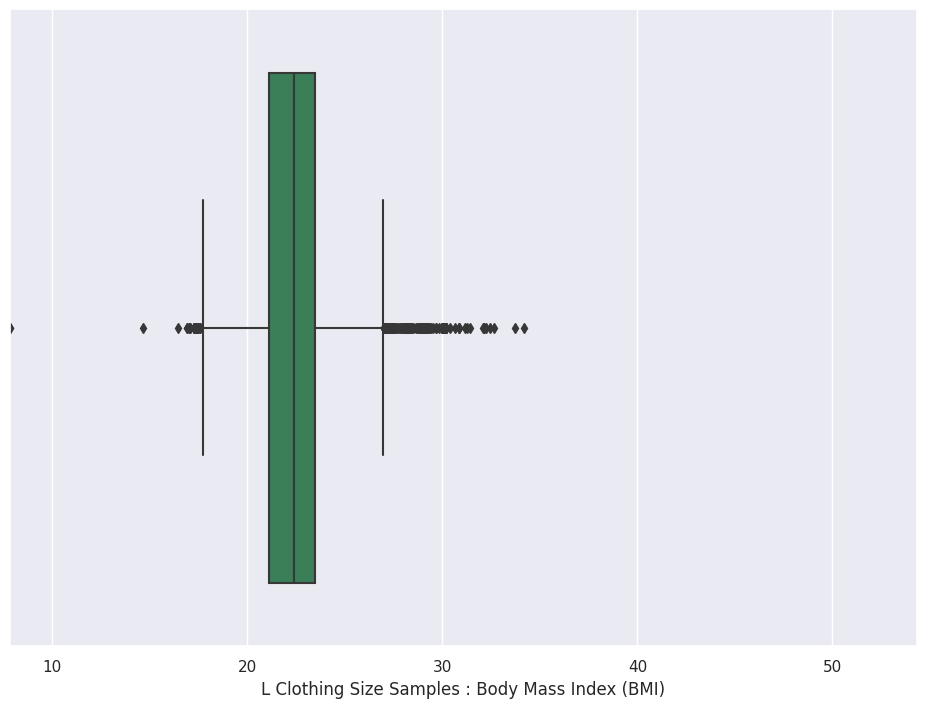

In [ ]:
boxxer_plot = sns.boxplot(x = 'bmi', data = df.loc[df['size'] == 4], color = 'seagreen')
boxxer_plot.set(xlim = (7.8283, 54.3236))
boxxer_plot.set(xlabel = "L Clothing Size Samples : Body Mass Index (BMI)")

In [ ]:
numpy_array = np.array(df.loc[df['size'] == 4]['bmi'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 17.6024 or greater than 26.9777
There are 325 outliers.


# **XL**

[(22.0, 136.0)]

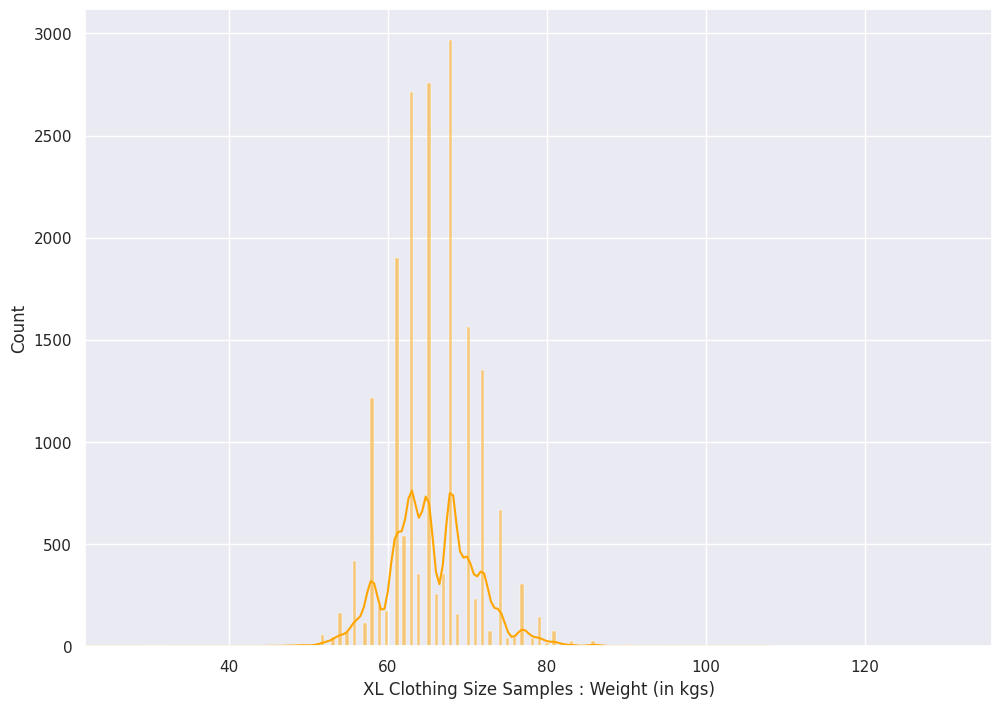

In [ ]:
count_plotted = sns.histplot(x = 'weight', data = df.loc[df['size'] == 5], kde = True, color = 'orange')
count_plotted.set(xlabel = "XL Clothing Size Samples : Weight (in kgs)")
count_plotted.set(xlim = (22.0000, 136.0000))

[Text(0.5, 0, 'XL Clothing Size Samples : Weight (in kgs)')]

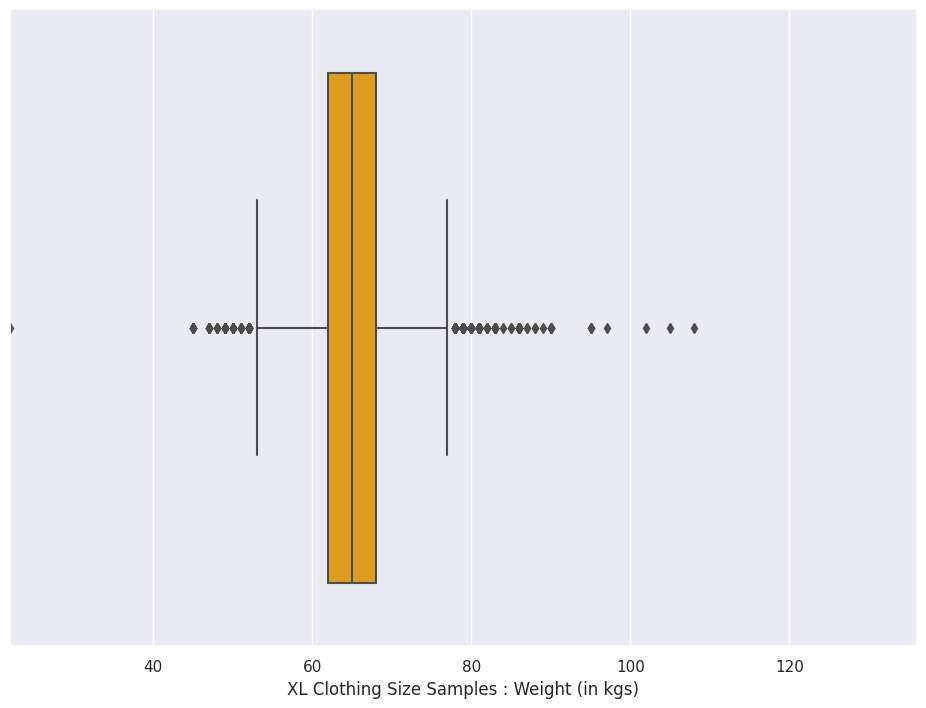

In [ ]:
boxxer_plot = sns.boxplot(x = 'weight', data = df.loc[df['size'] == 5], color = 'orange')
boxxer_plot.set(xlim = (22.0000, 136.0000))
boxxer_plot.set(xlabel = "XL Clothing Size Samples : Weight (in kgs)")

In [ ]:
numpy_array = np.array(df.loc[df['size'] == 5]['weight'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 53.0000 or greater than 77.0000
There are 447 outliers.


[(0.0, 117.0)]

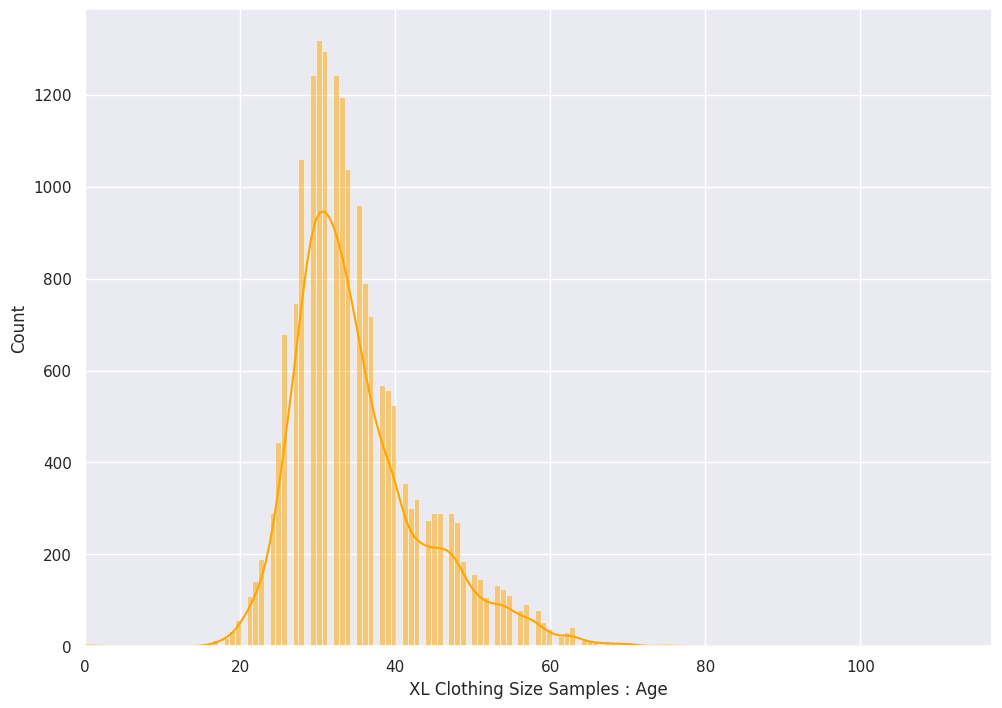

In [ ]:
count_plotted = sns.histplot(x = 'age', data = df.loc[df['size'] == 5], kde = True, color = 'orange')
count_plotted.set(xlabel = "XL Clothing Size Samples : Age")
count_plotted.set(xlim = (0.0000, 117.0000))

[Text(0.5, 0, 'XL Clothing Size Samples : Age')]

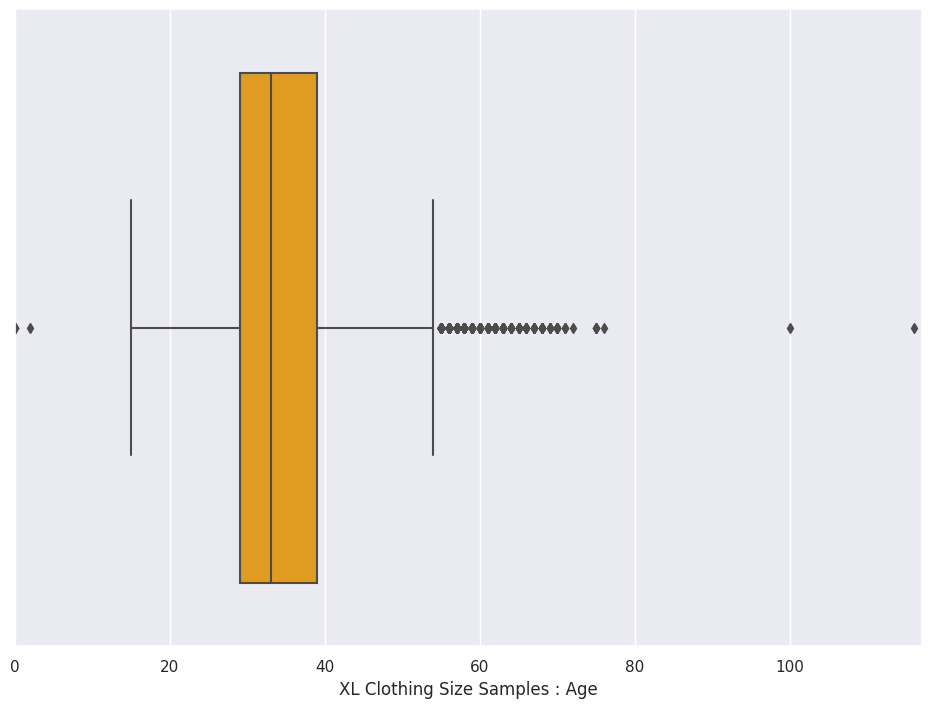

In [ ]:
boxxer_plot = sns.boxplot(x = 'age', data = df.loc[df['size'] == 5], color = 'orange')
boxxer_plot.set(xlim = (0.0000, 117.0000))
boxxer_plot.set(xlabel = "XL Clothing Size Samples : Age")

In [ ]:
numpy_array = np.array(df.loc[df['size'] == 5]['age'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 14.0000 or greater than 54.0000
There are 630 outliers.


[(137.16, 193.04)]

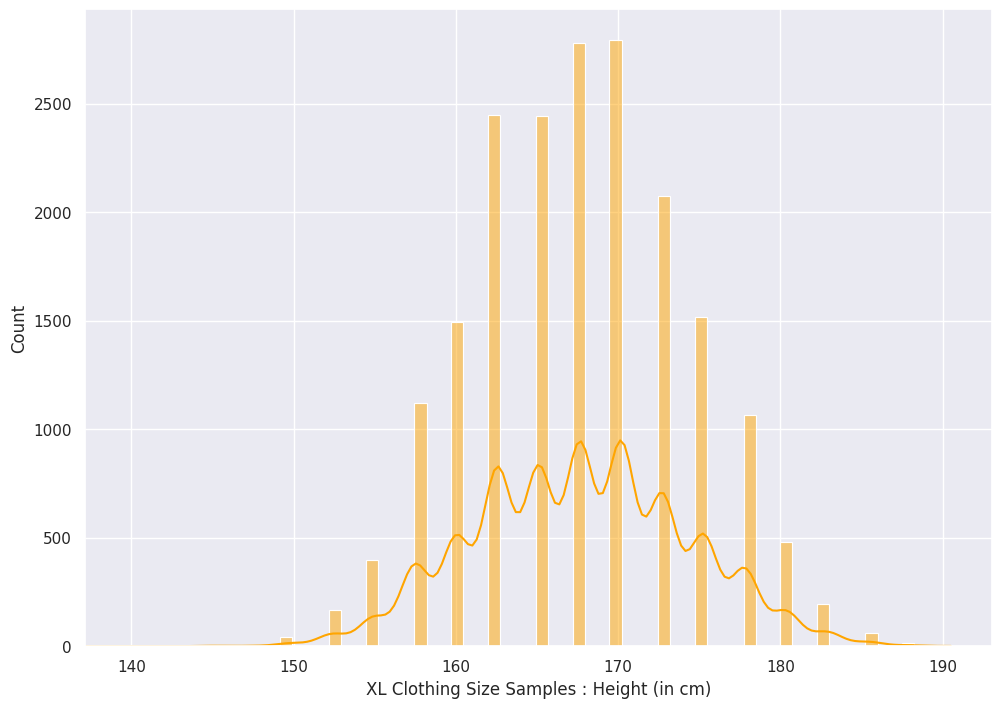

In [ ]:
count_plotted = sns.histplot(x = 'height', data = df.loc[df['size'] == 5], kde = True, color = 'orange')
count_plotted.set(xlabel = "XL Clothing Size Samples : Height (in cm)")
count_plotted.set(xlim = (137.1600, 193.0400))

[Text(0.5, 0, 'XL Clothing Size Samples : Height (in cm)')]

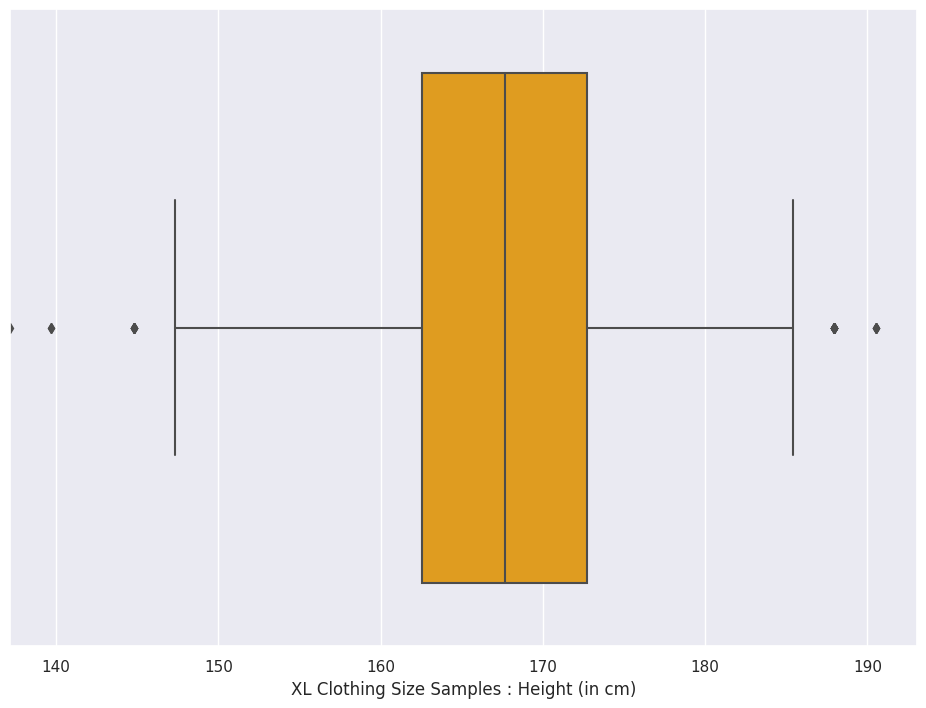

In [ ]:
boxxer_plot = sns.boxplot(x = 'height', data = df.loc[df['size'] == 5], color = 'orange')
boxxer_plot.set(xlim = (137.1600, 193.0400))
boxxer_plot.set(xlabel = "XL Clothing Size Samples : Height (in cm)")

In [ ]:
numpy_array = np.array(df.loc[df['size'] == 5]['height'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 147.3200 or greater than 187.9600
There are 28 outliers.


[(1.0, 7.0)]

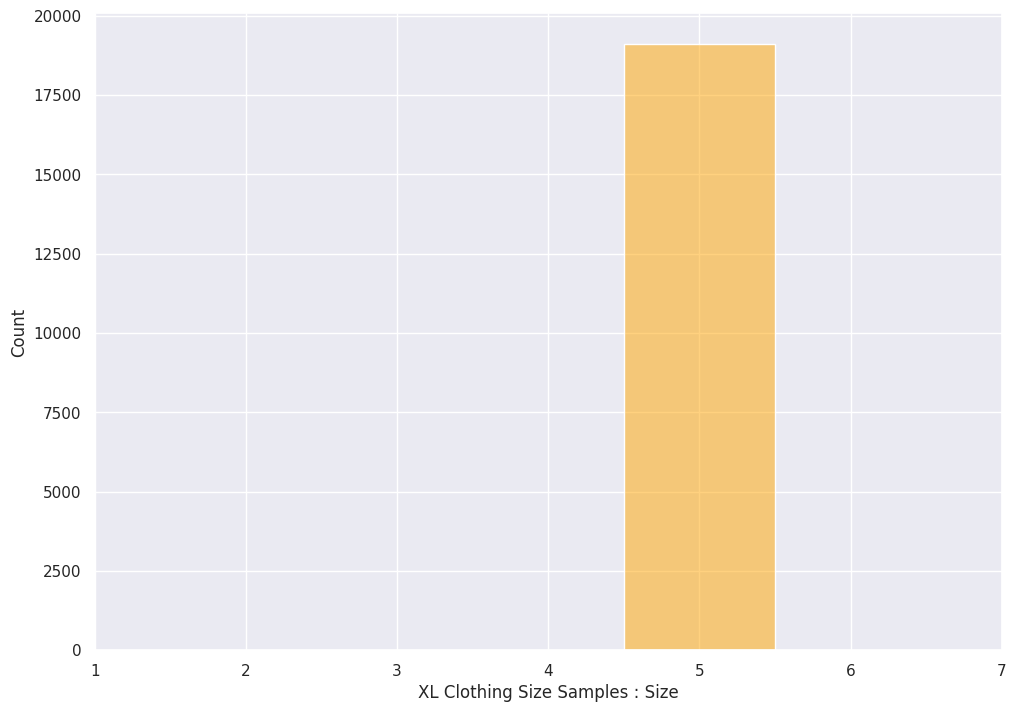

In [ ]:
count_plotted = sns.histplot(x = 'size', data = df.loc[df['size'] == 5], kde = True, color = 'orange')
count_plotted.set(xlabel = "XL Clothing Size Samples : Size")
count_plotted.set(xlim = (1.0000, 7.0000))

[Text(0.5, 0, 'XL Clothing Size Samples : Size')]

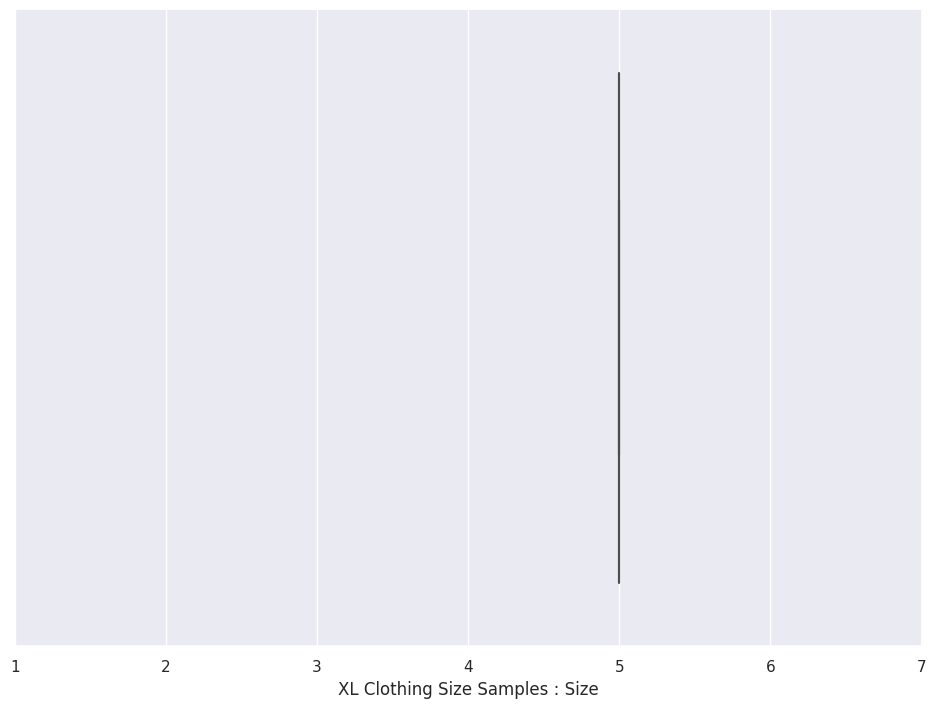

In [ ]:
boxxer_plot = sns.boxplot(x = 'size', data = df.loc[df['size'] == 5], color = 'orange')
boxxer_plot.set(xlim = (1.0000, 7.0000))
boxxer_plot.set(xlabel = "XL Clothing Size Samples : Size")

In [ ]:
numpy_array = np.array(df.loc[df['size'] == 5]['size'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 5.0000 or greater than 5.0000
There are 0 outliers.


[(7.8283, 54.3236)]

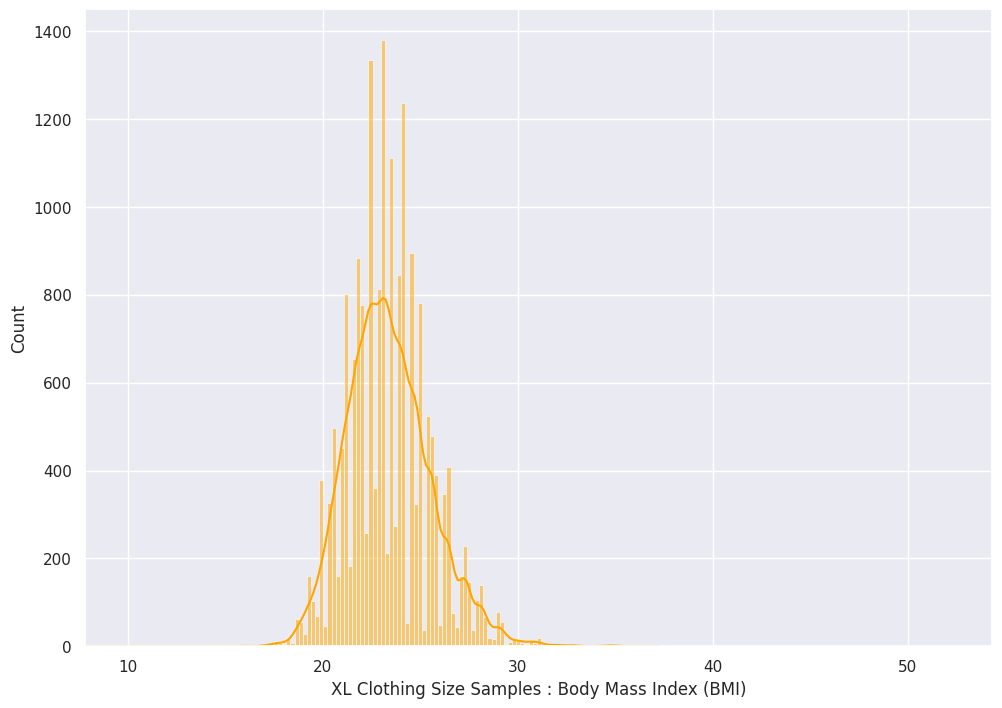

In [ ]:
count_plotted = sns.histplot(x = 'bmi', data = df.loc[df['size'] == 5], kde = True, color = 'orange')
count_plotted.set(xlabel = "XL Clothing Size Samples : Body Mass Index (BMI)")
count_plotted.set(xlim = (7.8283, 54.3236))

[Text(0.5, 0, 'XL Clothing Size Samples : Body Mass Index (BMI)')]

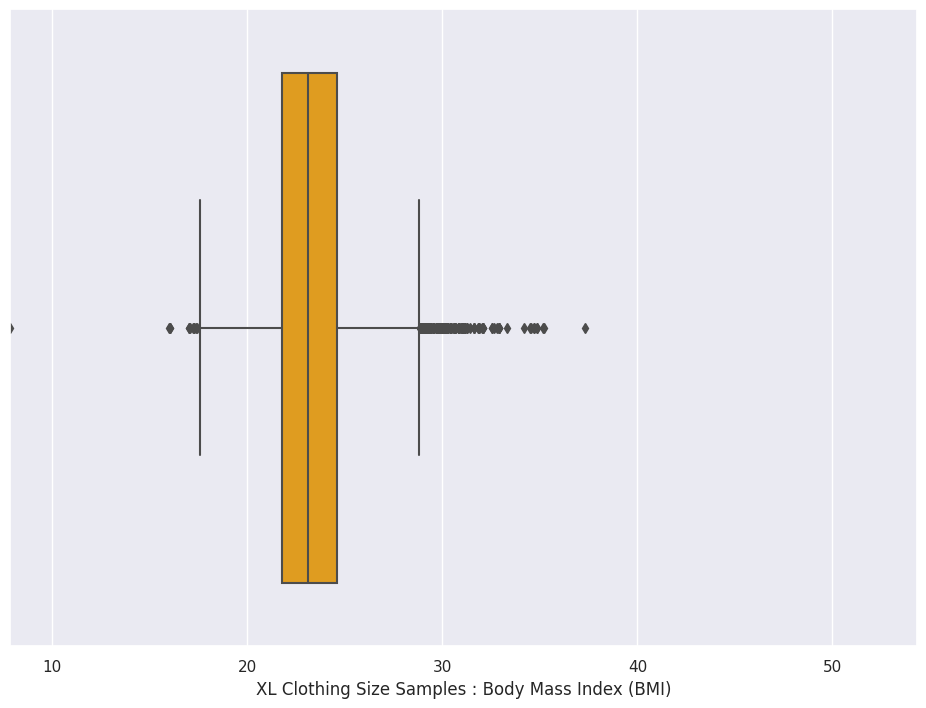

In [ ]:
boxxer_plot = sns.boxplot(x = 'bmi', data = df.loc[df['size'] == 5], color = 'orange')
boxxer_plot.set(xlim = (7.8283, 54.3236))
boxxer_plot.set(xlabel = "XL Clothing Size Samples : Body Mass Index (BMI)")

In [ ]:
numpy_array = np.array(df.loc[df['size'] == 5]['bmi'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 17.5665 or greater than 28.8253
There are 284 outliers.


# **XXL**

[(22.0, 136.0)]

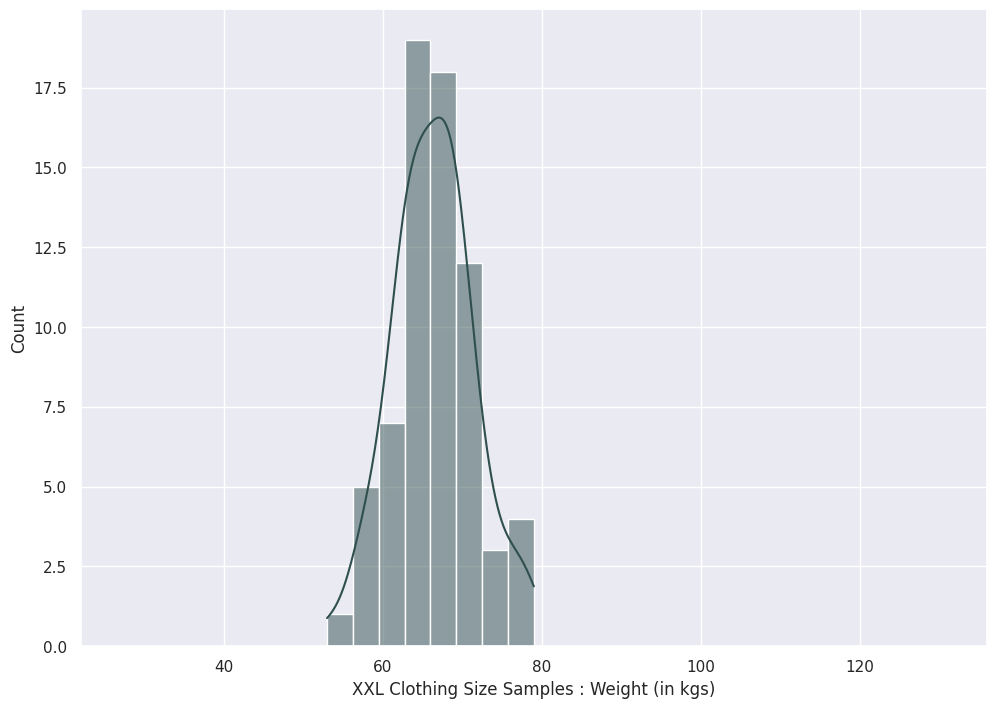

In [ ]:
count_plotted = sns.histplot(x = 'weight', data = df.loc[df['size'] == 6], kde = True, color = 'darkslategrey')
count_plotted.set(xlabel = "XXL Clothing Size Samples : Weight (in kgs)")
count_plotted.set(xlim = (22.0000, 136.0000))

[Text(0.5, 0, 'XXL Clothing Size Samples : Weight (in kgs)')]

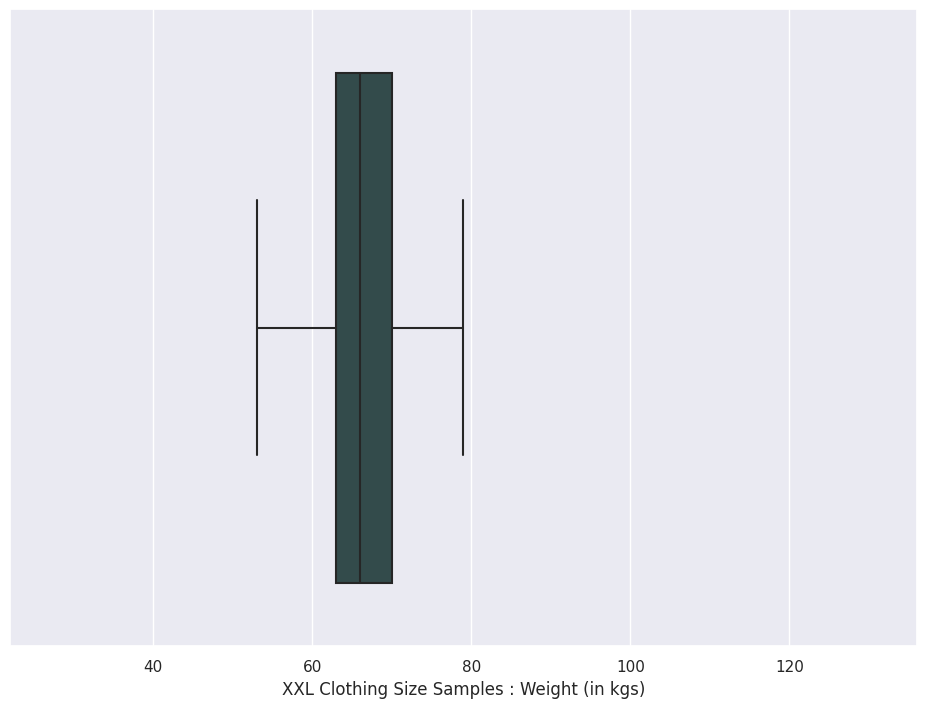

In [ ]:
boxxer_plot = sns.boxplot(x = 'weight', data = df.loc[df['size'] == 6], color = 'darkslategrey')
boxxer_plot.set(xlim = (22.0000, 136.0000))
boxxer_plot.set(xlabel = "XXL Clothing Size Samples : Weight (in kgs)")

In [ ]:
numpy_array = np.array(df.loc[df['size'] == 6]['weight'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 52.5000 or greater than 80.5000
There are 0 outliers.


[(0.0, 117.0)]

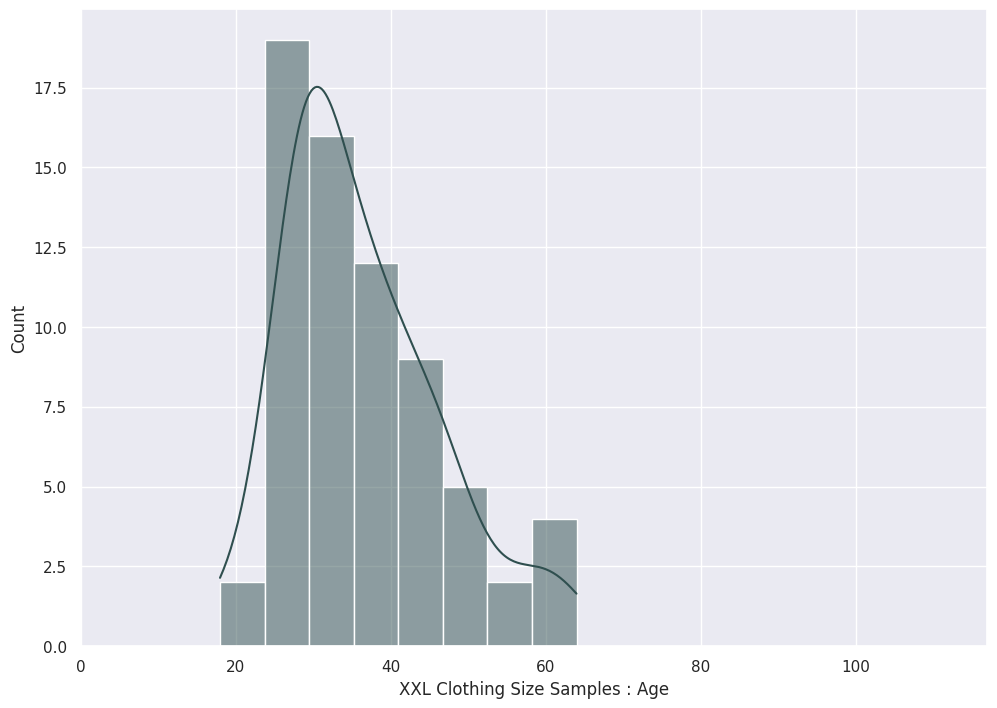

In [ ]:
count_plotted = sns.histplot(x = 'age', data = df.loc[df['size'] == 6], kde = True, color = 'darkslategrey')
count_plotted.set(xlabel = "XXL Clothing Size Samples : Age")
count_plotted.set(xlim = (0.0000, 117.0000))

[Text(0.5, 0, 'XXL Clothing Size Samples : Age')]

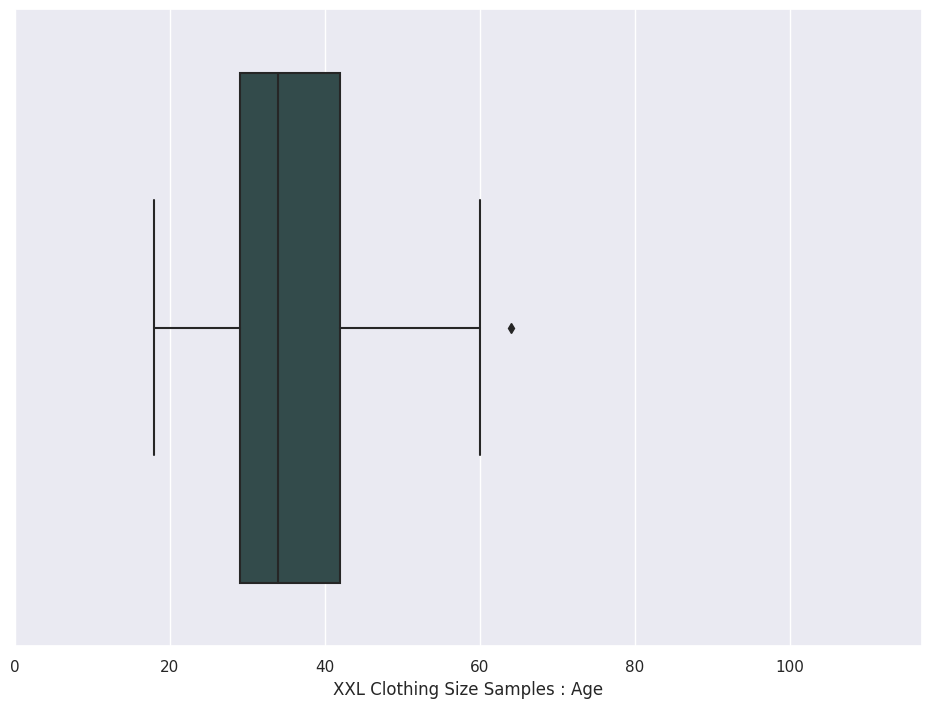

In [ ]:
boxxer_plot = sns.boxplot(x = 'age', data = df.loc[df['size'] == 6], color = 'darkslategrey')
boxxer_plot.set(xlim = (0.0000, 117.0000))
boxxer_plot.set(xlabel = "XXL Clothing Size Samples : Age")

In [ ]:
numpy_array = np.array(df.loc[df['size'] == 6]['age'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values greater than 61.5000
There are 1 outliers.


[(137.16, 193.04)]

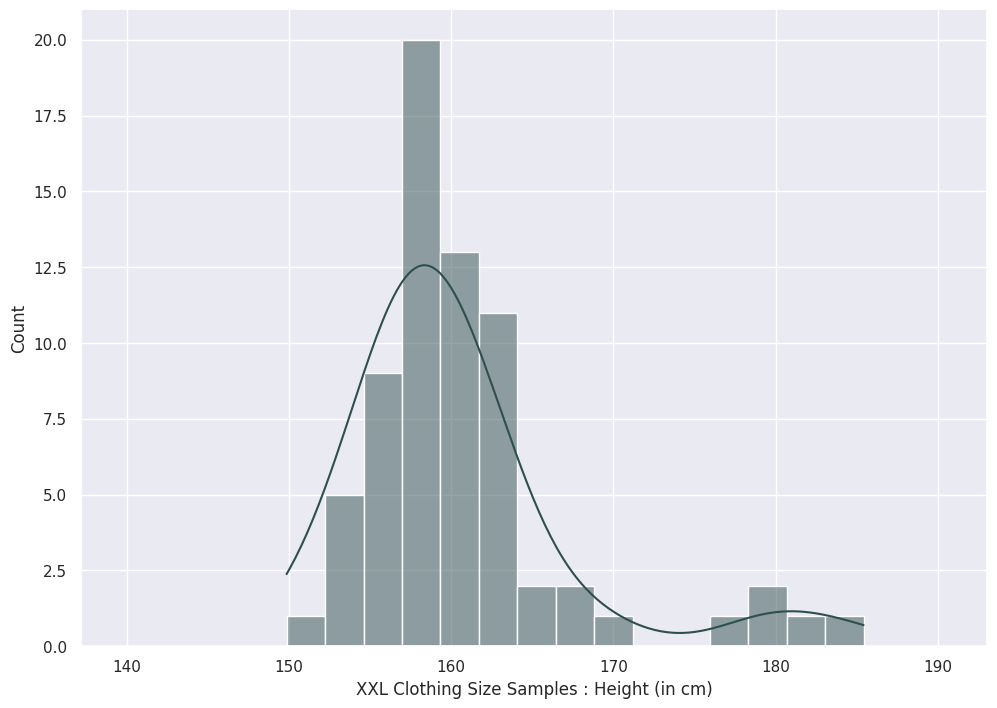

In [ ]:
count_plotted = sns.histplot(x = 'height', data = df.loc[df['size'] == 6], kde = True, color = 'darkslategrey')
count_plotted.set(xlabel = "XXL Clothing Size Samples : Height (in cm)")
count_plotted.set(xlim = (137.1600, 193.0400))

[Text(0.5, 0, 'XXL Clothing Size Samples : Height (in cm)')]

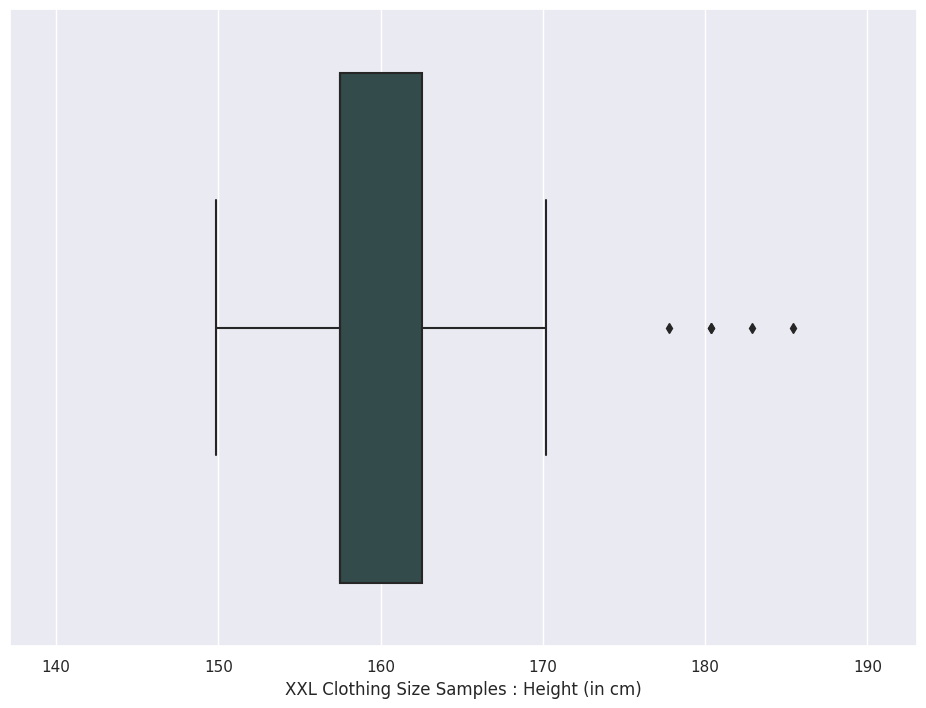

In [ ]:
boxxer_plot = sns.boxplot(x = 'height', data = df.loc[df['size'] == 6], color = 'darkslategrey')
boxxer_plot.set(xlim = (137.1600, 193.0400))
boxxer_plot.set(xlabel = "XXL Clothing Size Samples : Height (in cm)")

In [ ]:
numpy_array = np.array(df.loc[df['size'] == 6]['height'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values greater than 170.1800
There are 5 outliers.


[(1.0, 7.0)]

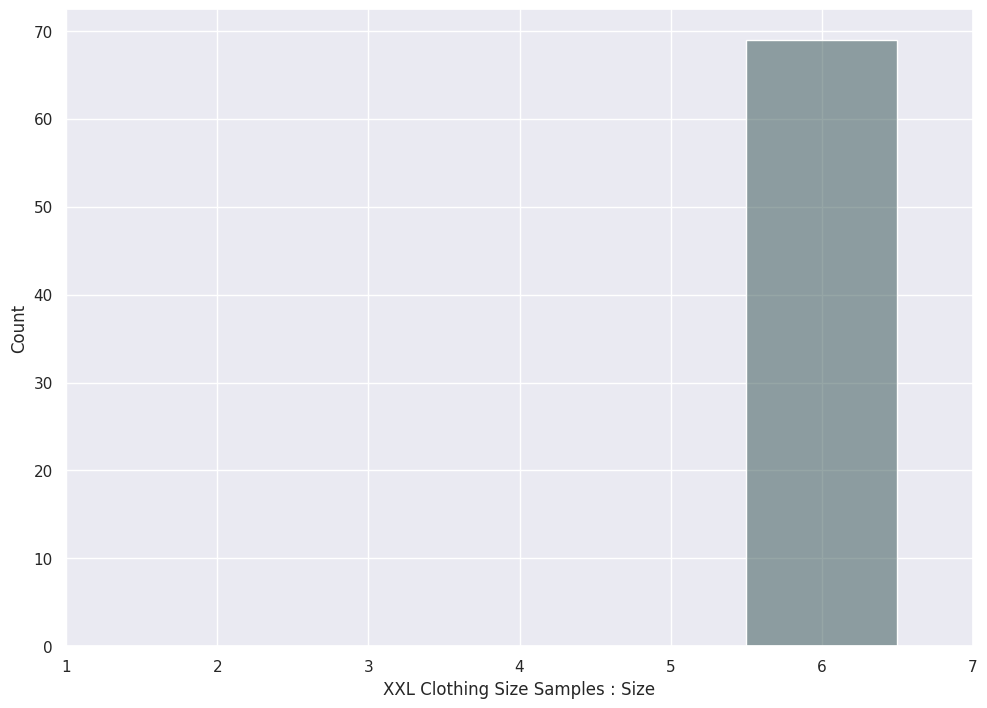

In [ ]:
count_plotted = sns.histplot(x = 'size', data = df.loc[df['size'] == 6], kde = True, color = 'darkslategrey')
count_plotted.set(xlabel = "XXL Clothing Size Samples : Size")
count_plotted.set(xlim = (1.0000, 7.0000))

[Text(0.5, 0, 'XXL Clothing Size Samples : Size')]

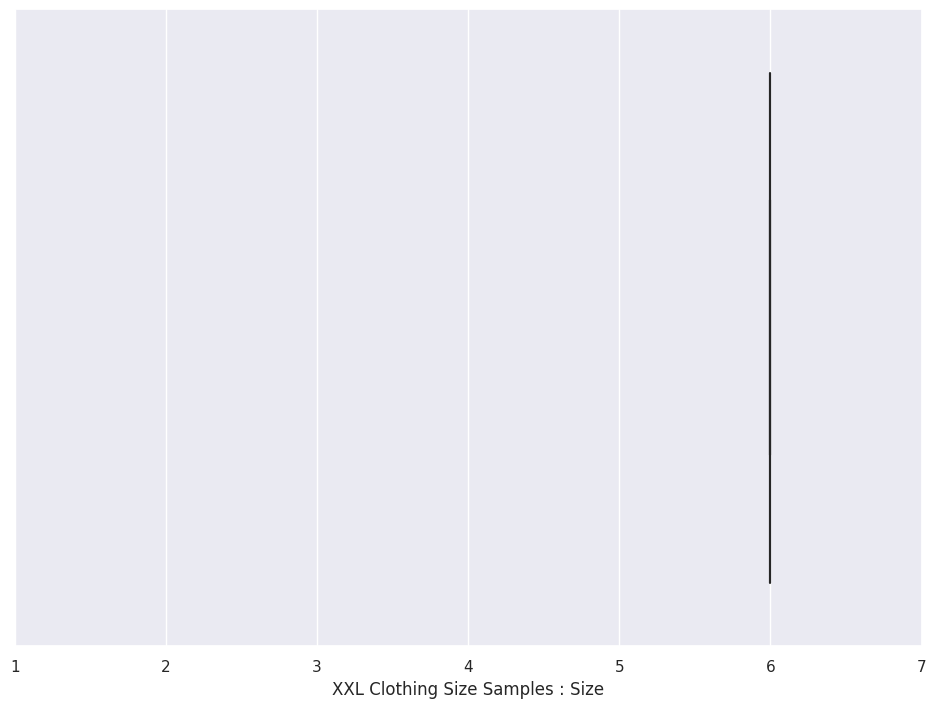

In [ ]:
boxxer_plot = sns.boxplot(x = 'size', data = df.loc[df['size'] == 6], color = 'darkslategrey')
boxxer_plot.set(xlim = (1.0000, 7.0000))
boxxer_plot.set(xlabel = "XXL Clothing Size Samples : Size")

In [ ]:
numpy_array = np.array(df.loc[df['size'] == 6]['size'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 6.0000 or greater than 6.0000
There are 0 outliers.


[(7.8283, 54.3236)]

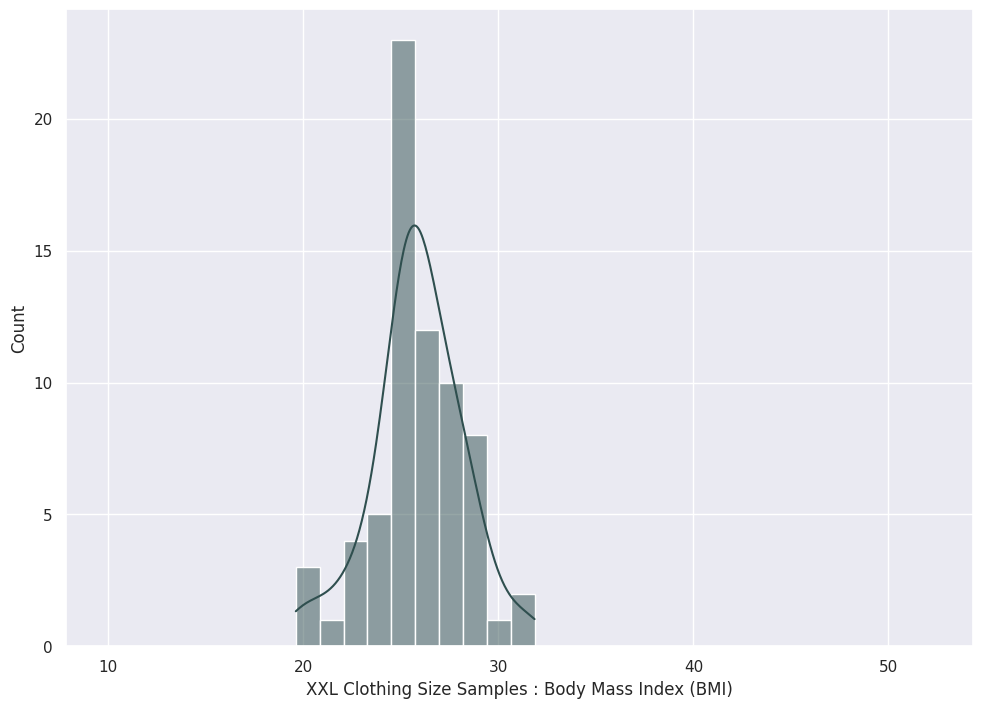

In [ ]:
count_plotted = sns.histplot(x = 'bmi', data = df.loc[df['size'] == 6], kde = True, color = 'darkslategrey')
count_plotted.set(xlabel = "XXL Clothing Size Samples : Body Mass Index (BMI)")
count_plotted.set(xlim = (7.8283, 54.3236))

[Text(0.5, 0, 'XXL Clothing Size Samples : Body Mass Index (BMI)')]

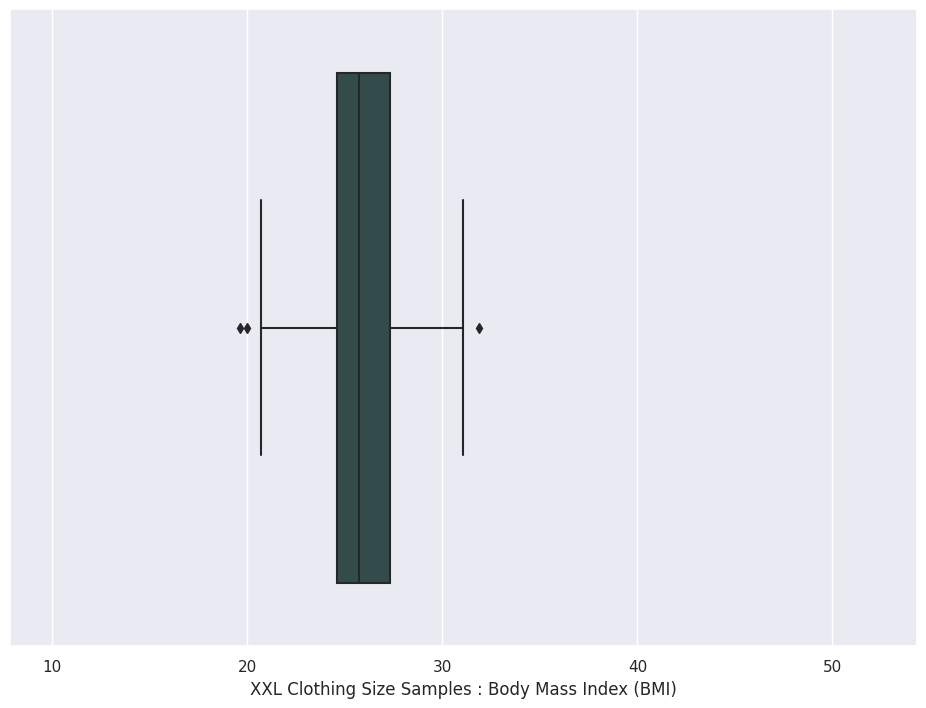

In [ ]:
boxxer_plot = sns.boxplot(x = 'bmi', data = df.loc[df['size'] == 6], color = 'darkslategrey')
boxxer_plot.set(xlim = (7.8283, 54.3236))
boxxer_plot.set(xlabel = "XXL Clothing Size Samples : Body Mass Index (BMI)")

In [ ]:
numpy_array = np.array(df.loc[df['size'] == 6]['bmi'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 20.5027 or greater than 31.4375
There are 3 outliers.


# **XXXL**

[(22.0, 136.0)]

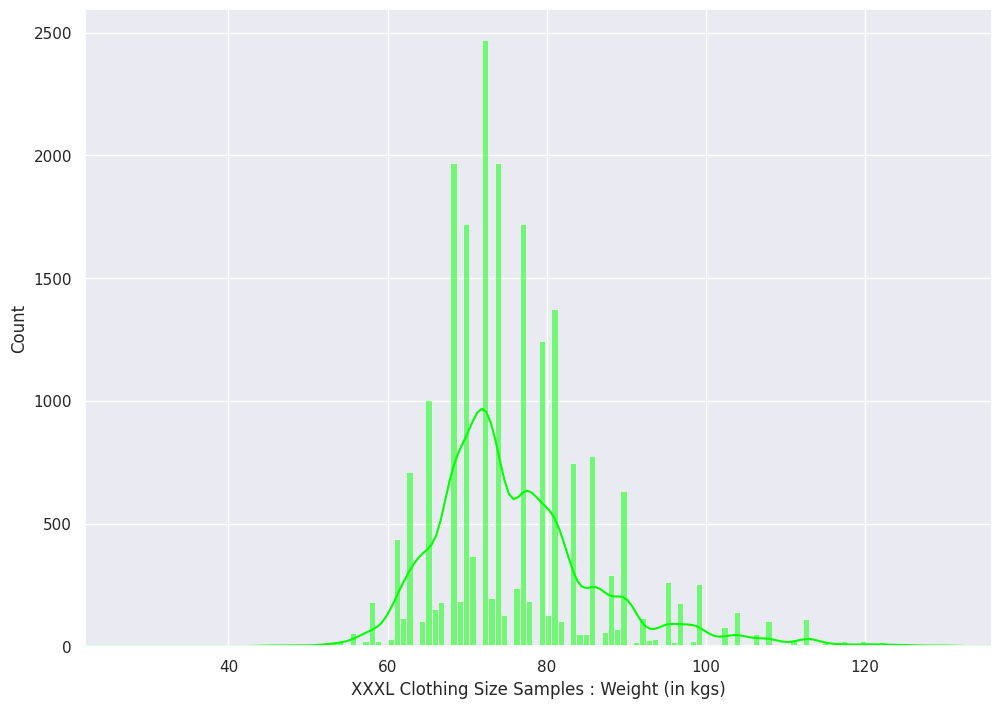

In [ ]:
count_plotted = sns.histplot(x = 'weight', data = df.loc[df['size'] == 7], kde = True, color = 'lime')
count_plotted.set(xlabel = "XXXL Clothing Size Samples : Weight (in kgs)")
count_plotted.set(xlim = (22.0000, 136.0000))

[Text(0.5, 0, 'XXXL Clothing Size Samples : Weight (in kgs)')]

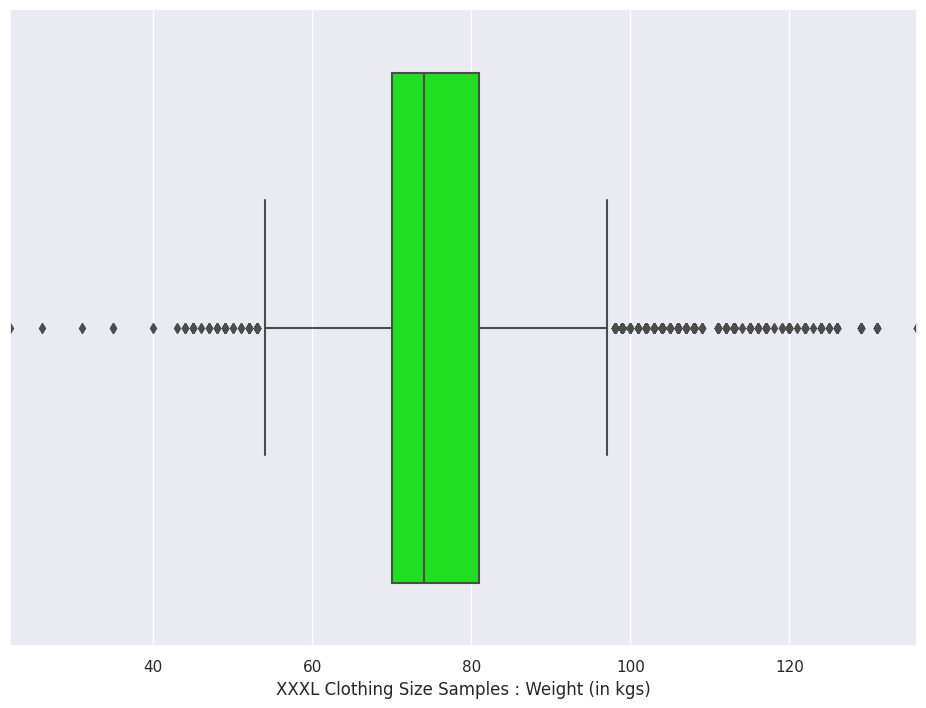

In [ ]:
boxxer_plot = sns.boxplot(x = 'weight', data = df.loc[df['size'] == 7], color = 'lime')
boxxer_plot.set(xlim = (22.0000, 136.0000))
boxxer_plot.set(xlabel = "XXXL Clothing Size Samples : Weight (in kgs)")

In [ ]:
numpy_array = np.array(df.loc[df['size'] == 7]['weight'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 53.5000 or greater than 97.5000
There are 1024 outliers.


[(0.0, 117.0)]

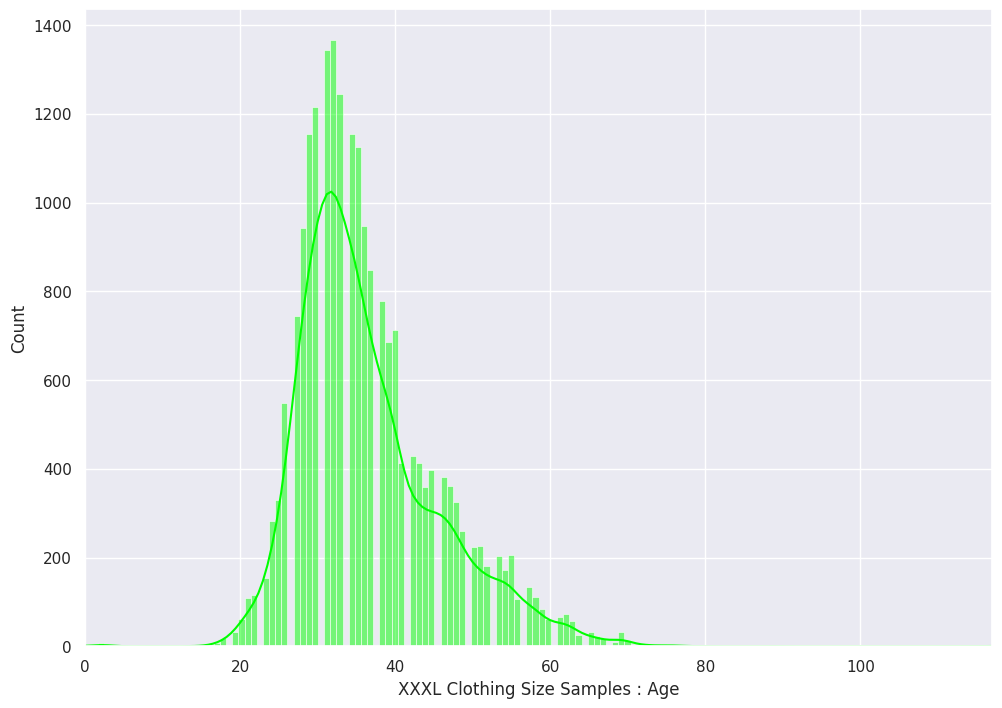

In [ ]:
count_plotted = sns.histplot(x = 'age', data = df.loc[df['size'] == 7], kde = True, color = 'lime')
count_plotted.set(xlabel = "XXXL Clothing Size Samples : Age")
count_plotted.set(xlim = (0.0000, 117.0000))

[Text(0.5, 0, 'XXXL Clothing Size Samples : Age')]

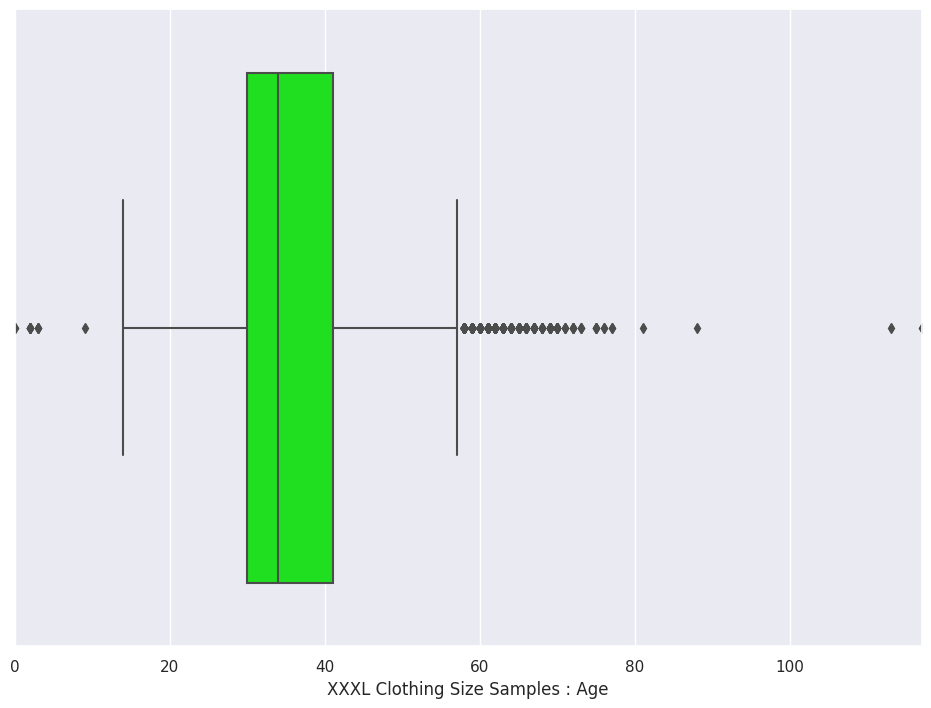

In [ ]:
boxxer_plot = sns.boxplot(x = 'age', data = df.loc[df['size'] == 7], color = 'lime')
boxxer_plot.set(xlim = (0.0000, 117.0000))
boxxer_plot.set(xlabel = "XXXL Clothing Size Samples : Age")

In [ ]:
numpy_array = np.array(df.loc[df['size'] == 7]['age'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 13.5000 or greater than 57.5000
There are 645 outliers.


[(137.16, 193.04)]

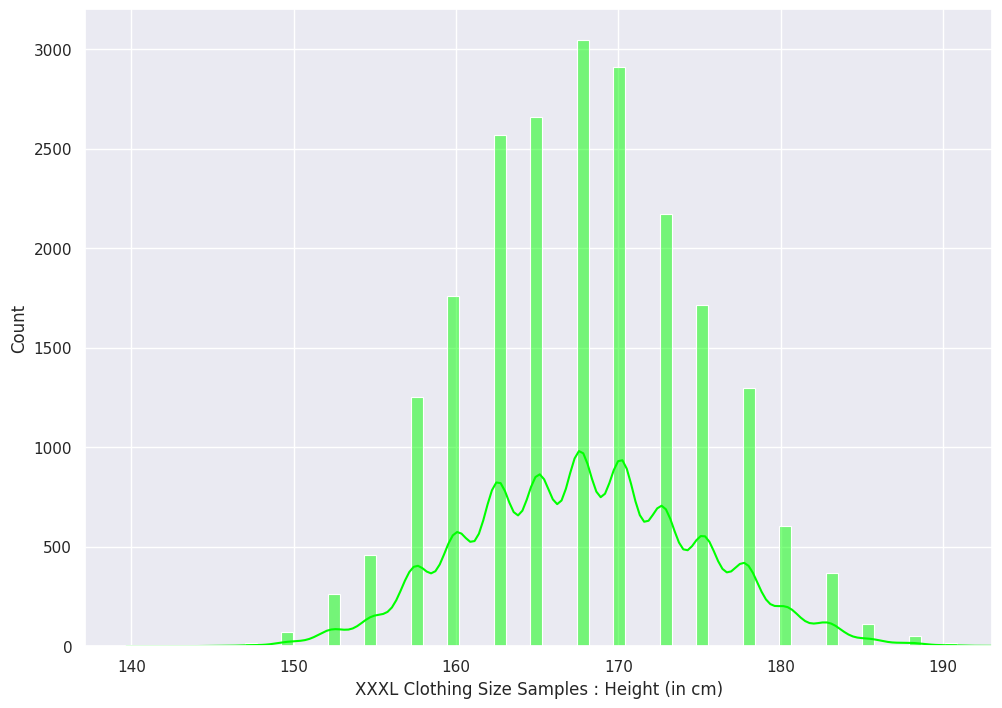

In [ ]:
count_plotted = sns.histplot(x = 'height', data = df.loc[df['size'] == 7], kde = True, color = 'lime')
count_plotted.set(xlabel = "XXXL Clothing Size Samples : Height (in cm)")
count_plotted.set(xlim = (137.1600, 193.0400))

[Text(0.5, 0, 'XXXL Clothing Size Samples : Height (in cm)')]

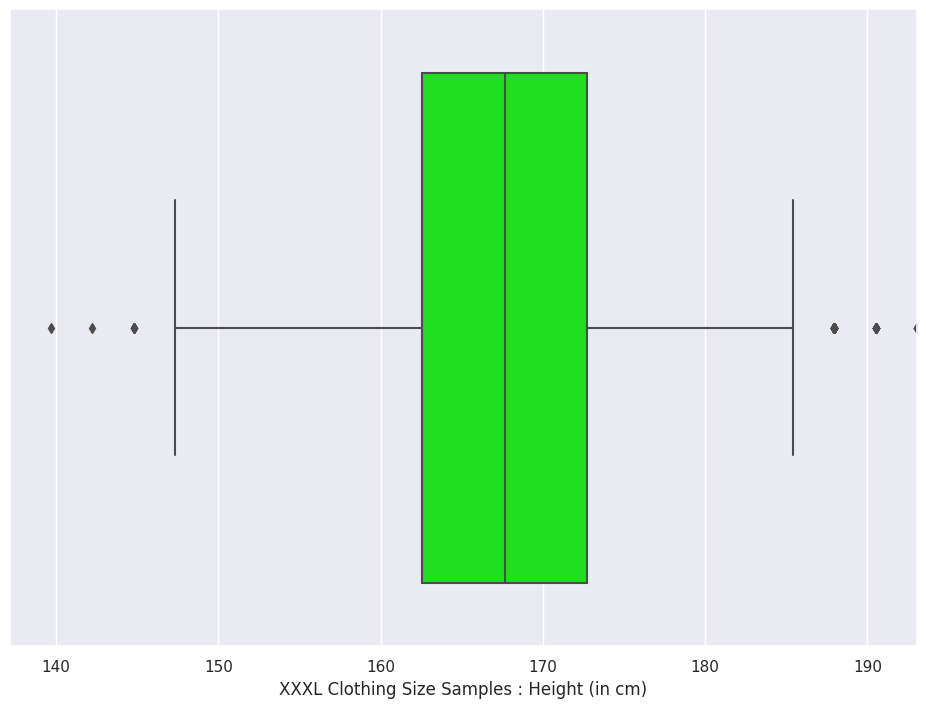

In [ ]:
boxxer_plot = sns.boxplot(x = 'height', data = df.loc[df['size'] == 7], color = 'lime')
boxxer_plot.set(xlim = (137.1600, 193.0400))
boxxer_plot.set(xlabel = "XXXL Clothing Size Samples : Height (in cm)")

In [ ]:
numpy_array = np.array(df.loc[df['size'] == 7]['height'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 147.3200 or greater than 187.9600
There are 79 outliers.


[(1.0, 7.0)]

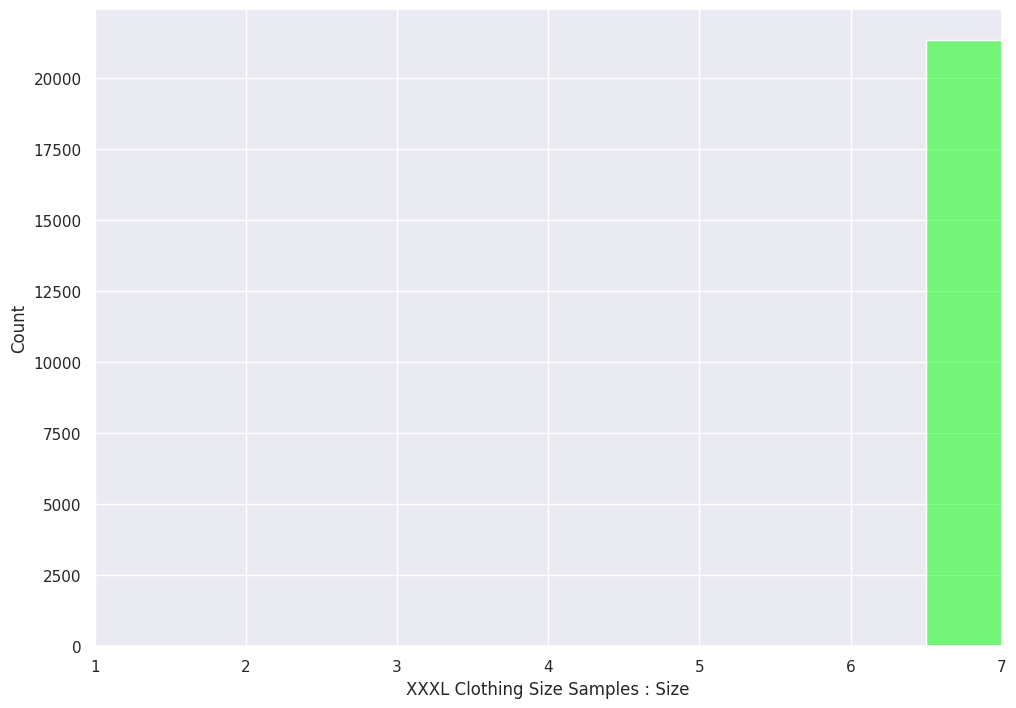

In [ ]:
count_plotted = sns.histplot(x = 'size', data = df.loc[df['size'] == 7], kde = True, color = 'lime')
count_plotted.set(xlabel = "XXXL Clothing Size Samples : Size")
count_plotted.set(xlim = (1.0000, 7.0000))

[Text(0.5, 0, 'XXXL Clothing Size Samples : Size')]

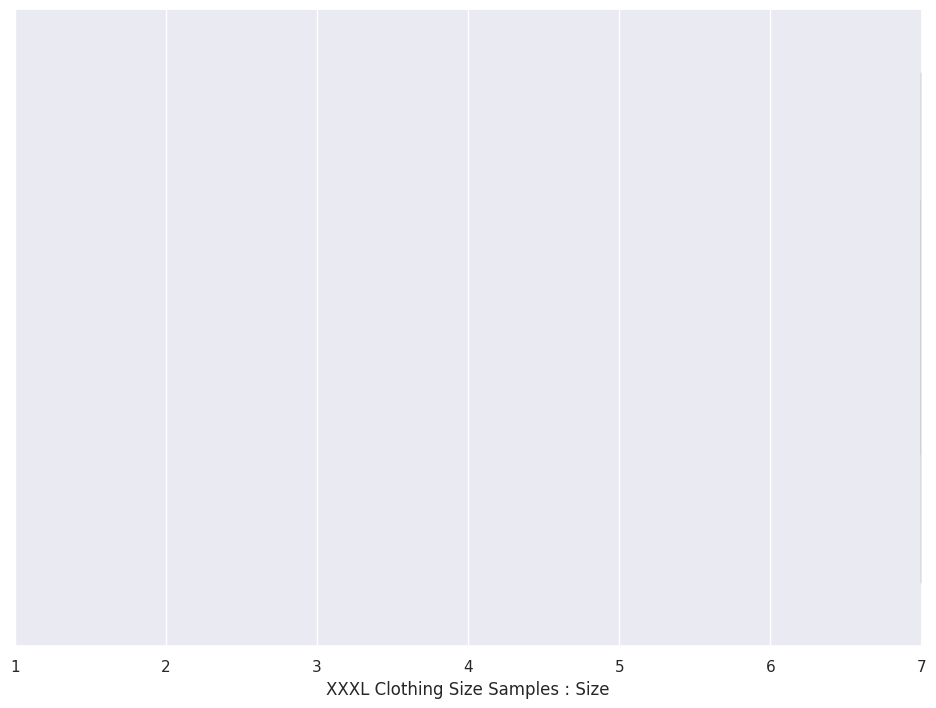

In [ ]:
boxxer_plot = sns.boxplot(x = 'size', data = df.loc[df['size'] == 7], color = 'lime')
boxxer_plot.set(xlim = (1.0000, 7.0000))
boxxer_plot.set(xlabel = "XXXL Clothing Size Samples : Size")

# **C_OUTLIERS**

In [ ]:
numpy_array = np.array(df.loc[df['size'] == 7]['size'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 7.0000 or greater than 7.0000
There are 0 outliers.


# **BMI**

[(7.8283, 54.3236)]

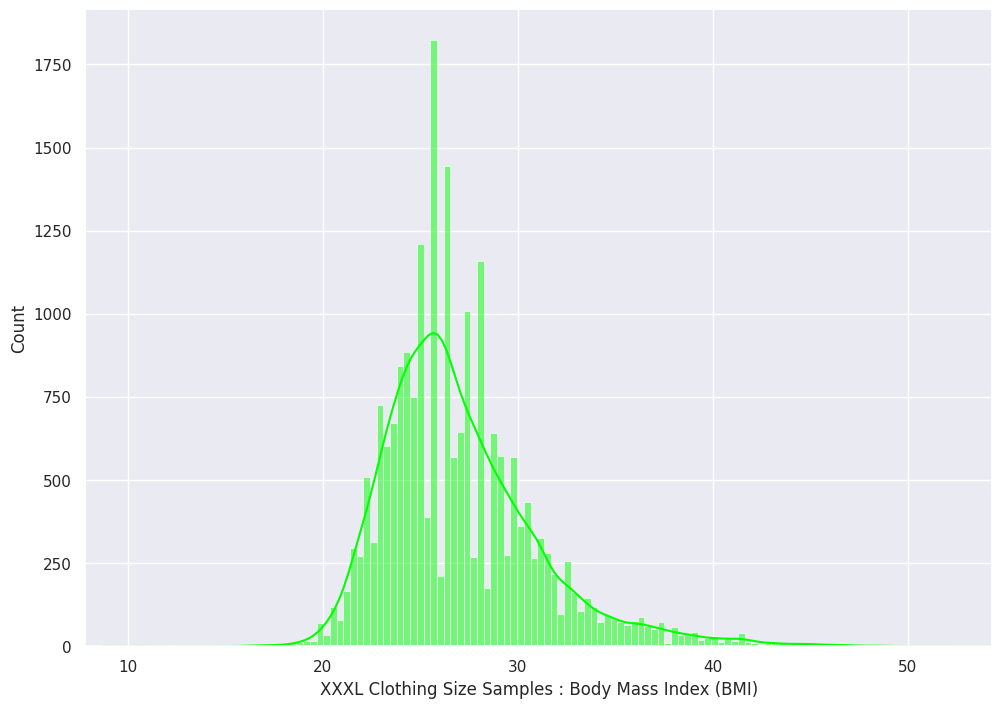

In [ ]:
count_plotted = sns.histplot(x = 'bmi', data = df.loc[df['size'] == 7], kde = True, color = 'lime')
count_plotted.set(xlabel = "XXXL Clothing Size Samples : Body Mass Index (BMI)")
count_plotted.set(xlim = (7.8283, 54.3236))

[Text(0.5, 0, 'XXXL Clothing Size Samples : Body Mass Index (BMI)')]

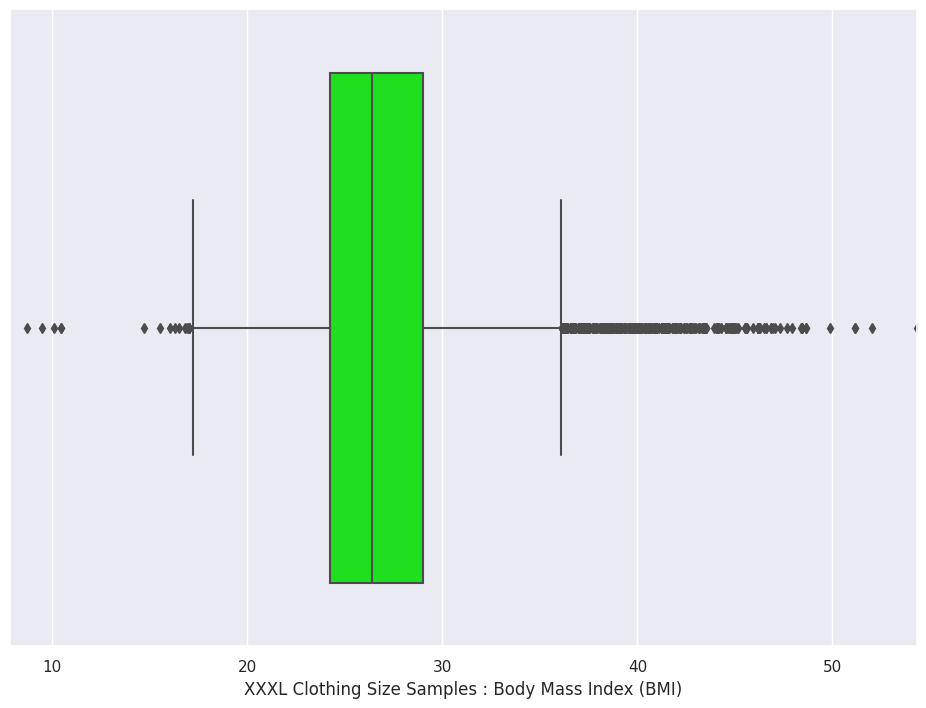

In [ ]:
boxxer_plot = sns.boxplot(x = 'bmi', data = df.loc[df['size'] == 7], color = 'lime')
boxxer_plot.set(xlim = (7.8283, 54.3236))
boxxer_plot.set(xlabel = "XXXL Clothing Size Samples : Body Mass Index (BMI)")

In [ ]:
numpy_array = np.array(df.loc[df['size'] == 7]['bmi'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 17.0583 or greater than 36.1367
There are 778 outliers.


In [ ]:
df

,weight,age,height,size,bmi
0,62,28.0,172.72,5,20.782914
1,59,36.0,167.64,4,20.994073
2,61,34.0,165.10,3,22.378743
3,65,27.0,175.26,4,21.161563
4,62,45.0,172.72,3,20.782914
...,...,...,...,...,...
119729,63,42.0,175.26,3,20.510438
119730,45,29.0,154.94,2,18.744999
119731,61,31.0,172.72,3,20.447705
119732,74,31.0,167.64,5,26.331549


# **MIN-MAX**

In [ ]:
df

,age,height,weight
0,-0.500000,0.50,-0.500000
1,-0.400000,1.00,1.500000
2,-0.100000,-0.75,-0.166667
3,-0.200000,-1.25,-1.166667
4,0.300000,-0.50,0.500000
...,...,...,...
119729,-0.769231,-1.50,0.285714
119730,-0.307692,0.50,1.142857
119731,-0.153846,0.50,0.428571
119732,0.923077,0.50,-0.285714


In [ ]:
from sklearn.preprocessing import RobustScaler
import pandas as pd

temp_frame = []

# Loop melalui nilai unik pada kolom 'size'
for size_type in df['size'].unique():
    ndf = df[['age', 'height', 'weight', 'size']][df['size'] == size_type]

    # Normalisasi dengan Robust Scaling
    scaler = RobustScaler()
    scaled_data = scaler.fit_transform(ndf[['age', 'height', 'weight']])

    # Konversi hasil scaling ke DataFrame
    scaled_df = pd.DataFrame(data=scaled_data, columns=['age', 'height', 'weight'])

    # Tambahkan kembali kolom 'size' yang sesuai
    scaled_df['size'] = ndf['size'].values

    temp_frame.append(scaled_df)

# Gabungkan semua frame ke dalam satu DataFrame
df = pd.concat(temp_frame, ignore_index=True)

df.head()


,age,height,weight,size
0,-0.5,0.50,-0.500000,5
1,-0.4,1.00,1.500000,5
2,-0.1,-0.75,-0.166667,5
3,-0.2,-1.25,-1.166667,5
4,0.3,-0.50,0.500000,5


# **ZSCORE**

In [ ]:
temp_frame = []
sizes = []
for size_type in df_cleaned_cleaned_cleaned['size'].unique():
    sizes.append(size_type)
    ndf = df_cleaned_cleaned_cleaned[['age','height','weight']][df_cleaned_cleaned_cleaned['size'] == size_type]
    zscore = ((ndf - ndf.mean())/ndf.std())
    temp_frame.append(zscore)

for x in range(len(temp_frame)):
    temp_frame[x]['age'] = temp_frame[x]['age'][(temp_frame[x]['age']>-3) & (temp_frame[x]['age']<3)]
    temp_frame[x]['height'] = temp_frame[x]['height'][(temp_frame[x]['height']>-3) & (temp_frame[x]['height']<3)]
    temp_frame[x]['weight'] = temp_frame[x]['weight'][(temp_frame[x]['weight']>-3) & (temp_frame[x]['weight']<3)]

for x in range(len(sizes)):
    temp_frame[x]['size'] = sizes[x]
df_cleaned_cleaned_cleaned = pd.concat(temp_frame)
df_cleaned_cleaned_cleaned.head()

,age,height,weight,size
0,-0.871981,0.769357,-0.709900,5
24,-0.712464,1.546928,1.579054,5
25,-0.233914,-1.174573,-0.328408,5
28,-0.393431,-1.952145,-1.472885,5
34,0.404154,-0.785787,0.434577,5


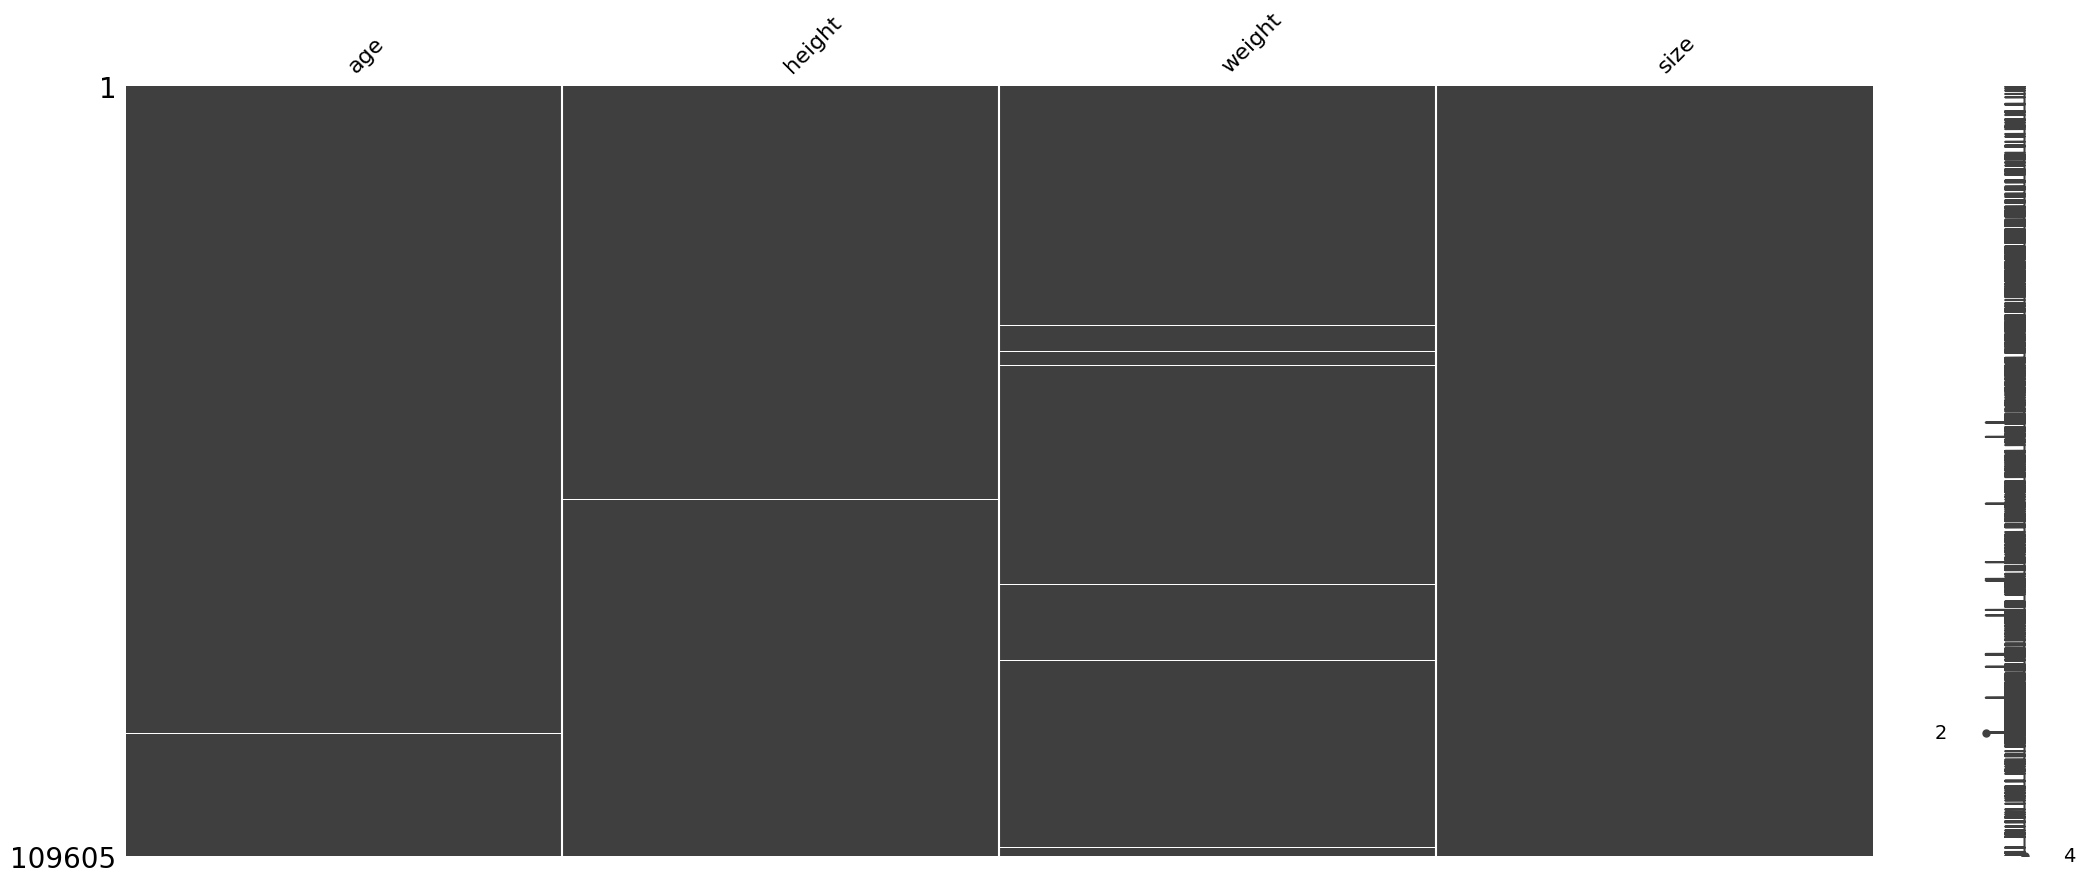

In [ ]:
msno.matrix(df_cleaned_cleaned_cleaned)
plt.show()

# **FILL_Median**

In [ ]:
df_cleaned_cleaned_cleaned["age"] = df_cleaned_cleaned_cleaned["age"].fillna(df_cleaned_cleaned_cleaned['age'].median())
df_cleaned_cleaned_cleaned["height"] = df_cleaned_cleaned_cleaned["height"].fillna(df_cleaned_cleaned_cleaned['height'].median())
df_cleaned_cleaned_cleaned["weight"] = df_cleaned_cleaned_cleaned["weight"].fillna(df_cleaned_cleaned_cleaned['weight'].median())

In [ ]:
df_cleaned_cleaned_cleaned["bmi"] = df_cleaned_cleaned_cleaned["height"]/df_cleaned_cleaned_cleaned["weight"]

# **C_NULL**

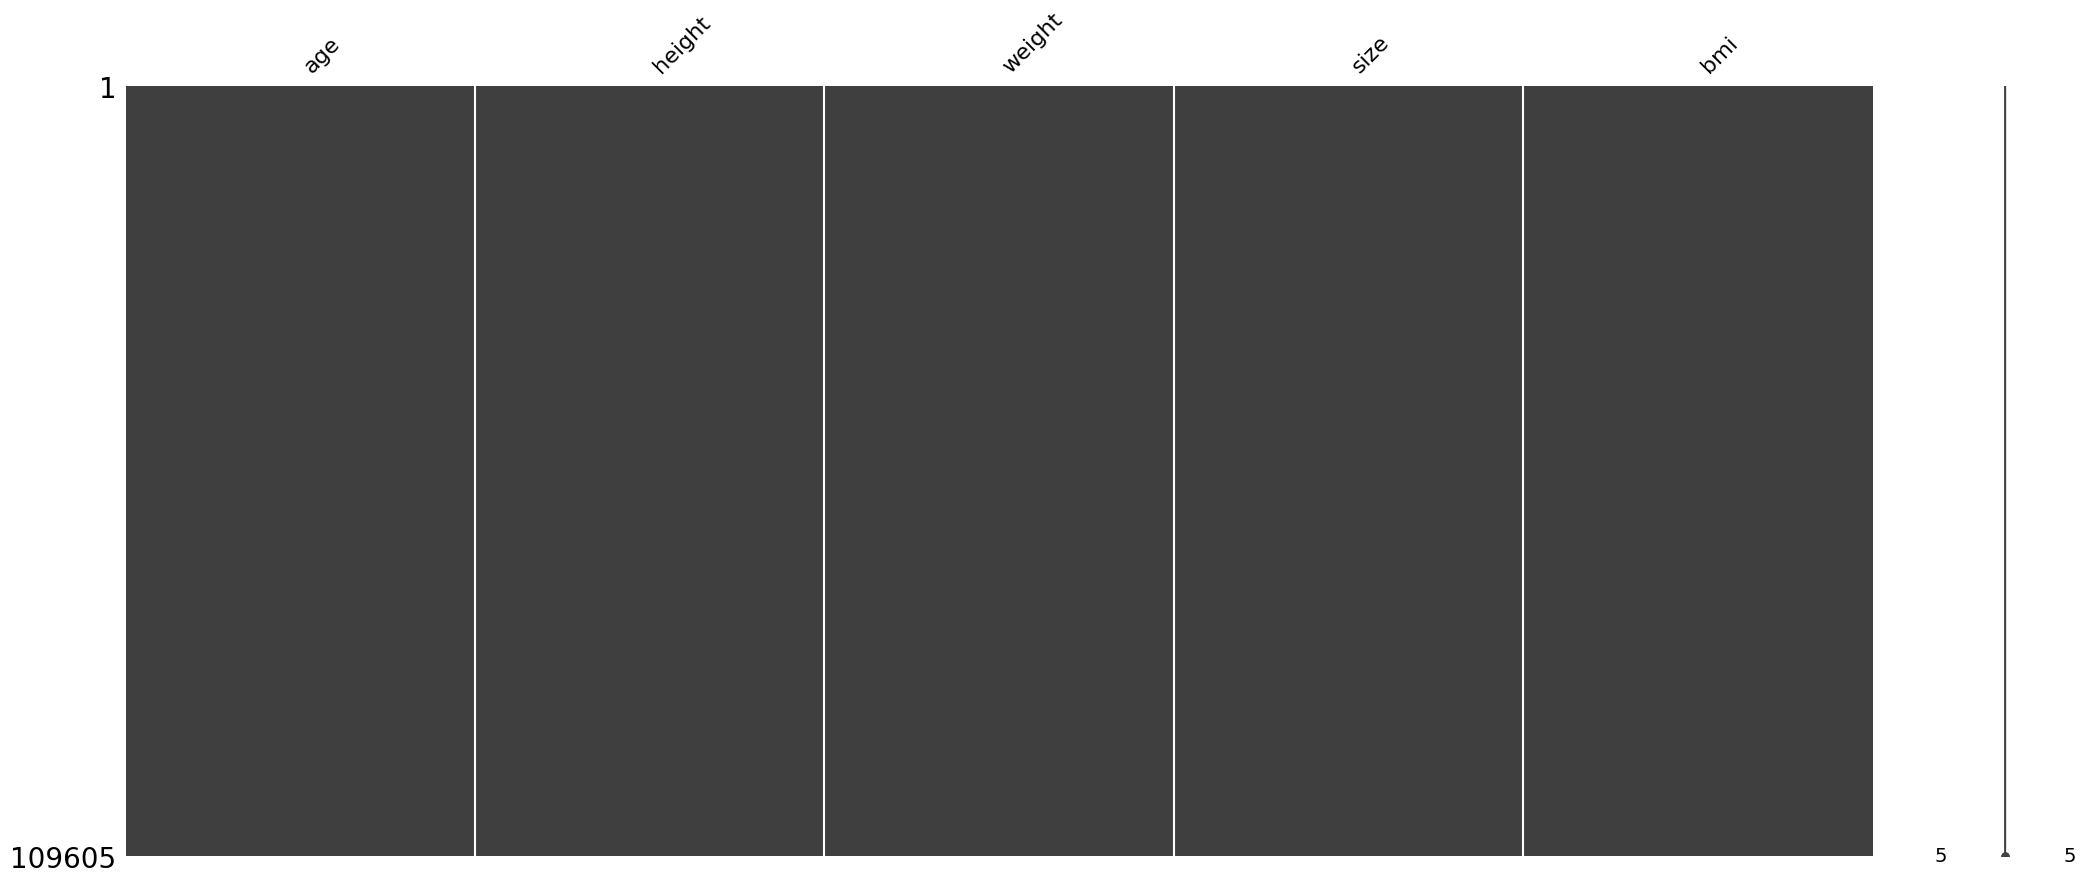

In [ ]:
msno.matrix(df_cleaned_cleaned_cleaned)
plt.show()

# **SAVE_DF**

In [ ]:
df_cleaned_cleaned_cleaned.head()

,age,height,weight,size,bmi
0,-0.871981,0.769357,-0.709900,5,-1.083754
24,-0.712464,1.546928,1.579054,5,0.979655
25,-0.233914,-1.174573,-0.328408,5,3.576570
28,-0.393431,-1.952145,-1.472885,5,1.325389
34,0.404154,-0.785787,0.434577,5,-1.808165


In [ ]:
from google.colab import drive

drive.mount('/content/drive')
dfsv = df_cleaned_cleaned_cleaned.copy()
dfsv.to_csv('/content/drive/MyDrive/Model/clothoutlier.csv', index=False)

Mounted at /content/drive


# **INISIALISASI**

In [ ]:
X = df[['weight', 'age', 'height', 'bmi']]
X.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 119734 entries, 0 to 117637
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   weight  119734 non-null  float64
 1   age     119734 non-null  float64
 2   height  119734 non-null  float64
 3   bmi     119734 non-null  float64
dtypes: float64(4)
memory usage: 4.6 MB


In [ ]:
y = df[['size']]
y.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 119734 entries, 0 to 117637
Data columns (total 1 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   size    119734 non-null  int64
dtypes: int64(1)
memory usage: 1.8 MB


# **DATA_SPLIT**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score , classification_report, ConfusionMatrixDisplay,precision_score,recall_score, f1_score,roc_auc_score,roc_curve

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [ ]:
print("Shape of Data (20%)")
print("X_train shape : ", X_train.shape)
print("y_train shape : ", y_train.shape)
print("X_test shape : ", X_test.shape)
print("y_test shape : ", y_test.shape)

Shape of Data (20%)
X_train shape :  (95787, 4)
y_train shape :  (95787, 1)
X_test shape :  (23947, 4)
y_test shape :  (23947, 1)


# **MODELS**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors = 3)
knn.fit(X_train, y_train.values.ravel())
training_prediction = knn.predict(X_train)
testing_prediction = knn.predict(X_test)

#Training Metrics
training_accuracy = accuracy_score(y_train, training_prediction)
training_f1 = f1_score(y_train, training_prediction, average = 'weighted')
training_precision = precision_score(y_train, training_prediction, average = 'weighted')
training_recall = recall_score(y_train, training_prediction, average = 'weighted')

#Testing Metrics
testing_accuracy = accuracy_score(y_test, testing_prediction)
testing_f1 = f1_score(y_test, testing_prediction, average = 'weighted')
testing_precision = precision_score(y_test, testing_prediction, average = 'weighted')
testing_recall = recall_score(y_test, testing_prediction, average = 'weighted')

print('AL : K-Nearest Neighbors (20%)')
print('\n')
print('Training Model Performance Check')
print('Accuracy Score : {:.4f}'.format(training_accuracy))
print('F1 Score : {:.4f}'.format(training_f1))
print('Precision Score : {:.4f}'.format(training_precision))
print('Recall Score : {:.4f}'.format(training_recall))

print('\n')
print('Testing Model Performance Check')
print('Accuracy Score : {:.4f}'.format(testing_accuracy))
print('F1 Score : {:.4f}'.format(testing_f1))
print('Precision Score : {:.4f}'.format(testing_precision))
print('Recall Score : {:.4f}'.format(testing_recall))

AL : K-Nearest Neighbors (20%)


Training Model Performance Check
Accuracy Score : 0.9533
F1 Score : 0.9530
Precision Score : 0.9534
Recall Score : 0.9533


Testing Model Performance Check
Accuracy Score : 0.9008
F1 Score : 0.9004
Precision Score : 0.9006
Recall Score : 0.9008


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

Decision_Tree = DecisionTreeClassifier()
Decision_Tree.fit(X_train, y_train)
training_prediction = Decision_Tree.predict(X_train)
testing_prediction = Decision_Tree.predict(X_test)

'''
# Visualize Decision Tree
# Note : I have decided to not include the visualization of the said decision tree due to its depth making it hard to visualize
plt.figure(figsize = (25,20))
tree.plot_tree(Decision_Tree,
               feature_names =  dataframed.columns.tolist()[:-1],
               class_names = ['1', '2', '3', '4', '5', '6', '7'],
               filled = True,
               precision = 5)
plt.show()
'''

#Training Metrics
training_accuracy = accuracy_score(y_train, training_prediction)
training_f1 = f1_score(y_train, training_prediction, average = 'weighted')
training_precision = precision_score(y_train, training_prediction, average = 'weighted')
training_recall = recall_score(y_train, training_prediction, average = 'weighted')

#Testing Metrics
testing_accuracy = accuracy_score(y_test, testing_prediction)
testing_f1 = f1_score(y_test, testing_prediction, average = 'weighted')
testing_precision = precision_score(y_test, testing_prediction, average = 'weighted')
testing_recall = recall_score(y_test, testing_prediction, average = 'weighted')

print('AL : Decision Tree (20%)')
print('\n')
print('Training Model Performance Check')
print('Accuracy Score {:.4f}'.format(training_accuracy))
print('F1 Score {:.4f}'.format(training_f1))
print('Precision Score {:.4f}'.format(training_precision))
print('Recall Score {:.4f}'.format(training_recall))

print('\n')
print('Testing Model Performance Check')
print('Accuracy Score {:.4f}'.format(testing_accuracy))
print('F1 Score {:.4f}'.format(testing_f1))
print('Precision Score {:.4f}'.format(testing_precision))
print('Recall Score : {:.4f}'.format(testing_recall))

AL : Decision Tree (20%)


Training Model Performance Check
Accuracy Score 1.0000
F1 Score 1.0000
Precision Score 1.0000
Recall Score 1.0000


Testing Model Performance Check
Accuracy Score 0.9996
F1 Score 0.9996
Precision Score 0.9996
Recall Score : 0.9996


In [ ]:
from sklearn.ensemble import RandomForestClassifier

Random_Forest = RandomForestClassifier()
Random_Forest.fit(X_train, y_train.values.ravel())
training_prediction = Random_Forest.predict(X_train)
testing_prediction = Random_Forest.predict(X_test)

#Training Metrics
training_accuracy = accuracy_score(y_train, training_prediction)
training_f1 = f1_score(y_train, training_prediction, average = 'weighted')
training_precision = precision_score(y_train, training_prediction, average = 'weighted')
training_recall = recall_score(y_train, training_prediction, average = 'weighted')

#Testing Metrics
testing_accuracy = accuracy_score(y_test, testing_prediction)
testing_f1 = f1_score(y_test, testing_prediction, average = 'weighted')
testing_precision = precision_score(y_test, testing_prediction, average = 'weighted')
testing_recall = recall_score(y_test, testing_prediction, average = 'weighted')


print('AL : Random Forest (20%)')
print('\n')
print('Training Model Performance Check')
print('Accuracy Score : {:.4f}'.format(training_accuracy))
print('F1 Score : {:.4f}'.format(training_f1))
print('Precision Score : {:.4f}'.format(training_precision))
print('Recall Score : {:.4f}'.format(training_recall))


print('\n')
print('Testing Model Performance Check')
print('Accuracy Score : {:.4f}'.format(testing_accuracy))
print('F1 Score : {:.4f}'.format(testing_f1))
print('Precision Score : {:.4f}'.format(testing_precision))
print('Recall Score : {:.4f}'.format(testing_recall))

AL : Random Forest (20%)


Training Model Performance Check
Accuracy Score : 1.0000
F1 Score : 1.0000
Precision Score : 1.0000
Recall Score : 1.0000


Testing Model Performance Check
Accuracy Score : 0.9982
F1 Score : 0.9981
Precision Score : 0.9982
Recall Score : 0.9982


In [ ]:
from sklearn.linear_model import LogisticRegression
Logistic_Regression = LogisticRegression()
Logistic_Regression.fit(X_train, y_train.values.ravel())
training_prediction = Logistic_Regression.predict(X_train)
testing_prediction = Logistic_Regression.predict(X_test)

# Training Metrics
training_accuracy = accuracy_score(y_train, training_prediction)
training_f1 = f1_score(y_train, training_prediction, average = 'weighted')
training_precision = precision_score(y_train, training_prediction, average = 'weighted')
training_recall = recall_score(y_train, training_prediction, average = 'weighted')

# Testing Metrics

testing_accuracy = accuracy_score(y_test, testing_prediction)
training_f1 = f1_score(y_test, testing_prediction, average = 'weighted')
training_precision = precision_score(y_test, testing_prediction, average = 'weighted')
training_recall = recall_score(y_test, testing_prediction, average = 'weighted')


print('AL : Logistic Regression (20%)')
print('\n')

print('Training Model Performance Check')
print('Accuracy Score : {:.4f}'.format(training_accuracy))
print('F1 Score : {:.4f}'.format(training_f1))
print('Precision Score : {:.4f}'.format(training_precision))
print('Recall Score : {:.4f}'.format(training_recall))

print('\n')
print('Testing Model Performance Check')
print('Accuracy Score : {:.4f}'.format(testing_accuracy))
print('F1 Score : {:.4f}'.format(testing_f1))
print('Precision Score : {:.4f}'.format(testing_precision))
print('Recall Score : {:.4f}'.format(testing_recall))

AL : Logistic Regression (20%)


Training Model Performance Check
Accuracy Score : 0.2484
F1 Score : 0.1011
Precision Score : 0.1364
Recall Score : 0.2505


Testing Model Performance Check
Accuracy Score : 0.2505
F1 Score : 0.9981
Precision Score : 0.9982
Recall Score : 0.9982


In [ ]:
from sklearn.naive_bayes import GaussianNB
NB = GaussianNB()
NB.fit(X_train, y_train.values.ravel())
training_prediction = NB.predict(X_train)
testing_prediction = NB.predict(X_test)

# Training Metrics
training_accuracy = accuracy_score(y_train, training_prediction)
training_f1 = f1_score(y_train, training_prediction, average = 'weighted')
training_precision = precision_score(y_train, training_prediction, average = 'weighted')
training_recall = recall_score(y_train, training_prediction, average = 'weighted')

# Testing Metrics

testing_accuracy = accuracy_score(y_test, testing_prediction)
training_f1 = f1_score(y_test, testing_prediction, average = 'weighted')
training_precision = precision_score(y_test, testing_prediction, average = 'weighted')
training_recall = recall_score(y_test, testing_prediction, average = 'weighted')


print('AL : Gaussian Naive Bayes (20%)')
print('\n')

print('Training Model Performance Check')
print('Accuracy Score : {:.4f}'.format(training_accuracy))
print('F1 Score : {:.4f}'.format(training_f1))
print('Precision Score : {:.4f}'.format(training_precision))
print('Recall Score : {:.4f}'.format(training_recall))

print('\n')
print('Testing Model Performance Check')
print('Accuracy Score : {:.4f}'.format(testing_accuracy))
print('F1 Score : {:.4f}'.format(testing_f1))
print('Precision Score : {:.4f}'.format(testing_precision))
print('Recall Score : {:.4f}'.format(testing_recall))

AL : Gaussian Naive Bayes (20%)


Training Model Performance Check
Accuracy Score : 0.1642
F1 Score : 0.0888
Precision Score : 0.0949
Recall Score : 0.1694


Testing Model Performance Check
Accuracy Score : 0.1694
F1 Score : 0.9981
Precision Score : 0.9982
Recall Score : 0.9982


In [ ]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
QDA = QuadraticDiscriminantAnalysis()
QDA.fit(X_train, y_train.values.ravel())
training_prediction = QDA.predict(X_train)
testing_prediction = QDA.predict(X_test)

# Training Metrics
training_accuracy = accuracy_score(y_train, training_prediction)
training_f1 = f1_score(y_train, training_prediction, average = 'weighted')
training_precision = precision_score(y_train, training_prediction, average = 'weighted')
training_recall = recall_score(y_train, training_prediction, average = 'weighted')

# Testing Metrics

testing_accuracy = accuracy_score(y_test, testing_prediction)
training_f1 = f1_score(y_test, testing_prediction, average = 'weighted')
training_precision = precision_score(y_test, testing_prediction, average = 'weighted')
training_recall = recall_score(y_test, testing_prediction, average = 'weighted')


print('AL : Quadratic Discriminant Analysis (20%)')
print('\n')

print('Training Model Performance Check')
print('Accuracy Score : {:.4f}'.format(training_accuracy))
print('F1 Score : {:.4f}'.format(training_f1))
print('Precision Score : {:.4f}'.format(training_precision))
print('Recall Score : {:.4f}'.format(training_recall))

print('\n')
print('Testing Model Performance Check')
print('Accuracy Score : {:.4f}'.format(testing_accuracy))
print('F1 Score : {:.4f}'.format(testing_f1))
print('Precision Score : {:.4f}'.format(testing_precision))
print('Recall Score : {:.4f}'.format(testing_recall))

AL : Quadratic Discriminant Analysis (20%)


Training Model Performance Check
Accuracy Score : 0.1803
F1 Score : 0.1362
Precision Score : 0.2337
Recall Score : 0.1862


Testing Model Performance Check
Accuracy Score : 0.1862
F1 Score : 0.9981
Precision Score : 0.9982
Recall Score : 0.9982


In [ ]:
from catboost import CatBoostClassifier
print('Results log : ')
print('\n')

CAT = CatBoostClassifier()
CAT.fit(X_train, y_train.values.ravel())
training_prediction = CAT.predict(X_train)
testing_prediction = CAT.predict(X_test)

# Training Metrics
training_accuracy = accuracy_score(y_train, training_prediction)
training_f1 = f1_score(y_train, training_prediction, average = 'weighted')
training_precision = precision_score(y_train, training_prediction, average = 'weighted')
training_recall = recall_score(y_train, training_prediction, average = 'weighted')

# Testing Metrics

testing_accuracy = accuracy_score(y_test, testing_prediction)
training_f1 = f1_score(y_test, testing_prediction, average = 'weighted')
training_precision = precision_score(y_test, testing_prediction, average = 'weighted')
training_recall = recall_score(y_test, testing_prediction, average = 'weighted')

print('\n')
print('AL : Cat Boost Classifier (20%)')
print('\n')

print('Training Model Performance Check')
print('Accuracy Score : {:.4f}'.format(training_accuracy))
print('F1 Score : {:.4f}'.format(training_f1))
print('Precision Score : {:.4f}'.format(training_precision))
print('Recall Score : {:.4f}'.format(training_recall))

print('\n')
print('Testing Model Performance Check')
print('Accuracy Score : {:.4f}'.format(testing_accuracy))
print('F1 Score : {:.4f}'.format(testing_f1))
print('Precision Score : {:.4f}'.format(testing_precision))
print('Recall Score : {:.4f}'.format(testing_recall))

ModuleNotFoundError: ignored

In [ ]:
from sklearn.ensemble import ExtraTreesClassifier
ETC = ExtraTreesClassifier()
ETC.fit(X_train, y_train.values.ravel())
training_prediction = CAT.predict(X_train)
testing_prediction = CAT.predict(X_test)

# Training Metrics
training_accuracy = accuracy_score(y_train, training_prediction)
training_f1 = f1_score(y_train, training_prediction, average = 'weighted')
training_precision = precision_score(y_train, training_prediction, average = 'weighted')
training_recall = recall_score(y_train, training_prediction, average = 'weighted')

# Testing Metrics

testing_accuracy = accuracy_score(y_test, testing_prediction)
training_f1 = f1_score(y_test, testing_prediction, average = 'weighted')
training_precision = precision_score(y_test, testing_prediction, average = 'weighted')
training_recall = recall_score(y_test, testing_prediction, average = 'weighted')


print('AL : Extra Trees Classifier (20%)')
print('\n')

print('Training Model Performance Check')
print('Accuracy Score : {:.4f}'.format(training_accuracy))
print('F1 Score : {:.4f}'.format(training_f1))
print('Precision Score : {:.4f}'.format(training_precision))
print('Recall Score : {:.4f}'.format(training_recall))

print('\n')
print('Testing Model Performance Check')
print('Accuracy Score : {:.4f}'.format(testing_accuracy))
print('F1 Score : {:.4f}'.format(testing_f1))
print('Precision Score : {:.4f}'.format(testing_precision))
print('Recall Score : {:.4f}'.format(testing_recall))

NameError: ignored

In [ ]:
from lightgbm import LGBMClassifier
LGBM = LGBMClassifier()
LGBM.fit(X_train, y_train.values.ravel())
training_prediction = LGBM.predict(X_train)
testing_prediction = LGBM.predict(X_test)

# Training Metrics
training_accuracy = accuracy_score(y_train, training_prediction)
training_f1 = f1_score(y_train, training_prediction, average = 'weighted')
training_precision = precision_score(y_train, training_prediction, average = 'weighted')
training_recall = recall_score(y_train, training_prediction, average = 'weighted')

# Testing Metrics

testing_accuracy = accuracy_score(y_test, testing_prediction)
training_f1 = f1_score(y_test, testing_prediction, average = 'weighted')
training_precision = precision_score(y_test, testing_prediction, average = 'weighted')
training_recall = recall_score(y_test, testing_prediction, average = 'weighted')


print('AL : Light Gradient Boosting Machine (20%)')
print('\n')

print('Training Model Performance Check')
print('Accuracy Score : {:.4f}'.format(training_accuracy))
print('F1 Score : {:.4f}'.format(training_f1))
print('Precision Score : {:.4f}'.format(training_precision))
print('Recall Score : {:.4f}'.format(training_recall))

print('\n')
print('Testing Model Performance Check')
print('Accuracy Score : {:.4f}'.format(testing_accuracy))
print('F1 Score : {:.4f}'.format(testing_f1))
print('Precision Score : {:.4f}'.format(testing_precision))
print('Recall Score : {:.4f}'.format(testing_recall))

[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007206 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 799
[LightGBM] [Info] Number of data points in the train set: 95787, number of used features: 4
[LightGBM] [Info] Start training from score -2.485063
[LightGBM] [Info] Start training from score -1.695934
[LightGBM] [Info] Start training from score -1.395513
[LightGBM] [Info] Start training from score -1.918153
[LightGBM] [Info] Start training from score -1.838925
[LightGBM] [Info] Start training from score -7.538057
[LightGBM] [Info] Start training from score -1.719546
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further 

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
GBC = GradientBoostingClassifier()
GBC.fit(X_train, y_train.values.ravel())
training_prediction = GBC.predict(X_train)
testing_prediction = GBC.predict(X_test)

# Training Metrics
training_accuracy = accuracy_score(y_train, training_prediction)
training_f1 = f1_score(y_train, training_prediction, average = 'weighted')
training_precision = precision_score(y_train, training_prediction, average = 'weighted')
training_recall = recall_score(y_train, training_prediction, average = 'weighted')

# Testing Metrics

testing_accuracy = accuracy_score(y_test, testing_prediction)
training_f1 = f1_score(y_test, testing_prediction, average = 'weighted')
training_precision = precision_score(y_test, testing_prediction, average = 'weighted')
training_recall = recall_score(y_test, testing_prediction, average = 'weighted')


print('AL : Gradient Boosting Classifier (20%)')
print('\n')

print('Training Model Performance Check')
print('Accuracy Score : {:.4f}'.format(training_accuracy))
print('F1 Score : {:.4f}'.format(training_f1))
print('Precision Score : {:.4f}'.format(training_precision))
print('Recall Score : {:.4f}'.format(training_recall))

print('\n')
print('Testing Model Performance Check')
print('Accuracy Score : {:.4f}'.format(testing_accuracy))
print('F1 Score : {:.4f}'.format(testing_f1))
print('Precision Score : {:.4f}'.format(testing_precision))
print('Recall Score : {:.4f}'.format(testing_recall))

AL : Gradient Boosting Classifier (20%)


Training Model Performance Check
Accuracy Score : 0.9961
F1 Score : 0.9960
Precision Score : 0.9960
Recall Score : 0.9960


Testing Model Performance Check
Accuracy Score : 0.9960
F1 Score : 0.9981
Precision Score : 0.9982
Recall Score : 0.9982


In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
LDA = LinearDiscriminantAnalysis()
LDA.fit(X_train, y_train.values.ravel())
training_prediction = LDA.predict(X_train)
testing_prediction = LDA.predict(X_test)

# Training Metrics
training_accuracy = accuracy_score(y_train, training_prediction)
training_f1 = f1_score(y_train, training_prediction, average = 'weighted')
training_precision = precision_score(y_train, training_prediction, average = 'weighted')
training_recall = recall_score(y_train, training_prediction, average = 'weighted')

# Testing Metrics

testing_accuracy = accuracy_score(y_test, testing_prediction)
training_f1 = f1_score(y_test, testing_prediction, average = 'weighted')
training_precision = precision_score(y_test, testing_prediction, average = 'weighted')
training_recall = recall_score(y_test, testing_prediction, average = 'weighted')


print('AL : Linear Discriminant Analysis (20%)')
print('\n')

print('Training Model Performance Check')
print('Accuracy Score : {:.4f}'.format(training_accuracy))
print('F1 Score : {:.4f}'.format(training_f1))
print('Precision Score : {:.4f}'.format(training_precision))
print('Recall Score : {:.4f}'.format(training_recall))

print('\n')
print('Testing Model Performance Check')
print('Accuracy Score : {:.4f}'.format(testing_accuracy))
print('F1 Score : {:.4f}'.format(testing_f1))
print('Precision Score : {:.4f}'.format(testing_precision))
print('Recall Score : {:.4f}'.format(testing_recall))

AL : Linear Discriminant Analysis (20%)


Training Model Performance Check
Accuracy Score : 0.2484
F1 Score : 0.1011
Precision Score : 0.1388
Recall Score : 0.2505


Testing Model Performance Check
Accuracy Score : 0.2505
F1 Score : 0.9981
Precision Score : 0.9982
Recall Score : 0.9982


In [ ]:
from sklearn.ensemble import AdaBoostClassifier
ADA = AdaBoostClassifier()
ADA.fit(X_train, y_train.values.ravel())
training_prediction = ADA.predict(X_train)
testing_prediction = ADA.predict(X_test)

# Training Metrics
training_accuracy = accuracy_score(y_train, training_prediction)
training_f1 = f1_score(y_train, training_prediction, average = 'weighted')
training_precision = precision_score(y_train, training_prediction, average = 'weighted')
training_recall = recall_score(y_train, training_prediction, average = 'weighted')

# Testing Metrics

testing_accuracy = accuracy_score(y_test, testing_prediction)
training_f1 = f1_score(y_test, testing_prediction, average = 'weighted')
training_precision = precision_score(y_test, testing_prediction, average = 'weighted')
training_recall = recall_score(y_test, testing_prediction, average = 'weighted')


print('AL : Ada Boost Classifier (20%)')
print('\n')

print('Training Model Performance Check')
print('Accuracy Score : {:.4f}'.format(training_accuracy))
print('F1 Score : {:.4f}'.format(training_f1))
print('Precision Score : {:.4f}'.format(training_precision))
print('Recall Score : {:.4f}'.format(training_recall))

print('\n')
print('Testing Model Performance Check')
print('Accuracy Score : {:.4f}'.format(testing_accuracy))
print('F1 Score : {:.4f}'.format(testing_f1))
print('Precision Score : {:.4f}'.format(testing_precision))
print('Recall Score : {:.4f}'.format(testing_recall))

AL : Ada Boost Classifier (20%)


Training Model Performance Check
Accuracy Score : 0.4890
F1 Score : 0.4673
Precision Score : 0.5479
Recall Score : 0.4882


Testing Model Performance Check
Accuracy Score : 0.4882
F1 Score : 0.9981
Precision Score : 0.9982
Recall Score : 0.9982


In [ ]:
print('Shape of Data (30%)')
print('X_train shape : ', X_train.shape)
print('y_train shape : ', y_train.shape)
print('X_test shape : ', X_test.shape)
print('y_train shape : ', y_train.shape)

Shape of Data (30%)
X_train shape :  (95787, 4)
y_train shape :  (95787, 1)
X_test shape :  (23947, 4)
y_train shape :  (95787, 1)


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors = 3)
knn.fit(X_train, y_train.values.ravel())
training_prediction = knn.predict(X_train)
testing_prediction = knn.predict(X_test)

#Training Metrics
training_accuracy = accuracy_score(y_train, training_prediction)
training_f1 = f1_score(y_train, training_prediction, average = 'weighted')
training_precision = precision_score(y_train, training_prediction, average = 'weighted')
training_recall = recall_score(y_train, training_prediction, average = 'weighted')

#Testing Metrics
testing_accuracy = accuracy_score(y_test, testing_prediction)
testing_f1 = f1_score(y_test, testing_prediction, average = 'weighted')
testing_precision = precision_score(y_test, testing_prediction, average = 'weighted')
testing_recall = recall_score(y_test, testing_prediction, average = 'weighted')

print('AL : K-Nearest Neighbors (30%)')
print('\n')
print('Training Model Performance Check')
print('Accuracy Score : {:.4f}'.format(training_accuracy))
print('F1 Score : {:.4f}'.format(training_f1))
print('Precision Score : {:.4f}'.format(training_precision))
print('Recall Score : {:.4f}'.format(training_recall))

print('\n')
print('Testing Model Performance Check')
print('Accuracy Score : {:.4f}'.format(testing_accuracy))
print('F1 Score : {:.4f}'.format(testing_f1))
print('Precision Score : {:.4f}'.format(testing_precision))
print('Recall Score : {:.4f}'.format(testing_recall))

AL : K-Nearest Neighbors (30%)


Training Model Performance Check
Accuracy Score : 0.9533
F1 Score : 0.9530
Precision Score : 0.9534
Recall Score : 0.9533


Testing Model Performance Check
Accuracy Score : 0.9008
F1 Score : 0.9004
Precision Score : 0.9006
Recall Score : 0.9008


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

Decision_Tree = DecisionTreeClassifier()
Decision_Tree.fit(X_train, y_train)
training_prediction = Decision_Tree.predict(X_train)
testing_prediction = Decision_Tree.predict(X_test)

'''
# Visualize Decision Tree
# Note : I have decided to not include the visualization of the said decision tree due to its depth making it hard to visualize
plt.figure(figsize = (25,20))
tree.plot_tree(Decision_Tree,
               feature_names =  dataframed.columns.tolist()[:-1],
               class_names = ['1', '2', '3', '4', '5', '6', '7'],
               filled = True,
               precision = 5)
plt.show()
'''

#Training Metrics
training_accuracy = accuracy_score(y_train, training_prediction)
training_f1 = f1_score(y_train, training_prediction, average = 'weighted')
training_precision = precision_score(y_train, training_prediction, average = 'weighted')
training_recall = recall_score(y_train, training_prediction, average = 'weighted')

#Testing Metrics
testing_accuracy = accuracy_score(y_test, testing_prediction)
testing_f1 = f1_score(y_test, testing_prediction, average = 'weighted')
testing_precision = precision_score(y_test, testing_prediction, average = 'weighted')
testing_recall = recall_score(y_test, testing_prediction, average = 'weighted')

print('AL : Decision Tree (30%)')
print('\n')
print('Training Model Performance Check')
print('Accuracy Score {:.4f}'.format(training_accuracy))
print('F1 Score {:.4f}'.format(training_f1))
print('Precision Score {:.4f}'.format(training_precision))
print('Recall Score {:.4f}'.format(training_recall))

print('\n')
print('Testing Model Performance Check')
print('Accuracy Score {:.4f}'.format(testing_accuracy))
print('F1 Score {:.4f}'.format(testing_f1))
print('Precision Score {:.4f}'.format(testing_precision))
print('Recall Score : {:.4f}'.format(testing_recall))

AL : Decision Tree (30%)


Training Model Performance Check
Accuracy Score 1.0000
F1 Score 1.0000
Precision Score 1.0000
Recall Score 1.0000


Testing Model Performance Check
Accuracy Score 0.9997
F1 Score 0.9997
Precision Score 0.9997
Recall Score : 0.9997


In [ ]:
from sklearn.ensemble import RandomForestClassifier

Random_Forest = RandomForestClassifier()
Random_Forest.fit(X_train, y_train.values.ravel())
training_prediction = Random_Forest.predict(X_train)
testing_prediction = Random_Forest.predict(X_test)

#Training Metrics
training_accuracy = accuracy_score(y_train, training_prediction)
training_f1 = f1_score(y_train, training_prediction, average = 'weighted')
training_precision = precision_score(y_train, training_prediction, average = 'weighted')
training_recall = recall_score(y_train, training_prediction, average = 'weighted')

#Testing Metrics
testing_accuracy = accuracy_score(y_test, testing_prediction)
testing_f1 = f1_score(y_test, testing_prediction, average = 'weighted')
testing_precision = precision_score(y_test, testing_prediction, average = 'weighted')
testing_recall = recall_score(y_test, testing_prediction, average = 'weighted')


print('AL : Random Forest (30%)')
print('\n')
print('Training Model Performance Check')
print('Accuracy Score : {:.4f}'.format(training_accuracy))
print('F1 Score : {:.4f}'.format(training_f1))
print('Precision Score : {:.4f}'.format(training_precision))
print('Recall Score : {:.4f}'.format(training_recall))


print('\n')
print('Testing Model Performance Check')
print('Accuracy Score : {:.4f}'.format(testing_accuracy))
print('F1 Score : {:.4f}'.format(testing_f1))
print('Precision Score : {:.4f}'.format(testing_precision))
print('Recall Score : {:.4f}'.format(testing_recall))

AL : Random Forest (30%)


Training Model Performance Check
Accuracy Score : 1.0000
F1 Score : 1.0000
Precision Score : 1.0000
Recall Score : 1.0000


Testing Model Performance Check
Accuracy Score : 0.9982
F1 Score : 0.9982
Precision Score : 0.9982
Recall Score : 0.9982


In [ ]:
from sklearn.linear_model import LogisticRegression
Logistic_Regression = LogisticRegression()
Logistic_Regression.fit(X_train, y_train.values.ravel())
training_prediction = Logistic_Regression.predict(X_train)
testing_prediction = Logistic_Regression.predict(X_test)

# Training Metrics
training_accuracy = accuracy_score(y_train, training_prediction)
training_f1 = f1_score(y_train, training_prediction, average = 'weighted')
training_precision = precision_score(y_train, training_prediction, average = 'weighted')
training_recall = recall_score(y_train, training_prediction, average = 'weighted')

# Testing Metrics

testing_accuracy = accuracy_score(y_test, testing_prediction)
training_f1 = f1_score(y_test, testing_prediction, average = 'weighted')
training_precision = precision_score(y_test, testing_prediction, average = 'weighted')
training_recall = recall_score(y_test, testing_prediction, average = 'weighted')


print('AL : Logistic Regression (30%)')
print('\n')

print('Training Model Performance Check')
print('Accuracy Score : {:.4f}'.format(training_accuracy))
print('F1 Score : {:.4f}'.format(training_f1))
print('Precision Score : {:.4f}'.format(training_precision))
print('Recall Score : {:.4f}'.format(training_recall))

print('\n')
print('Testing Model Performance Check')
print('Accuracy Score : {:.4f}'.format(testing_accuracy))
print('F1 Score : {:.4f}'.format(testing_f1))
print('Precision Score : {:.4f}'.format(testing_precision))
print('Recall Score : {:.4f}'.format(testing_recall))

AL : Logistic Regression (30%)


Training Model Performance Check
Accuracy Score : 0.2484
F1 Score : 0.1011
Precision Score : 0.1364
Recall Score : 0.2505


Testing Model Performance Check
Accuracy Score : 0.2505
F1 Score : 0.9982
Precision Score : 0.9982
Recall Score : 0.9982
